# Introduction to Neural Networks

In this notebook we will explore the concept of neural networks and the mechanism behind it. This notebook assumes some sufficient level of mathematical understanding especially in fields such as linear algebra, calculus, and linear regression.

## What is a neural network?

A neural network is inspired by the human brain in how we "intelligently" turn some input into an output via an algorithm we cannot necessarily code easily. We rely on statistics to make this possible. One classical application of a neural network is digit recognition, where we take an image of a handwritten digit and guess what digit it corresponds to. In fact, we can download the dataset of the MNIST database of digits for us to analyze, but we shall do that later. Neural networks are basically networks of neurons and connections to them which, depending on their weights, cause activations of the next neuron at different levels.

## The feedforward neural network

One common architecture of a neural network is the *feedforward neural network (FNN)*, where the system takes in data as input, and processes it through several hidden layers to return an output that achieves the task as closely as possible. Each layer has a number of neurons that encode data that influences the next depending on some weights. But how exactly do the neurons activate from their previous connections? Classically, we use a formula that takes a weighted sum of all the neuron activations coming from it, the weights decided as a parameter. There is also a bias that gets added each time. Then we need a non-linear *activation function* $f$, like ReLU or sigmoid, to avoid this being a purely linear transformation because otherwise the neural network would lose rank, and thus information.

Let $h^{(\ell)}_{j}$ be a neuron in layer $\ell$ of our neural network. At each layer $\ell$, let's denote the number of neurons in that layer by $n_\ell$. Given all the previous neurons $h^{(\ell-1)}_{i}$, we take the value:
$$
h^{(\ell)}_{j} = f(\sum_{i} w^{(\ell)}_{ij} h^{(\ell-1)}_{i} + b^{(\ell)}_j)
$$

Mathematically, we can extend to all neurons in the current layer, which would give us a vector of length $n_\ell$: *(From this point, subscripts with parentheses shall represent the dimensions of linear algebra objects.)*
$$
\textbf{h}^{(\ell)}_{(n_\ell)} = f(\sum_{i} {\textbf{w}^{(\ell)}_{i}}_{(n_\ell)} h^{(\ell-1)}_{i} + \textbf{b}^{(\ell)}_{(n_\ell)})
$$
(Here $f$ is now meant to be an elementwise operator on the vector components. The vectors here are row vectors, which makes it easier to apply the transformation when the weight matrix has dimensions we can understand easily to be $n_{\ell-1} \times n_{\ell}$.)

If we encode $W^{(\ell)}$ as the weight matrix containing the elements $w^{(\ell)}_{ij}$, the above expression becomes equivalent to the following beautiful, concise form:
$$
\textbf{h}^{(\ell)}_{(n_\ell)} = f(\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)})
$$
Next, what we can do when we get the data is to train some initial weights based on heuristics, like features that detect strokes or other present features, then features that combine the features of the previous. Then to get the weights of the final layer, we can do multiple linear regression on the final layer $L$ to satisfy, as closely as possible, the following, solving for $W^{(L)}$:
$$
\textbf{h}^{(L)}_{(n_L)} = f(\textbf{h}^{(L-1)}_{(n_{L-1})} W^{(L)}_{(n_{L-1} \times n_L)} + \textbf{b}^{(L)}_{(n_L)})
$$
Defining a function derived from this that goes from layer to layer, we can define:
$$
g^{(\ell)}(\textbf{h}^{(\ell-1)}) = f(\textbf{h}^{(\ell-1)} W^{(\ell)} + \textbf{b}^{(\ell)})
$$
So really, the structure of this neural network is one that applies a long composition of functions:
$$
\textbf{h}^{(L)}_{(n_L)} = (g^{(L)} \circ g^{(L-1)} \circ \cdots \circ g^{(1)})(\textbf{h}^{(0)}_{(n_0)})
$$
Notice this: The reason we need a nonlinear activation function $f$ in our structure is because without that, this is just a series of affine linear transformations, which becomes a linear transformation. If the length of some $\textbf{h}^{(i)}$ is too short, the dimension of our result becomes capped by the length of that vector, and thus we lose a lot of information. For instance, if one particular layer contains only one neuron, the value of that one actually ends up determining the final result in our model. It is also why we need a large number of neurons to give us reliable, diverse results from the input to the output.

## Activation functions

Beyond an affine linear transformation, which is of the form $\textbf{h}^{(\ell-1)} \mapsto \textbf{h}^{(\ell-1)} W^{(\ell)} + \textbf{b}^{(\ell)}$, we need non-linear activation functions to make our neural network effective. If we rely only on affine linear transformations, as powerful as it may sound at first glance with our neural networks, we actually only get an affine linear transformation at our end result with respect to the input data, because each neuron layer does an affine transform. Thus we lose dimension as we move through if a neuron layer has too few data, and that way a lot of information gets lost in the process and may lead to underfitted, inaccurate results. But a non-linear activation function can ensure a high enough dimension for sufficient information from the original data is preserved, though we also want to reduce dimensionality where we can to make computation faster.

Some examples of activation functions that we often use include *ReLU*, which is very simple as
$$
\text{ReLU}(x) = x^+ = \frac{x + |x|}{2} = \max(0, x) = \begin{cases}
0 & x < 0 \\
x & x \geq 0
\end{cases}
$$
the positive part of the number. We also have the *logistic* activation function, which we define as:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
There's also a binary activation function, also known as the *Heaviside step function* that returns zero or one, depending on if the input is at least a certain number, that is:
$$
H_k(x) = \begin{cases}
0 & x < k \\
1 & x \geq k
\end{cases}
$$
But the problem with this function is it is not continuous or differentiable at $x = k$, and where it is differentiable, the derivative returns zero, making gradient descent calculations hard with this method. We can solve this problem by, for example, making the function more continuous, like:
$$
f(x) = \begin{cases}
0 & x < 0 \\
x & 0 \leq x < 1 \\
1 & x \geq 1
\end{cases}
$$

## Tangent to linear algebra

You've probably come across, at some point in a math or stats course, the following classic linear algebra least squares problem:
$$
A_{(N \times n)} \textbf{x}_{(n)} \approx \textbf{b}_{(N)}
$$
The question is to solve for the vector $\textbf{x}$. This problem appears when we are trying to do a linear regression of one or multiple variables onto a response variable. Each row in matrix $A$ and each entry in $\textbf{b}$ corresponds to a single data point in the explanatory and response variable respectively, and we want to solve for the unknown weight coefficients of each variable which is what $\textbf{x}$ refers to.

Usually the way to solve it as long as $A$ is full rank, implying that the Gram matrix $A^T A$ is invertible, is to take:
$$
\textbf{x} = (A^T A)^{-1} A^T \textbf{b}
$$
If $A$ is not full rank, then we can work with pseudo-inverses, and we usually work with the *Moore-Penrose inverse* $A^+$ for that purpose. To get what exactly that is we need the concept of *singular value decomposition*, which exists for every matrix and is a decomposition of the following form:
$$
A_{(N \times n)} = U_{(N \times N)} \Sigma_{(N \times n)} V^T_{(n \times n)}
$$
Here, $U$ and $V$ are *unitary matrices*, which means their columns are orthogonal to each other and are unit vectors, and one nice property is that the inverse is exactly its transpose when they are square matrices. And $\Sigma$ is a diagonal matrix where the values are non-negative real and may eventually hit zero. But when $A$ is a large matrix and many singular values are zero, there are actually a lot of redundancies that we can cut some rows and columns. Specifically, if we cut the last columns of $U$ and $V$ according to the rank of the matrix and leave only the first $r$ (for rank) columns of each, we get what we call a *lean SVD* that is still equivalent:
$$
A_{(N \times n)} = U_{(N \times r)} \Sigma_{(r \times r)} V^T_{(r \times n)}
$$
Now the Moore-Penrose inverse we can define as:
$$
A^+_{(n \times N)} := V_{(n \times n)} \Sigma^+_{(n \times N)} U^T_{(N \times N)}
$$
where $\Sigma^+$ is $\Sigma$ transposed with the non-zero singular values inverted. Since $\Sigma^+$ is really a diagonal matrix with lots of zero rows and columns, we can again cut down to the first $r$ columns:
$$
A^+_{(n \times N)} := V_{(n \times r)} \Sigma^{-1}_{(r \times r)} U^T_{(r \times N)}
$$
As a result what we get when we apply the pseudo-inverse to $A$ on either side is the following two forms:
$$
AA^+ = UU^T_{(N \times N)}; A^+ A = VV^T_{(n \times n)}
$$
The first form projects orthogonally onto the column space of $A$, while the second projects onto the row space of $A$. If $A$ is full rank, then these are simply identity matrices on the first $\min(N,n)$ diagonal components.

Now, back to the general least squares problem, to solve $A \textbf{x} \approx \textbf{b}$ when $A$ is not invertible, we must notice that the solution is not unique. We can write
$$
\textbf{x} = \textbf{x}_p + K\textbf{c}
$$
where $\textbf{x}_p$ is a particular solution, $K$ (for kernel) is the nullspace of $A$, and $\textbf{c}$ is a vector of coefficients. That general solution can be obtained as the following concise formulation:
$$
\textbf{x}_p = A^+ \textbf{b} = V \Sigma^{-1} U^T \textbf{b}
$$
Now, Python's linear algebra package has a dedicated method called `lstsq` to solve this general problem. This function, however, specifically returns the vector with the least norm among all possible solutions. And the formulation we have obtained does exactly that as it lives inside the first $r$ columns of $V$, which is orthogonal to the nullspace of $A$. And since our solutions vary only by the nullspace of $A$, our solution is already the least norm solution.

The limitation with this classic problem statement is that we are forcing the intercept of our linear function to be zero. Usually in statistics we don't want that and instead a plane of best fit of the data translated by a constant. We thus describe the following modified problem:
$$
A_{(N \times n)} \textbf{x}_{(n)} + c \approx \textbf{b}_{(N)}
$$
Here, what we mean by $+c$ is that each vector component on the left hand side of the expression adds the constant $c$. Really it is more accurate and complete to say $c \textbf{1}_{(N)}$, the $c$ multiple of the length $N$ vector of ones. The trick to use here is to augment the matrix $A$ with a column of ones on the right to solve the simple linear problem. Then we add one more component on the bottom of our result column vector which is the coefficient $c$. Then the problem now equivalently becomes:
$$
{A_{\text{aug}}}_{(N \times (n+1))} {\textbf{x}_{\text{aug}}}_{(n+1)} = \begin{bmatrix}A & \textbf{1}_N \end{bmatrix} \begin{bmatrix}\textbf{x} \\ c \end{bmatrix} \approx \textbf{b}_{(N)}
$$
that we can solve using the original least squares problem.

We can also extend the least squares problem $A_{\text{aug}} \textbf{x}_{\text{aug}} \approx \textbf{b}$ by expanding the vectors horizontally. This is equivalent to solving several independent problems of the type $A \textbf{x}_i + c_i \approx \textbf{b}_i$ (or equivalently ${A}_{\text{aug}} {\textbf{x}_i}_{\text{aug}} \approx \textbf{b}_i$). This is also the problem of when we deal with response vectors that we want to linearly regress against a set of explanatory variables, which is just several different response variables that we can separate to independently regress. Expanding to $p$ problems of this type (or response vectors of length $p$) gives us a system of matrices to solve:
$$
{A_{\text{aug}}}_{(N \times (n+1))} {X_{\text{aug}}}_{((n+1) \times p)} \approx B_{(N \times p)}
$$
Here since we were solving for the least squares, in this case we solve for the matrix $X_{\text{aug}}$ that minimizes the *Frobenius norm* of the difference between the two sides, whose square is the sum of squares of all components, that is $\|A\|_F^2 := \sum_{i,j} |A_{ij}|^2$. The solution $X_{\text{aug}}$ we get out of this system is:
$$
X_{\text{aug}} = A_{\text{aug}}^+ B
$$
where we use the pseudo-inverse of $A$.

The `lstsq` function supports both vectors and matrices for the argument `b`, as long as both `a` and `b` are the same height.

## Solving the final layer

In the context of neural networks, the formulation of the problem becomes the following statement where we solve for a weight matrix $W^{(L)}$ and bias vector $\textbf{b}^{(L)}$ for this layer:
$$
\textbf{h}^{(L-1)}_{(n_{L-1})} W^{(L)}_{(n_{L-1} \times n_L)} + \textbf{b}^{(L)}_{(n_L)} \approx \textbf{z}^{(L)}_{(n_L)}
$$
where $\textbf{z}^{(L)}$ is the outputs of the final layer before transforming via the activation function $f$ (remember the activation function helps solve the loss of rank/information problem). Which is really just, as an augmented form, if we add a 1 to the right of $\textbf{h}$ and put the row vector $\textbf{b}^{(L)}$ onto the bottom of $W^{(L)}$:
$$
(\textbf{h}^{(L-1)}_{\text{aug}})_{(n_{L-1}+1)} (W^{(L)}_{\text{aug}})_{((n_{L-1}+1) \times n_L)} \approx \textbf{z}^{(L)}_{(n_L)}
$$
Now, expanding this vertically when we are given many $N$ points of data, like 60,000 images and their corresponding labels in the MNIST dataset, we get a system of matrices that we have just learned to solve:
$$
(H^{(L-1)}_{\text{aug}})_{(N \times (n_{L-1}+1))} (W^{(L)}_{\text{aug}})_{((n_{L-1}+1) \times n_L)} \approx Z^{(L)}_{(N \times n_L)}
$$
Which is really the problem we originally wanted:
$$
f\left((H^{(L-1)}_{\text{aug}})_{(N \times (n_{L-1}+1))} (W^{(L)}_{\text{aug}})_{((n_{L-1}+1) \times n_L)}\right) \approx H^{(L)}_{(N \times n_L)}
$$

What we have done here is, if we define some layers of features heuristically, at layer $L-1$ just before the output layer, we get some set of neuron values for each piece of data. Then at the final layer of processing, we move from these values into our output vector, and find a matrix of weights and biases via this least squares problem to match it as closely as possible to the expected outputs. Solving for this matrix gets a little more complex if we rely on a non-linear activation function, so to go from $H$ to $Z$, we could invert the activation function. But for functions like ReLU, it gets a little tricky, though it makes sense to just use the original. We are making approximations by correlation, not exact matches at this stage.

By getting this matrix, we are creating an initial set of weights and biases throughout our network so it has a good starting point, and would make learning a little easier when we get to the backpropagation step, which we will discuss next. While we are correlating to closely match the final hidden layer to the expected outputs, this is different from backpropagation, as this is just an initialization step. Backpropagation, as we shall see, is a step to change our weights to improve the results of our neural network.

## Backpropagation

Now, we have successfully initialized our weights and biases of the entire neural network. To refine this network, the next step is *backpropagation*, where we adjust our weight matrices $W^{(\ell)}$ and bias vectors $\textbf{b}^{(\ell)}$ to more closely align to the results we want. First, we need an *error function* that measures how "off" our results of applying our neural network function is to our true desired outputs. Suppose we train on $N$ instances and our final result is composed of $n_L$ neurons. Our error function can be defined, for example, as the Frobenius norm:
$$
E(H^{(L)}) := \|(H^{(L)} - Y)_{(N \times n_L)}\|_F^2 = \sum_{i,j} |H_{ij}^{(L)} - Y_{ij}|^2
$$
which is the sum of squares of all errors in our neurons throughout all training instances. We might even want to get the average total squared error, which we can easily do by dividing this expression by $N$.

However, the mechanism for doing this is mathematically hard to understand when we do it on $N$ instances at once, so we'll first focus on how to do it based on an individual training instance, $i$, then worry about batch processing later. The formula for the error just reduces to, by taking a single row of the matrices $H$ and $Y$:
$$
E_i(\textbf{h}^{(L)}_i) := \|(\textbf{h}^{(L)}_i - \textbf{y}_i)_{(n_L)}\|_2^2 = \sum_{j} |H_{ij}^{(L)} - Y_{ij}|^2
$$

## The gradient descent method and chain rule

In backpropagation, what we want to do is make use of the concept of *gradient descent*. Basically, the idea from calculus is to use the fact that the fastest rate of increase in a multivariate function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ is along the direction $\hat{\nabla} f$, where the gradient is $\nabla f := (\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \cdots, \frac{\partial f}{\partial x_n})$. Taking some negative multiple of this, we will move in the direction where the rate of decrease in the error function is the fastest. What we are doing here is really a kind of greedy algorithm to reduce the error in the most efficient direction possible. To compute that direction, we need the individual partial derivatives over each component of each weight matrix and bias vector. Brace yourself for some calculus algebra here, because we will be using chain rule to derive our gradient components.

Before going further, we need to understand the mechanism behind how differentiation works when the input and/or output of a function is a vector. This uses ideas that you will probably have learned in a multivariable calculus course, but we will review the concepts.

Define $f: \mathbb{R}^m \rightarrow \mathbb{R}^n$ to be a differentiable function from vector to vector. We have the idea of differentiating with respect to a single component in the input, which can affect any and all of the components of the output. Taking $f(\textbf{u}_{(m)}) = \textbf{v}_{(n)}$, we take each partial derivative with respect to a component of $\textbf{u}$, denoted by $\frac{\partial \textbf{v}}{\partial u_i}$, and also the individual components of the output, $\frac{\partial v_j}{\partial u_i}$. These components can be put to assemble a matrix which we call the *Jacobian matrix* of dimensions $m\times n$, whose $i,j$ component is just $\frac{\partial v_j}{\partial u_i}$. Each row $i$ of said matrix gives us the vector $\frac{\partial \textbf{v}}{\partial u_i}$. We can denote this matrix by $J_f$, and algebraically, this matrix can be written as an outer product $\nabla \otimes \textbf{v}$, where $\nabla$ is the gradient defined by the operator vector $(\frac{\partial}{\partial u_1}, \cdots, \frac{\partial}{\partial u_m})$. This Jacobian the depends on the input $\textbf{u}$, so it is more complete to write $J_f(\textbf{u})$ for the Jacobian at $\textbf{u}$.

How does the chain rule work when you compose another function? Let $g: \mathbb{R}^n \rightarrow \mathbb{R}^p$ be a second function with $\textbf{w} = g(\textbf{v})$, and again the Jacobian is $J_g$. Let $h = g\circ f$, so that means $\textbf{w} = h(\textbf{u})$. What are the partial derivatives of $h$? Well, according to the total derivative,
$$\frac{\partial h_k}{\partial u_i} = \sum_j \frac{\partial g_k}{\partial v_j} \frac{\partial f_j}{\partial u_i}$$
That beautifully translates into the Jacobian product by assembling the above into the Jacobian for $h$,
$$
(J_h(\textbf{u}))_{ik} = \sum_j (J_f(\textbf{u}))_{ij} (J_g(\textbf{v}))_{jk} \Rightarrow {J_h(\textbf{u})}_{(m\times p)} = {J_f(\textbf{u})}_{(m\times n)} {J_g(f(\textbf{u}))}_{(n\times p)}
$$
Does this remind you of the chain rule in univariable calculus? In fact, where $f, g$ are functions from $\mathbb{R}\rightarrow \mathbb{R}$, you can recall that if $h = g \circ f$, then $h'(x) = f'(x) g'(f(x))$, which is the same form as what we obtained.

To get the partial derivative of a function with respect to a single variable, we simply take the corresponding row of the Jacobian matrix.

At each step, we have
$$
{\textbf{h}^{(\ell)}_i}_{(n_\ell)} = f({{\textbf{h}^{(\ell-1)}_i}}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)})
$$
that we want to take the derivative of with respect to the parameter we are adjusting. Suppose we want to adjust with respect to the component $W^{(\ell)}_{jk}$, or $b^{(\ell)}_k$. We need to look specifically at $\frac{\partial E_i(\textbf{h}^{(L)}_i)}{\partial W^{(\ell)}_{jk}}$ and $\frac{\partial E_i(\textbf{h}^{(L)}_i)}{\partial b^{(\ell)}_k}$, which we can decompose by the chain rule. First, we need to clearly establish what chain the function runs through. Let's focus on one single parameter which we differentiate this whole chain with respect to. Suppose that parameter is in layer $\ell$. In our chain, that parameter only appears in $g^{(\ell)}$ and the result depending on that parameter carries over until the end of the chain. Thus we can analyze the chain:
$$
(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)}) \xrightarrow{g^{(\ell)}} \textbf{h}^{(\ell)}_i \xrightarrow{g^{(\ell+1)}} \cdots \xrightarrow{g^{(L)}} \textbf{h}^{(L)}_i \xrightarrow{E_i} E_i(\textbf{h}^{(L)}_i)
$$
Applying the chain rule to this chain, we can establish the Jacobians at each step to be $J_{g^{(l)}}$ where $g^{(l)}$ is the function going from $\textbf{h}^{(l-1)}_i$ to $\textbf{h}^{(l)}_i$. Since $E_i$ is a function mapping onto a scalar, for the last, we can use the gradient of said function. The entire Jacobian of this chain becomes the product:
$$
J_{g^{(\ell)}}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)}) (J_{g^{(\ell+1)}}(\textbf{h}^{(\ell)}_i))_{(n_\ell \times n_{\ell+1})} \cdots (J_{g^{(L)}}(\textbf{h}^{(L-1)}_i))_{(n_{L-1} \times n_L)} (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$
Note that we have added the $W^{(\ell)}, \textbf{b}^{(\ell)}$ parameters at the start because the first function $g^{(\ell)}$ depends on these parameters, and the parameter we are focusing on lies in there. Looking more closely at this, to get the partial derivative of the final result with respect to one parameter, we take the row corresponding to that parameter in the Jacobian product. That becomes:
$$
\frac{\partial E_i}{\partial W^{(\ell)}_{jk}} = \frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial W^{(\ell)}_{jk}}_{(n_\ell)} (J_{g^{(\ell+1)}}(\textbf{h}^{(\ell)}_i))_{(n_\ell \times n_{\ell+1})} \cdots (J_{g^{(L)}}(\textbf{h}^{(L-1)}_i))_{(n_{L-1} \times n_L)} (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$
$$
\frac{\partial E_i}{\partial b^{(\ell)}_{k}} = \frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial b^{(\ell)}_{k}}_{(n_\ell)} (J_{g^{(\ell+1)}}(\textbf{h}^{(\ell)}_i))_{(n_\ell \times n_{\ell+1})} \cdots (J_{g^{(L)}}(\textbf{h}^{(L-1)}_i))_{(n_{L-1} \times n_L)} (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$
There's a part in the above expression that doesn't change with $j,k$ at layer $\ell$. We'll call this the *error signal* at layer $\ell$, which we define as the column vector:
$$
{\delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)}_{(n_\ell)} := (J_{g^{(\ell+1)}}(\textbf{h}^{(\ell)}_i))_{(n_\ell \times n_{\ell+1})} \cdots (J_{g^{(L)}}(\textbf{h}^{(L-1)}_i))_{(n_{L-1} \times n_L)} (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$
This is a beautiful formulation because to get each error signal with decreasing $\ell$ all the way down to $\ell = 1$, we can left-multiply the Jacobians in order:
$$
\delta^{(\ell-1)}_i(\textbf{h}^{(\ell-1)}_i)_{(n_{\ell-1})} = (J_{g^{(\ell)}}(\textbf{h}^{(\ell-1)}_i))_{(n_{\ell-1} \times n_\ell)} \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)_{(n_\ell)}, \ell \geq 2
$$
And at $\ell = L$, we simply define the base case:
$$
\delta^{(L)}_i(\textbf{h}^{(L)}_i)_{(n_{L})} := (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$

Now, let's analyze what each element in the Jacobian chain is. First compute what $\frac{\partial g^{(\ell)}}{\partial W^{(\ell)}_{jk}}$ or $\frac{\partial g^{(\ell)}}{\partial b^{(\ell)}_k}$ gives us. According to definition, we have
$$
g^{(\ell)}(\textbf{h}^{(\ell-1)}_i) = {\textbf{h}^{(\ell)}_i}_{(n_\ell)} = f({{\textbf{h}^{(\ell-1)}_i}}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)})
$$
where $f$ is applied componentwise. It is easier to look at the inside expression as an unactivated linear transformation:
$$
{\textbf{z}^{(\ell)}_i}_{(n_\ell)} = z^{(\ell)}({\textbf{h}^{(\ell-1)}_i}_{(n_{\ell-1})}) = {\textbf{h}^{(\ell-1)}_i}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)}; \textbf{h}^{(\ell)}_i = f(\textbf{z}^{(\ell)}_i)
$$
so that $g^{(\ell)}$ can be regarded as the composition $f \circ z^{(\ell)}$, and thus we have the Jacobian $J_{g^{(\ell)}} = J_{z^{(\ell)}} J_f$. For a specific parameter, we have
$$
\frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial W_{jk}} = \frac{\partial z^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial W_{jk}} J_f(\textbf{z}^{(\ell)}_i)
$$
$$
\frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial b_{k}} = \frac{\partial z^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial b_{k}} J_f(\textbf{z}^{(\ell)}_i)
$$

What is $J_f$? Since this $f$ is an elementwise operator, one component of the input only affects the corresponding component of the output, so this Jacobian is a diagonal matrix. In fact, that's easy because the diagonal entries are simply $f'(Z^{(\ell)}_{ik})$.

Next, we calculate what $\frac{\partial z^{(\ell)}}{\partial W_{jk}}$ or $\frac{\partial z^{(\ell)}}{\partial b_{k}}$ is. When perturbing the weight parameter $W_{jk}$, using the chain rule, each unit changes the $k$ th component of $\textbf{z}^{(\ell)}_i$ by the value of the $j$ th component of $\textbf{h}^{(\ell-1)}_i$, which is $H^{(\ell-1)}_{ij}$. Then, if we denote ${\textbf{e}_k}_{(n_\ell)}$ to be the one-hot vector of length $n_\ell$ with a one at the $k$ th component and zero elsewhere, this derivative thus becomes:
$$
\frac{\partial z^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial W^{(\ell)}_{jk}}_{(n_\ell)} = H^{(\ell-1)}_{ij} {\textbf{e}_k}_{(n_\ell)}
$$
Next multiplying by the diagonal matrix $J_f$ on the right multiplies elementwise by the diagonal elements:
$$
\frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial W^{(\ell)}_{jk}}_{(n_\ell)} = H^{(\ell-1)}_{ij} {\textbf{e}_k}_{(n_\ell)} {J_f(\textbf{z}^{(\ell)}_i)}_{(n_\ell \times n_\ell)} = f'({{Z^{(\ell)}_{ik}}}) H^{(\ell-1)}_{ij} {\textbf{e}_k}_{(n_\ell)}
$$
(For consistency, we shall regard $Z^{(\ell)}_{(N \times n_\ell)}$ to be all of the rows ${\textbf{z}^{(\ell)}_i}_{(n_\ell)}$ in a matrix, similar to everything else.)

In the case of perturbing the bias parameter $b_k$, we do something similar. This is very easy, because:
$$
\frac{\partial z^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial b^{(\ell)}_k}_{(n_\ell)} = {\textbf{e}_k}_{(n_\ell)}
$$
Again, this gets multiplied by $f'({{Z^{(\ell-1)}_{ik}}})$ by the chain rule, so the derivative becomes:
$$
\frac{\partial g^{(\ell)}(\textbf{h}^{(\ell-1)}_i, W^{(\ell)}, \textbf{b}^{(\ell)})}{\partial b^{(\ell)}_k}_{(n_\ell)} = {\textbf{e}_k}_{(n_\ell)} {J_f(\textbf{z}^{(\ell)}_i)}_{(n_\ell \times n_\ell)} = f'({{Z^{(\ell)}_{ik}}}) {\textbf{e}_k}_{(n_\ell)}
$$
Next, let's calculate what the error signal $\delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)$ is. First focus on the Jacobians of the form $J_{g^{(l)}}$. Again, we can write the composition $g^{(l)} = f \circ z^{(l)}$ and the Jacobian product $J_{g^{(l)}} = J_{z^{(l)}} J_f$. Looking carefully at the Jacobian $J_{z^{(l)}}$, we recall the formula, which is:
$$
z^{(l)}({\textbf{h}^{(l-1)}_i}_{(n_{l-1})}) = {\textbf{h}^{(l-1)}_i}_{(n_{l-1})} W^{(l)}_{(n_{l-1} \times n_l)} + \textbf{b}^{(l)}_{(n_l)}
$$
By perturbing the $j$ th component of $\textbf{h}^{(l-1)}_i$, it linearly changes the vector $\textbf{z}^{(l)}_i = z^{(l)}(\textbf{h}^{(l-1)}_i)$ by the $j$ th row of $W^{(l)}$. So it turns out that $J_{z^{(l)}} = W^{(l)}$ exactly. Combining this together gives:
$$
{J_{g^{(l)}}(\textbf{h}^{(l-1)}_i)}_{(n_{l-1} \times n_l)} = W^{(l)}_{(n_{l-1} \times n_l)} {J_f(\textbf{z}^{(l)}_i)}_{(n_l \times n_l)}
$$

Our very last step is to get the derivative gradient of the error term, $\nabla E_i$. In our case we recall the metric we are using:
$$
E_i(\textbf{h}^{(L)}_i) = \sum_{j} |H_{ij}^{(L)} - Y_{ij}|^2
$$
This is now just a multivariate function onto the real numbers. Doing a simple derivative on this expression with respect to the $j$ th component gives us:
$$
\frac{\partial E_i(\textbf{h}^{(L)}_i)}{\partial (\textbf{h}^{(L)}_i)_j} = \frac{\partial E_i(\textbf{h}^{(L)}_i)}{\partial H^{(L)}_{ij}} = 2(H_{ij}^{(L)} - Y_{ij})
$$
Which makes the $j$ th component of $\nabla E_i(\textbf{h}^{(L)}_i)_{(n_L)}$. We can even combine these together and simplify into a vector as:
$$
\nabla E_i(\textbf{h}^{(L)}_i)_{(n_L)} = 2(\textbf{h}^{(L)}_i - \textbf{y}_i)_{(n_L)}
$$

Thus we have finished calculating explicitly what the full derivative is once we assemble all of this.

## Learning by training error reduction

The next step is to unify these components into a compact form. Let's focus on a single layer $\ell$. At each $j,k$ component of a matrix we shall call $(D_{W^{(\ell)}} E_i)_{(n_{\ell-1} \times n_\ell)}$, we put $\frac{\partial E_i}{\partial W^{(\ell)}_{jk}}$ as our value.

We can simply extract the $k$ th component in the error signal vector to give us this concise form of the error derivative with respect to a weight perturbation:
$$
(D_{W^{(\ell)}} E_i)_{jk} := \frac{\partial E_i}{\partial W^{(\ell)}_{jk}} = f'({{Z^{(\ell)}_{ik}}}) H^{(\ell-1)}_{ij} \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)_k
$$
In terms of outer products ($\otimes$) and Hadamard (elementwise) products ($\circ$), this can be rewritten as the following:
$$
(D_{W^{(\ell)}} E_i)_{(n_{\ell-1} \times n_{\ell})} := {\textbf{h}^{(\ell-1)}_i}_{(n_{\ell-1})} \otimes (f'({{\textbf{z}^{(\ell)}_i}}) \circ \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i))_{(n_\ell)}
$$
For the bias perturbation, we make a vector we shall call $(D_{\textbf{b}^{(\ell)}} E_i)_{(n_\ell)}$ with each $k$ th component:
$$
(D_{\textbf{b}^{(\ell)}} E_i)_k := \frac{\partial E_i}{\partial b^{(\ell)}_k} = f'({{Z^{(\ell)}_{ik}}}) \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)_k
$$
This can again be rewritten as a Hadamard product:
$$
D_{\textbf{b}^{(\ell)}} E_i := (f'({{\textbf{z}^{(\ell)}_i}}) \circ \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i))_{(n_\ell)}
$$
We can even use this to simplify our expression for the weight perturbation derivative to save us a computation:
$$
D_{W^{(\ell)}} E_i := {\textbf{h}^{(\ell-1)}_i}_{(n_{\ell-1})} \otimes (D_{\textbf{b}^{(\ell)}} E_i)_{(n_\ell)}
$$
Once we obtain these weight perturbation matrices and bias perturbation vectors, we set a learning rate $\eta > 0$. At the next learning iteration, we can then update our weight matrices and bias vectors by the following formula:
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E_i); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E_i)
$$
The choice of $\eta$ influences the way the machine learns based on the training data it is given. If $\eta$ is a small number, the learning is slow as the error would decrease only slightly each iteration. If $\eta$ is large, then learning can be fast, but it risks overshooting that the error might not actually decrease as desired.

## Batch processing

Now, what if we want to do this at the same time on multiple data points at a time? The calculations we have done just now apply well for the case of adjusting the weights and biases to one individual data point. But for efficiency, we will want to train in batches. Let's say we are now training simultaneously on $N$ data points. How can we extend this mechanism?

We have already specified the following formula for the error of the parameters for the case of multiple data points:
$$
E(H^{(L)}) := \|(H^{(L)} - Y)_{(N \times n_L)}\|_F^2
$$
What we can do easily at this point is to unify everything we have done above by the index $i$ we have used for the single data point case, though for batches we may want to do it on a set $I$ of selected indices $i$ to diversify our training, with a sample size of $N_I$. Notice that for the expressions we got for $E_i$, if we add them together, we get exactly the total error $E$ across the training instances. Again, by the method of gradient descent, the most efficient way to reduce the error is to move the parameters in the direction that has the greatest rate of decrease in the total. That is the sum of the gradients we have previously calculated. In other words, we can simply take the following:
$$
D_{W^{(\ell)}} E = \sum_{i\in I} D_{W^{(\ell)}} E_i; D_{\textbf{b}^{(\ell)}} E = \sum_{i\in I} D_{\textbf{b}^{(\ell)}} E_i
$$
Alternatively, we could choose, as the average error across the batch:
$$
D_{W^{(\ell)}} E = \frac{1}{N_I} \sum_{i\in I} D_{W^{(\ell)}} E_i; D_{\textbf{b}^{(\ell)}} E = \frac{1}{N_I} \sum_{i\in I} D_{\textbf{b}^{(\ell)}} E_i
$$

In the batch case, we can perturb our weight parameters by the following rule:
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E)
$$

With batch processing, the neural network learns from several pieces of training data at once as the training data is more representative of what it needs to improve upon.

## Training noise

There's a limitation with our method: If our error gradient with respect to bias and weight changes returns zero for all parameters, that means our weights and biases do not change according to the method of gradient descent. That is why, as a solution, we can add a bit of noise to our training gradients, instead of using deterministic gradients. The most common method for adding noise is a Gaussian random variable for each parameter with a set standard deviation $\sigma \geq 0$. In addition to the gradients for weights and biases we found, we can add random matrices defined as:
$$
\varepsilon_{W^{(\ell)}} \sim (\mathcal{N}(0, \sigma))^{(n_{\ell-1} \times n_\ell)}; \varepsilon_{\textbf{b}^{(\ell)}} \sim (\mathcal{N}(0, \sigma))^{(n_\ell)}
$$
We then update our training rule with the stochastic addition to be:
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E + \varepsilon_{W^{(\ell)}}); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E + \varepsilon_{\textbf{b}^{(\ell)}})
$$
The idea behind this is that even if the error is at a maximum or saddle point with respect to our parameters, perturbation by noise can cause the error to start decreasing once there is a gradient. Kind of like with a ball, if the ball has nowhere to roll and it is at a high or saddle point, shaking it up a bit helps make the ball start rolling downwards. But we should be careful to control the magnitude of this noise so that it doesn't interfere too much in our training by gradient descent. The idea is that the noise takes over if the training is too slow at an iteration; if the training is fast enough there's not too much noise relative to the training gradient signal.

## What's next?

Each time we obtain these formulas for the parameter adjustments to make given by the weight perturbation matrix $D_{W^{(\ell)}} E$ and the bias perturbation matrix $D_{\textbf{b}^{(\ell)}} E$, we add a negative multiple to our existing matrices at the appropriate positions. But all the work we have done here is just one training iteration, that is the weight matrices and bias vectors have been changed only once, and we have yet to do many more. The idea behind this is that the error function $E$ should decrease as much as possible according to a greedy algorithm we have found that is akin to a ball rolling down a hill along the path that gives the fastest descent.

Once we do one iteration of this procedure, we do another, and the error should decrease even more on that step. Keep doing this, with different training batches each time, and the error will likely (and hopefully) stabilize at a local minimum. Each step we should choose a different set, so that the neural network doesn't overfit to a particular batch of samples. But the function $E(W^{(\ell)}; \textbf{b}^{(\ell)})$ has so many parameters that the function is simply impossible to find all local minima of, and even if you could somehow do it, it's extremely cumbersome to manually find all minima of the function.

If the local minimum you end up at is a low one, that tells you that you have trained your neural network well and that it can, for example, recognize digits from images to a reasonable level of accuracy.

Neural networks are actually quite classical construction derived from the brain, but today, the scale of these systems have gotten very large and have been utilized to make AI possible. Deep learning is newer than neural networks itself, but it basically involves a system that has many neuron layers, which is processing steps.

## Summary of implementation formulas

Neural network formula:
$$
\textbf{h}^{(\ell)}_{(n_\ell)} = g^{(\ell)}(\textbf{h}^{(\ell-1)}_{(n_{\ell-1})}) = f(\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)})
$$
$$
\textbf{z}^{(\ell)}_{(n_\ell)} = z^{(\ell)}(\textbf{h}^{(\ell-1)}_{(n_{\ell-1})}) = \textbf{h}^{(\ell-1)}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)}
$$
$$
g^{(\ell)} = f \circ z^{(\ell)}
$$
$$
\textbf{h}^{(L)}_{(n_L)} = (g^{(L)} \circ g^{(L-1)} \circ \cdots \circ g^{(1)})(\textbf{h}^{(0)}_{(n_0)})
$$
$$
\textbf{h}^{(0)}_{(n_0)} \xrightarrow{z^{(1)}} \textbf{z}^{(1)}_{(n_1)} \xrightarrow{f} \textbf{h}^{(1)}_{(n_1)} \xrightarrow{z^{(2)}} \cdots \xrightarrow{z^{(L)}} \textbf{z}^{(L)}_{(n_L)} \xrightarrow{f} \textbf{h}^{(L)}_{(n_L)}
$$
Activation functions $f$:
$$
f(x) = \text{ReLU}(x) = x^+ = \frac{x + |x|}{2} = \max(0, x) = \begin{cases}
0 & x < 0 \\
x & x \geq 0
\end{cases}: f'(x) = \begin{cases}
0 & x < 0 \\
1 & x \geq 0
\end{cases}
$$
$$
f(x) = \sigma(x) = \frac{1}{1 + e^{-x}}: f'(x) = \frac{e^{-x}}{(1 + e^{-x})^2} = \sigma(x) (1 - \sigma(x))
$$
$$
f(x) = H_k(x) = \begin{cases}
0 & x < k \\
1 & x \geq k
\end{cases}
$$
$$
f(x) = \begin{cases}
0 & x < 0 \\
x & 0 \leq x < 1 \\
1 & x \geq 1
\end{cases}:
f'(x) = \begin{cases}
0 & x < 0 \\
1 & 0 \leq x < 1 \\
0 & x \geq 1
\end{cases}
$$

Solving the final layer:
$$
\textbf{z}^{(L)}_{(n_L)} = f^{-1}(\textbf{h}^{(L)}_{(n_L)})
$$
$$
(\textbf{h}^{(L-1)}_{\text{aug}})_{(n_{L-1}+1)} (W^{(L)}_{\text{aug}})_{((n_{L-1}+1) \times n_L)} \approx \textbf{z}^{(L)}_{(n_L)}
$$
\- $\textbf{h}^{(L-1)}_{\text{aug}} = \begin{bmatrix} \textbf{h}^{(L-1)} & 1 \end{bmatrix}$, solve for least squares for weight matrix $W^{(L)}_{\text{aug}} = \begin{bmatrix} W^{(L)} \\ \textbf{b}^{(L)}\end{bmatrix}$ with weights on first $n_{L-1}+1$ rows and biases on bottom half

Total square error formula:
$$
E_i(\textbf{h}^{(L)}_i) := \|(\textbf{h}^{(L)}_i - \textbf{y}_i)_{(n_L)}\|_2^2 = \sum_{j} |H_{ij}^{(L)} - Y_{ij}|^2
$$
\- single training instance: $\textbf{h}^{(L)}_i$ final neuron layer; $\textbf{y}_i$ desired outcome
$$
E(H^{(L)}) := \|(H^{(L)} - Y)_{(N \times n_L)}\|_F^2 = \sum_{i,j} |H_{ij}^{(L)} - Y_{ij}|^2
$$
\- batch training on multiple indices: $H^{(L)}$ final neuron layer of all instances; $Y$ desired outcomes

Backpropagation gradient:
$$
D_{\textbf{b}^{(\ell)}} E_i := (f'({{\textbf{z}^{(\ell)}_i}}) \circ \delta^{(\ell)}(\textbf{h}^{(\ell)}_i))_{(n_\ell)}
$$
$$
D_{W^{(\ell)}} E_i := {\textbf{h}^{(\ell-1)}_i}_{(n_{\ell-1})} \otimes (D_{\textbf{b}^{(\ell)}} E_i)_{(n_\ell)}
$$

Error signal:
$$
{\delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)}_{(n_\ell)} := (J_{g^{(\ell+1)}}(\textbf{h}^{(\ell)}_i))_{(n_\ell \times n_{\ell+1})} \cdots (J_{g^{(L)}}(\textbf{h}^{(L-1)}_i))_{(n_{L-1} \times n_L)} (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}, 1 \leq \ell \leq L
$$
Recursive formula:
$$
\delta^{(L)}_i(\textbf{h}^{(L)}_i)_{(n_{L})} := (\nabla E_i(\textbf{h}^{(L)}_i))_{(n_L)}
$$
$$
\delta^{(\ell-1)}_i(\textbf{h}^{(\ell-1)}_i)_{(n_{\ell-1})} = J_{g^{(\ell)}}(\textbf{h}^{(\ell-1)}_i)_{(n_{\ell-1} \times n_\ell)} \delta^{(\ell)}_i(\textbf{h}^{(\ell)}_i)_{(n_\ell)}, \ell \geq 2
$$
Jacobian formulas:
$$
\nabla E_i(\textbf{h}^{(L)}_i)_{(n_L)} = 2(\textbf{h}^{(L)}_i - \textbf{y}_i)_{(n_L)}
$$
$$
{J_f(\textbf{z}^{(\ell)}_i)}_{(n_\ell \times n_\ell)} = \text{diag}(f'(Z_{i1}), f'(Z_{i2}), ..., f'(Z_{in_\ell}))
$$
$$
{J_{g^{(\ell)}}(\textbf{h}^{(\ell-1)}_i)}_{(n_{\ell-1} \times n_\ell)} = W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} {J_f(\textbf{z}^{(\ell)}_i)}_{(n_\ell \times n_\ell)}
$$

Batch processing error gradient:
$$
D_{W^{(\ell)}} E = \sum_{i\in I} D_{W^{(\ell)}} E_i
$$
$$
D_{\textbf{b}^{(\ell)}} E = \sum_{i\in I} D_{\textbf{b}^{(\ell)}} E_i
$$

Parameter update rule for learning rate $\eta > 0$:
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E_i); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E_i)
$$
(single training instance)
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E)
$$
(batch training)

Parameter update with stochastic training noise $\sigma \geq 0$:
$$
\varepsilon_{W^{(\ell)}} \sim (\mathcal{N}(0, \sigma))^{(n_{\ell-1} \times n_\ell)}; \varepsilon_{\textbf{b}^{(\ell)}} \sim (\mathcal{N}(0, \sigma))^{(n_\ell)}
$$
$$
W^{(\ell)} -= \eta (D_{W^{(\ell)}} E + \varepsilon_{W^{(\ell)}}); \textbf{b}^{(\ell)} -= \eta (D_{\textbf{b}^{(\ell)}} E + \varepsilon_{\textbf{b}^{(\ell)}})
$$

## Programming the neural network (old)

Now that we have the math set up for a neural network, let's program this into Python. A specific programming paradigm suitable for this task would be to use Object Oriented Programming, which Python fully supports.

In [1]:
import random
import numpy as np

In [2]:
def relu(x):
    return max(0, x)

def d_relu(x):
    if x > 0:
        return 1
    else:
        return 0
    
def inv_relu(x):
    return x

In [3]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))
    
def inv_sigmoid(x):
    return x

In [4]:
class NNStateError(ValueError):
    pass

class DimensionMismatch(ValueError):
    pass

In [5]:
class NeuralNetwork:
    def __init__(self, neuron_lengths, sigma = 0.01, activation = relu, d_activation = d_relu, inv_activation = inv_relu):
        self.weights = []
        self.biases = []
        self.activation = np.vectorize(activation, otypes=[float])
        self.d_activation = np.vectorize(d_activation, otypes=[float])
        self.inv_activation = np.vectorize(inv_activation, otypes=[float])

        for layer in range(len(neuron_lengths) - 1):
            self.weights.append(np.random.normal(scale=sigma, size=(neuron_lengths[layer], neuron_lengths[layer+1])))
            self.biases.append(np.random.normal(scale=sigma, size=neuron_lengths[layer+1]))

    def valid_state(self):
        if len(self.weights) != len(self.biases):
            print(f"Warning: Weights and bias list lengths mismatch. You have {len(self.weights)} weight matrices and {len(self.biases)} bias vectors")
            return False
        for layer in range(len(self.weights)):
            if len(self.weights[layer].shape) != 2:
                print(f"Warning: Weight matrix at layer {layer+1} must be 2D array")
                return False
            if len(self.biases[layer].shape) != 1:
                print(f"Warning: Bias vector at layer {layer+1} must be 1D array")
                return False
            if self.weights[layer].shape[1] != self.biases[layer].shape[0]:
                print(f"Warning: Weight matrix and bias vector sizes mismatch at layer {layer+1}: {self.weights[layer].shape[1]} != {self.biases[layer].shape[0]}")
                return False
            if layer < len(self.weights) - 1:
                if self.weights[layer].shape[1] != self.weights[layer+1].shape[0]:
                    print(f"Warning: Weight matrix dimensions mismatch at layer {layer+1}: {self.weights[layer].shape[1]} != {self.weights[layer+1].shape[0]}")
                    return False
        return True

    def set_weight(self, layer, weights):
        self.weights[layer] = weights

    def set_bias(self, layer, bias):
        self.biases[layer] = bias

    def jitter(self, sigma=0.01):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        
        for weight in self.weights:
            perturbation = np.random.normal(scale=sigma, size=weight.shape)
            weight += perturbation

        for bias in self.biases:
            perturbation = np.random.normal(scale=sigma, size=bias.shape)
            bias += perturbation

    def forward(self, input):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(input) != np.ndarray:
            raise TypeError("Input must be an array of dimension 1 or 2")
        if len(input.shape) == 1:
            if input.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {input.shape[0]} != {self.weights[0].shape[0]}")
        elif len(input.shape) == 2:
            if input.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {input.shape[1]} != {self.weights[0].shape[0]}")
        else:
            raise TypeError("Input must be an array of dimension 1 or 2")
        
        h_arrays = []
        z_arrays = []
        
        current_data = input

        h_arrays.append(current_data.copy())

        for layer in range(len(self.weights)):
            current_data = current_data @ self.weights[layer] + self.biases[layer]
            z_arrays.append(current_data.copy())
            current_data = self.activation(current_data)
            h_arrays.append(current_data.copy())

        return h_arrays, z_arrays
    
    def fit_final_layer(self, training_inputs, training_outputs, invert_activation = True):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be 2D arrays. Height is number of data points")
        if len(training_inputs.shape) != 2 or len(training_outputs.shape) != 2:
            raise TypeError("Input and output must be 2D arrays. Height is number of data points")
        if training_inputs.shape[0] != training_outputs.shape[0]:
            raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
        if training_inputs.shape[1] != self.weights[0].shape[0]:
            raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
        if training_outputs.shape[1] != self.weights[-1].shape[1]:
            raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        
        h_arrays, z_arrays = self.forward(training_inputs)
        origin_neuron = h_arrays[-2]
        origin_neuron = np.hstack((origin_neuron, np.ones((origin_neuron.shape[0], 1))))
        if invert_activation == True:
            target_neuron = self.inv_activation(training_outputs)
        else:
            target_neuron = training_outputs

        matrix = np.linalg.lstsq(origin_neuron, target_neuron)[0]
        weight = matrix[:-1, :]
        bias = matrix[-1, :]

        self.set_weight(-1, weight)
        self.set_bias(-1, bias)

    def error(self, training_inputs, training_outputs, average=True):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) != len(training_outputs.shape):
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) == 1:
            if training_inputs.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {training_inputs.shape[0]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[0] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output vector length mismatch: {training_outputs.shape[0]} != {self.weights[-1].shape[1]}")
        elif len(training_inputs.shape) == 2:
            if training_inputs.shape[0] != training_outputs.shape[0]:
                raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
            if training_inputs.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[1] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        else:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        
        h_arrays, z_arrays = self.forward(training_inputs)

        total_squared_error = np.sum((h_arrays[-1] - training_outputs)**2)

        if average:
            total_squared_error /= training_inputs.shape[0]

        return total_squared_error

    def backpropagation(self, training_inputs, training_outputs, learning_rate=0.01, rel_noise=0, max_parameter_change = 0.1, average=True, apply=True):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) != len(training_outputs.shape):
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) == 1:
            if training_inputs.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {training_inputs.shape[0]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[0] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output vector length mismatch: {training_outputs.shape[0]} != {self.weights[-1].shape[1]}")
        elif len(training_inputs.shape) == 2:
            if training_inputs.shape[0] != training_outputs.shape[0]:
                raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
            if training_inputs.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[1] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        else:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        
        if len(training_inputs.shape) == 2:
            data_points = training_inputs.shape[0]
            total_weight_gradient = [np.zeros(array.shape) for array in self.weights]
            total_bias_gradient = [np.zeros(array.shape) for array in self.biases]
            for i in range(data_points):
                weight_gradient, bias_gradient = self.backpropagation(training_inputs[i, :], training_outputs[i, :], learning_rate=learning_rate, rel_noise=rel_noise, apply=False)
                for layer in range(len(weight_gradient)):
                    total_weight_gradient[layer] += weight_gradient[layer]
                for layer in range(len(bias_gradient)):
                    total_bias_gradient[layer] += bias_gradient[layer]
            if average:
                for layer in range(len(weight_gradient)):
                    total_weight_gradient[layer] /= data_points
                for layer in range(len(bias_gradient)):
                    total_bias_gradient[layer] /= data_points
        else:
            h_arrays, z_arrays = self.forward(training_inputs)

            error_gradient = 2 * (h_arrays[-1] - training_outputs)
            error_signals = [error_gradient]
            for layer in range(len(self.weights)-1, 0, -1):
                f_jacobian = np.diag(self.d_activation(z_arrays[layer]))
                g_jacobian = self.weights[layer] @ f_jacobian
                error_signals.insert(0, (g_jacobian @ error_signals[0]).copy())
            total_weight_gradient = []
            total_bias_gradient = []

            for layer in range(len(error_signals)):
                total_bias_gradient.append(self.d_activation(z_arrays[layer]) * error_signals[layer])
                total_weight_gradient.append(np.outer(h_arrays[layer], total_bias_gradient[layer]))

        for layer in range(len(total_weight_gradient)):
            total_weight_gradient[layer] += np.random.normal(scale=rel_noise, size=total_weight_gradient[layer].shape)
            total_weight_gradient[layer] = np.clip(total_weight_gradient[layer], -max_parameter_change, max_parameter_change)
        for layer in range(len(total_bias_gradient)):
            total_bias_gradient[layer] += np.random.normal(scale=rel_noise, size=total_bias_gradient[layer].shape)
            total_bias_gradient[layer] = np.clip(total_bias_gradient[layer], -max_parameter_change, max_parameter_change)

        if apply:
            for layer in range(len(total_weight_gradient)):
                self.weights[layer] -= total_weight_gradient[layer] * learning_rate
            for layer in range(len(total_bias_gradient)):
                self.biases[layer] -= total_bias_gradient[layer] * learning_rate
        return total_weight_gradient, total_bias_gradient

Now let's test out some functions to see that our code is working. We take the following neural network as an example, the first cell initializes the network:

In [619]:
nn1 = NeuralNetwork([784, 50, 40, 30, 30, 10], sigma=0.1)

In [435]:
nn1.set_bias(0, np.random.normal(scale=0.1, size=(70,)))
print(nn1.valid_state())

False


In [437]:
nn1.set_weight(1, np.random.normal(scale=0.1, size=(60, 40)))
print(nn1.valid_state())

False


Oops! If we change the weight matrix or bias vector to a random size, we get this error message due to a dimension mismatch. But if we ensure our dimensions are correct, we should not show any issues.

In [436]:
nn1.set_bias(0, np.random.normal(scale=0.1, size=(50,)))
print(nn1.valid_state())

True


In [438]:
nn1.set_weight(1, np.random.normal(scale=0.1, size=(50, 40)))
print(nn1.valid_state())

True


Now, let's try running some toy input data through the neural network, using the forward method.

In [451]:
input_data = np.random.normal(scale=0.1, size=(20, 784))
output_data = nn1.forward(input_data)

In [452]:
[array.shape for array in output_data[1]]

[(20, 50), (20, 40), (20, 30), (20, 30), (20, 10)]

Let's test the backpropagation method to see if it returns what we want. We will test with some toy training data.

In [620]:
input_data = np.random.normal(scale=1, size=(80, 784))
output_data = np.random.normal(scale=1, size=(80, 10))

In [621]:
for i in range(100):
    print(nn1.error(input_data, output_data))
    nn1.backpropagation(input_data, output_data, learning_rate=0.1, rel_noise = 0.1)

9.471798733553168
9.451487546235294
9.419566075970469
9.399594419888128
9.373647707729237
9.356871581149198
9.349715464564065
9.321071920285203
9.298507576183859
9.286150022065785
9.284808553386913
9.270706658945096
9.2544117284375
9.243893484158667
9.234187127400208
9.223000636442848
9.200312909069293
9.19659890880869
9.18254623042257
9.18295784884531
9.16667657825171
9.142767031773987
9.11469555802808
9.094654950400866
9.101520608723437
9.104166176201621
9.099529966111485
9.060737537234978
9.053004695035582
9.033073809803316
9.015079736667069
9.00459601904873
8.970560125012245
8.952675510481646
8.903872169652335
8.891402298873846
8.893866765847724
8.8802142647667
8.858953690090459
8.855406426865187
8.813721202284142
8.78969698127778
8.787394884156438
8.770153345185808
8.751742360371034
8.723252257824225
8.722274043376816
8.721676503449356
8.686025279079008
8.666097712968073
8.679989692601248
8.654722729282975
8.652679211273544
8.624453407197048
8.610272787997696
8.548179371009697
8.5

Let's see if fitting the final layer first produces better results.

In [622]:
nn1.fit_final_layer(input_data, output_data)

C:\Users\rayng\AppData\Local\Temp\ipykernel_36856\3255122215.py:102: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  matrix = np.linalg.lstsq(origin_neuron, target_neuron)[0]


In [623]:
for i in range(100):
    print(nn1.error(input_data, output_data))
    nn1.backpropagation(input_data, output_data, learning_rate=0.01, rel_noise = 0.1)

6.306281159428401
6.284053549111824
6.263568922784549
6.252121713903034
6.229983079344419
6.218644250013687
6.201112701062867
6.1797793050558
6.169568109865264
6.148669148980027
6.144174531465204
6.128548014927366
6.114760719510558
6.100018118797001
6.089871954132176
6.078562882972331
6.05964409807463
6.04294073451153
6.040550872756485
6.030679226449327
6.012609822773023
5.998605756759363
5.985917531158765
5.975919892756515
5.969472378911116
5.961315179581385
5.951523936334498
5.939483990280804
5.924551216182417
5.918809132976196
5.910083586120492
5.8991355779460175
5.891731379662101
5.878675856990809
5.866037016667141
5.847579250010985
5.831410342095522
5.823362466954393
5.812834291418359
5.803888485109873
5.789720253886655
5.780033317720598
5.773673427679275
5.763397198311049
5.7522595166682065
5.743901244075751
5.735943543469167
5.736989129837158
5.731838822420802
5.724937633208296
5.724260050430405
5.708286499667343
5.706781998727552
5.702274002118971
5.697111962056612
5.6931140210

Then the average error immediately decreases, which is what we want.

Looking at this result, it generally shows a decreasing trend in our error. That means our learning function is working as intended. However, if our learning rate is too high, it risks overshooting the training at a step and actually increasing the error, even exploding the error. That's why, as a potential solution, we could try clipping the weight and bias perturbations within a certain limit of $\pm k$.

Now our next step is to import some data. The moment we are waiting for. Let's fetch the data for the MNIST handwritten digits. Data is available to download at https://www.kaggle.com/datasets/hojjatk/mnist-dataset?resource=download. The following code has been copied from https://www.kaggle.com/code/hojjatk/read-mnist-dataset :

In [6]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

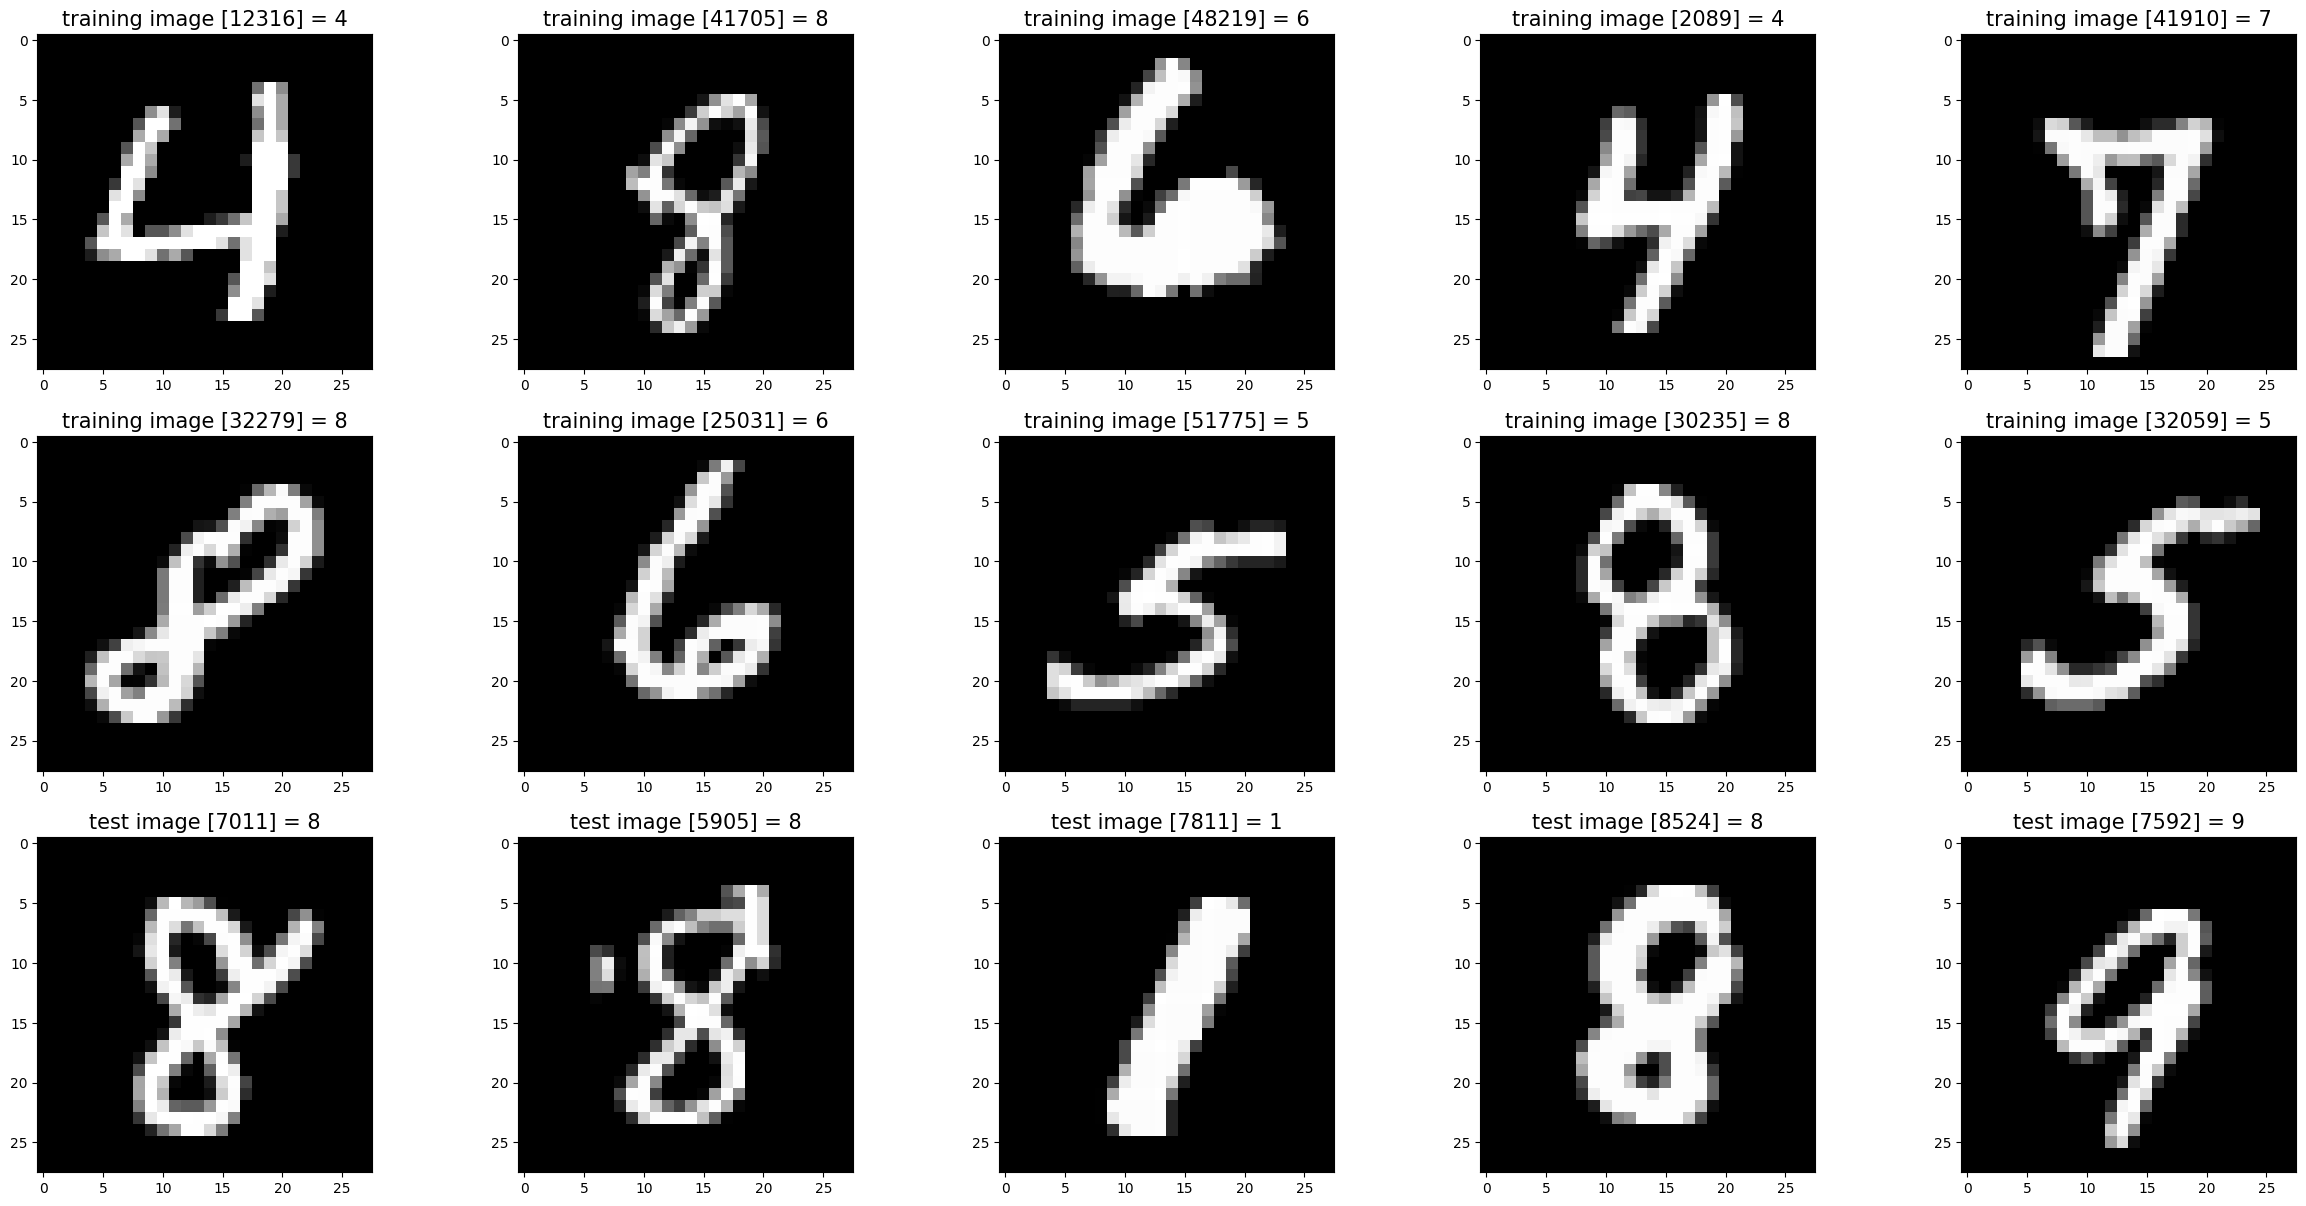

In [7]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'mnist'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [8]:
x_train[0][5]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
         0,   0], dtype=uint8)

In [9]:
y_train[0]

5

Once we got our data, we need to work to convert the training data into what we can feed into our neural network. The variables `x_train`, `y_train`, `x_test`, and `y_test` get loaded onto our terminal where the `x` data is shown as a list of all the image data, a list of 28 arrays of length 28 in each entry in this list, and `y` is the corresponding digit. We need to transform this data to what can be used to feed into our neural network.

In [8]:
x_train_array = np.stack([np.concatenate(arrays) for arrays in x_train]) / 255
x_test_array = np.stack([np.concatenate(arrays) for arrays in x_test]) / 255

In [9]:
y_train_array = np.zeros((60000, 10))

for i in range(60000):
    digit = y_train[i]
    y_train_array[i, digit] = 1

y_test_array = np.zeros((10000, 10))

for i in range(10000):
    digit = y_test[i]
    y_test_array[i, digit] = 1

Let's make some strokes. These are features we want to detect in our image, and will be used as a heuristic for our first layer's weights. The set of strokes will be a mix of horizontal, vertical, and diagonal strokes starting at different positions.

In [10]:
def stroke(thickness, length, direction, start_x, start_y):
    # thickness: size of square of each dot
    # length: number of dots placed
    # direction: 0 for right, 1 for diagonal down right, 2 for down, 3 for diagonal down left
    # start_x, start_y: top-left coordinate of starting stroke

    if direction == 0:
        image_left = start_x
        image_right = start_x + (thickness - 1) + (length - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1)
    elif direction == 1:
        image_left = start_x
        image_right = start_x + (thickness - 1) + (length - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)
    elif direction == 2:
        image_left = start_x
        image_right = start_x + (thickness - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)
    elif direction == 3:
        image_left = start_x - (length - 1)
        image_right = start_x + (thickness - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)

    if not (0 <= image_left <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_right <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_top <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_bottom <= 27):
        raise ValueError("Image out of bounds")

    image = np.zeros((28,28))

    current_x = start_x
    current_y = start_y

    for i in range(length):
        image[current_y:current_y+thickness, current_x:current_x+thickness] = 1
        if direction == 0:
            current_x += 1
        elif direction == 1:
            current_x += 1
            current_y += 1
        elif direction == 2:
            current_y += 1
        elif direction == 3:
            current_x -= 1
            current_y += 1

    return image.reshape(784)

In [13]:
stroke(3, 8, 0, 18, 18)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

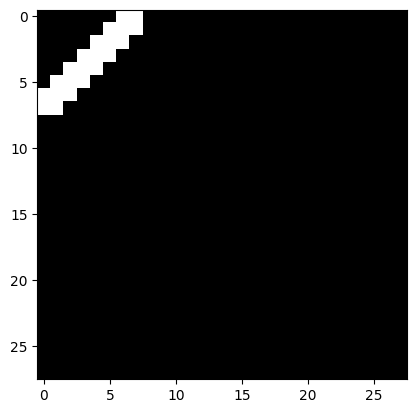

In [14]:
stroke_sample = np.reshape(stroke(2, 7, 3, 6, 0), (28, 28))
plt.imshow(stroke_sample, cmap=plt.cm.gray)

In [11]:
stroke_set = []

for x in range(0, 28, 2):
    for y in range(0, 28, 2):
        try:
            stroke_sample = stroke(2, 7, 0, x, y)
            stroke_set.append(stroke_sample)
        except:
            pass
        try:
            stroke_sample = stroke(2, 7, 1, x, y)
            stroke_set.append(stroke_sample)
        except:
            pass
        try:
            stroke_sample = stroke(2, 7, 2, x, y)
            stroke_set.append(stroke_sample)
        except:
            pass
        try:
            stroke_sample = stroke(2, 7, 3, x, y)
            stroke_set.append(stroke_sample)
        except:
            pass

In [12]:
stroke_set_array = np.stack(stroke_set).transpose().copy()

In [17]:
stroke_set_array.shape

(784, 550)

Now, we'll get to set up our neural network with the initial parameters, and weight set. A good number of neurons to use might be 784, 550, 100, 40, and 10 from the input to the output.

In [609]:
mnist_nn = NeuralNetwork([784, 550, 100, 40, 10], sigma=0.1)

mnist_nn.set_weight(0, stroke_set_array)

In [611]:
mnist_nn.weights

[array([[1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.]]),
 array([[-0.05428687,  0.09652893,  0.07536584, ..., -0.12581028,
         -0.17112647, -0.02205355],
        [ 0.14883714, -0.0689174 ,  0.13988076, ...,  0.06710139,
          0.11054537,  0.09017258],
        [ 0.02017738,  0.00138047, -0.02771956, ..., -0.01561343,
         -0.1911508 , -0.21964103],
        ...,
        [-0.03240696, -0.02886567,  0.08284719, ..., -0.01600043,
         -0.1211968 ,  0.03087796],
        [-0.13235838, -0.09179598,  0.07939685, ...,  0.13434547,
         -0.02482456,  0.02015116],
        [ 0.17917186,  0.09676326, -0.03771726, ..., -0.21603107,
         -0.12662693,  0.14932884]]),
 array([[ 0.0112267 ,  0.05635706,  0.03524949, ..., -0.11615578,
         -0.02509692, -0.20291348],
        [ 0.12751964, 

Let's extract a random set of indices from our training data of 60,000 to fit the final layer's weight and bias. That way our training will initialize closely by correlation at the final layer. Then what we'll do next is to backpropagate by the gradient descent using smaller, randomized batches, while monitoring the error with a certain subset of the test set.

In [624]:
indices = np.random.choice(range(60000), size=1000, replace=False)

initial_training_x = x_train_array[indices, :]
initial_training_y = y_train_array[indices, :]

In [625]:
mnist_nn.fit_final_layer(initial_training_x, initial_training_y)

C:\Users\rayng\AppData\Local\Temp\ipykernel_36856\3255122215.py:102: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  matrix = np.linalg.lstsq(origin_neuron, target_neuron)[0]


In [ ]:
test_indices = np.random.choice(range(10000), size=100, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

In [632]:
print(mnist_nn.error(testing_sample_x, testing_sample_y))

0.4826573661837405


A pretty good average error for the testing sample. Let's see how this same error changes over time if we backpropagate against random samples.

In [635]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 0.4720901366004705
Training iteration 2:
Average error: 0.4719126949832767
Training iteration 3:
Average error: 0.4720299237412353
Training iteration 4:
Average error: 0.48115139711005717
Training iteration 5:
Average error: 0.47931372758529067
Training iteration 6:
Average error: 0.4905879596419308
Training iteration 7:
Average error: 0.5049319721360658
Training iteration 8:
Average error: 0.5152971258243483
Training iteration 9:
Average error: 0.5257117021642231
Training iteration 10:
Average error: 0.5291315772551973
Training iteration 11:
Average error: 0.5521966065577429
Training iteration 12:
Average error: 0.5528329765416623
Training iteration 13:
Average error: 0.539870456344476
Training iteration 14:
Average error: 0.5421391616326414
Training iteration 15:
Average error: 0.529921155820446
Training iteration 16:
Average error: 0.5279475589947767
Training iteration 17:
Average error: 0.5222744714424747
Training iteration 18:
Average error: 0.

Turns out the error against the test set has fluctuated a lot instead of decreased. Should we slow down the learning rate, or increase our training batch size? Maybe this is the network learning new things.

In [636]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.001)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 2.1430056070468275
Training iteration 2:
Average error: 2.1718247142078337
Training iteration 3:
Average error: 2.1000276790464985
Training iteration 4:
Average error: 2.016719521150415
Training iteration 5:
Average error: 2.0507275616399143
Training iteration 6:
Average error: 2.005912689226679
Training iteration 7:
Average error: 2.0037799766869044
Training iteration 8:
Average error: 2.038122280151392
Training iteration 9:
Average error: 2.108233449394203
Training iteration 10:
Average error: 2.1412884594623667
Training iteration 11:
Average error: 2.1005231531652635
Training iteration 12:
Average error: 2.1301937893739615
Training iteration 13:
Average error: 2.0761894210108585
Training iteration 14:
Average error: 2.1066039303895354
Training iteration 15:
Average error: 2.0687882676355738
Training iteration 16:
Average error: 2.0822663720301566
Training iteration 17:
Average error: 1.9960934827685808
Training iteration 18:
Average error: 1.9892

Doesn't seem to have decreased significantly. Maybe we should increase our training batch size so it's more representative. It's going to be slower with the larger sample size.

In [637]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.001)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 1.942781949097556
Training iteration 2:
Average error: 1.946587694451585
Training iteration 3:
Average error: 1.9067226781482858
Training iteration 4:
Average error: 1.8828088306814508
Training iteration 5:
Average error: 1.9166195190395052
Training iteration 6:
Average error: 1.9223625217466083
Training iteration 7:
Average error: 1.9047720731442173
Training iteration 8:
Average error: 1.906590439795031
Training iteration 9:
Average error: 1.9046795062395543
Training iteration 10:
Average error: 1.852806834178178
Training iteration 11:
Average error: 1.8156004454151529
Training iteration 12:
Average error: 1.8364135337892864
Training iteration 13:
Average error: 1.8698453769274976
Training iteration 14:
Average error: 1.87101943182192
Training iteration 15:
Average error: 1.874625694797017
Training iteration 16:
Average error: 1.880780463469349
Training iteration 17:
Average error: 1.9046686292805055
Training iteration 18:
Average error: 1.91774652

Again, not a great decrease, but there's a decreasing trend. Tell us the error function is probably quite rough and irregular that it frequently overshoots. How about this: Let's run for many more iterations, decrease the learning rate significantly, and keep the batch size small for efficiency.

In [638]:
for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.0001)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 1.7873466422477526
Training iteration 2:
Average error: 1.7839841728961572
Training iteration 3:
Average error: 1.785250841214459
Training iteration 4:
Average error: 1.787509628309694
Training iteration 5:
Average error: 1.7915808619382394
Training iteration 6:
Average error: 1.7852894153873098
Training iteration 7:
Average error: 1.7899935917191483
Training iteration 8:
Average error: 1.7833130991141726
Training iteration 9:
Average error: 1.7854187472054048
Training iteration 10:
Average error: 1.7813411591924853
Training iteration 11:
Average error: 1.786733610822229
Training iteration 12:
Average error: 1.7884663079910093
Training iteration 13:
Average error: 1.7886452820782663
Training iteration 14:
Average error: 1.791563948360145
Training iteration 15:
Average error: 1.7751302725615241
Training iteration 16:
Average error: 1.7791636191371702
Training iteration 17:
Average error: 1.7714117020648168
Training iteration 18:
Average error: 1.7722

If you watch this, you can see there's a slow but steady downward trend in the error. But it's still not as significant as we would ideally like it to be. Maybe let's introduce a bit of chaos by ading some noise to the mix. Could this possibly find a lower valley a little faster?

In [639]:
for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.0001, rel_noise = 0.001)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 1.5347614368833482
Training iteration 2:
Average error: 1.5357833477386453
Training iteration 3:
Average error: 1.5284627997145137
Training iteration 4:
Average error: 1.5308117398417682
Training iteration 5:
Average error: 1.5325352671159118
Training iteration 6:
Average error: 1.5372644510189821
Training iteration 7:
Average error: 1.5387161859279874
Training iteration 8:
Average error: 1.5369649783016965
Training iteration 9:
Average error: 1.536006237308104
Training iteration 10:
Average error: 1.5348784727231
Training iteration 11:
Average error: 1.5321389426365917
Training iteration 12:
Average error: 1.5345113734117333
Training iteration 13:
Average error: 1.5296659999070585
Training iteration 14:
Average error: 1.5315749421016678
Training iteration 15:
Average error: 1.5337616244558696
Training iteration 16:
Average error: 1.5316968522589063
Training iteration 17:
Average error: 1.527401421274624
Training iteration 18:
Average error: 1.52590

Turns out that adding some noise is not really helping our error decrease, as it has more like flatlined. Though at later iterations we could say it has started decreasing, at least so it seems. Maybe decreasing the learning error helps? Or how about... we shake things up (literally) by adding some jitter to our weight and bias parameters? Let's first take a look at what's up with the weights and biases of our neural network.

array([ 1.00000575e+00,  9.99996927e-01,  1.00000037e+00, -7.67141400e-06,
        2.10185279e-06, -2.72669972e-06, -1.37977502e-07, -5.01662987e-06,
        1.49324055e-06, -6.51116813e-06,  3.20362905e-06,  1.50276831e-06,
       -2.26063109e-06, -1.35063077e-06, -3.90292480e-06,  3.70380978e-06,
       -2.18760397e-07,  5.59902663e-06, -3.54601847e-06,  7.42706422e-07,
       -9.17333667e-07, -3.85658778e-07, -6.10786436e-06, -1.92902108e-06,
       -1.75549022e-06, -1.44233331e-06, -7.76747110e-06, -3.34153219e-06,
       -6.31204443e-07, -9.14241827e-06, -3.55389971e-06,  4.37204193e-06,
       -2.35409174e-06,  6.34983612e-07, -1.00199329e-05,  1.72527772e-06,
       -7.04974744e-07,  1.02839118e-06,  3.58669129e-06, -1.76034120e-06,
        4.28196415e-07, -1.00641577e-07, -1.52208076e-06,  1.26977942e-06,
       -2.48869665e-06, -2.99656377e-06, -2.90475996e-06, -4.11422199e-06,
        6.57119769e-07, -5.54999491e-06,  1.80917831e-06, -2.38185544e-06,
        7.56277470e-07,  

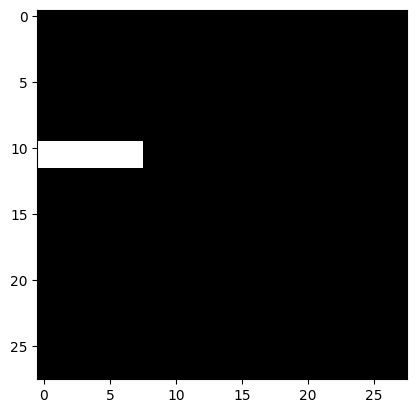

In [666]:
stroke_sample = np.reshape(mnist_nn.weights[0][:, 15], (28, 28))
plt.imshow(stroke_sample, cmap=plt.cm.gray)
mnist_nn.weights[0][0, :]

Turns out our stroke layer has not changed. Should we try, for example, doing more aggressive learning? Risky but it could potentially get us where we want.

In [667]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.01)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 1.6297882714527907
Training iteration 2:
Average error: 1.2427000062551894
Training iteration 3:
Average error: 1.2567420046980706
Training iteration 4:
Average error: 0.9690945433830019
Training iteration 5:
Average error: 1.0749707341332826
Training iteration 6:
Average error: 0.9004288180613265
Training iteration 7:
Average error: 0.7848448089828889
Training iteration 8:
Average error: 0.937715282573955
Training iteration 9:
Average error: 1.2296330088486487
Training iteration 10:
Average error: 1.384133935843123
Training iteration 11:
Average error: 1.159119679654191
Training iteration 12:
Average error: 1.2987013107626129
Training iteration 13:
Average error: 1.3917996889985316
Training iteration 14:
Average error: 1.4373125906028996
Training iteration 15:
Average error: 1.4866493627131137
Training iteration 16:
Average error: 1.6457457172250864
Training iteration 17:
Average error: 1.714037315782421
Training iteration 18:
Average error: 1.6985

Surprisingly, it turns out we halved the error by increasing the learning rate. But there's a caveat in that there are a lot of fluctuations. To go further, at this low point, we can continue training with a slower learning rate. Or we can take another risk to increase the learning rate a bit more, considering the results of this performance.

In [669]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.05, rel_noise = 0.01)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 0.5915034897977565
Training iteration 2:
Average error: 0.8501628612365926
Training iteration 3:
Average error: 0.6432944131014742
Training iteration 4:
Average error: 0.6375451491991413
Training iteration 5:
Average error: 0.593684048407869
Training iteration 6:
Average error: 0.5571030667748712
Training iteration 7:
Average error: 0.5476295221781083
Training iteration 8:
Average error: 0.5573253137012224
Training iteration 9:
Average error: 0.6169968798623836
Training iteration 10:
Average error: 1.3814080927750028
Training iteration 11:
Average error: 0.5666918396598116
Training iteration 12:
Average error: 0.5520189740145416
Training iteration 13:
Average error: 1.5987299535519042
Training iteration 14:
Average error: 0.5997075182648488
Training iteration 15:
Average error: 0.6132178644068428
Training iteration 16:
Average error: 0.585511009956747
Training iteration 17:
Average error: 0.5969992822006165
Training iteration 18:
Average error: 0.57

There are a lot of fluctuations with this approach because a high learning rate means the learning process is fast but coarse. But if we decrease the learning rate, we can get to finer tuning. Either way, we should aim to see a decreasing trend in the error. Now that we are at a low point, let's do some fine tuning by decreasing the learning rate.

In [670]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.005, rel_noise = 0.01)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 0.6046274099943908
Training iteration 2:
Average error: 0.5995958123395577
Training iteration 3:
Average error: 0.5903333785273338
Training iteration 4:
Average error: 0.5832395584148048
Training iteration 5:
Average error: 0.5776588559585698
Training iteration 6:
Average error: 0.5762061399354141
Training iteration 7:
Average error: 0.5737419137411695
Training iteration 8:
Average error: 0.5732505984750754
Training iteration 9:
Average error: 0.5738550700751426
Training iteration 10:
Average error: 0.5768556447476948
Training iteration 11:
Average error: 0.577146773296322
Training iteration 12:
Average error: 0.5766175668246425
Training iteration 13:
Average error: 0.5714817941894025
Training iteration 14:
Average error: 0.571605695403966
Training iteration 15:
Average error: 0.5722641823706174
Training iteration 16:
Average error: 0.5736312081249798
Training iteration 17:
Average error: 0.5740446360442533
Training iteration 18:
Average error: 0.57

In [671]:
for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.001, rel_noise = 0.01)
    print(f"Training iteration {i+1}:")
    print(f"Average error: {mnist_nn.error(testing_sample_x, testing_sample_y)}")

Training iteration 1:
Average error: 0.5847513938868049
Training iteration 2:
Average error: 0.5836044340297865
Training iteration 3:
Average error: 0.5845418473036296
Training iteration 4:
Average error: 0.5835621717750594
Training iteration 5:
Average error: 0.5831314280131181
Training iteration 6:
Average error: 0.5828074841617411
Training iteration 7:
Average error: 0.5819075470689992
Training iteration 8:
Average error: 0.5826887610740659
Training iteration 9:
Average error: 0.5832774071042985
Training iteration 10:
Average error: 0.5822350963655556
Training iteration 11:
Average error: 0.5823917279181159
Training iteration 12:
Average error: 0.5825489255966968
Training iteration 13:
Average error: 0.5825820826898205
Training iteration 14:
Average error: 0.5832256773398244
Training iteration 15:
Average error: 0.5831958091380427
Training iteration 16:
Average error: 0.5820267151779813
Training iteration 17:
Average error: 0.5818628161971686
Training iteration 18:
Average error: 0.

At some point, this won't get us anywhere. How about, we try something else. Let's do a coarse exploration, using a high learning rate, and although it might fluctuate, it does eventually reach some low points. Before it actually increases, how about we set a target and stop the process there when it reaches that point, then continue with fine tuning.

In [675]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.03, rel_noise = 0.01)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.55:
        break

Training iteration 1:
Average error: 0.5674068358484817
Training iteration 2:
Average error: 0.5745076951048584
Training iteration 3:
Average error: 0.6030714988399049
Training iteration 4:
Average error: 0.5790159194092167
Training iteration 5:
Average error: 0.5829590753193873
Training iteration 6:
Average error: 0.5624143469343168
Training iteration 7:
Average error: 0.5726118401537402
Training iteration 8:
Average error: 0.5637123814944213
Training iteration 9:
Average error: 0.560035191125164
Training iteration 10:
Average error: 0.5592090984936964
Training iteration 11:
Average error: 0.5830681346402755
Training iteration 12:
Average error: 0.5886257885918917
Training iteration 13:
Average error: 0.5794347452296147
Training iteration 14:
Average error: 0.5641014306051306
Training iteration 15:
Average error: 0.5607311190788978
Training iteration 16:
Average error: 0.5598042332304661
Training iteration 17:
Average error: 0.5582534085482013
Training iteration 18:
Average error: 0.5

What we should really ask is how many of the test set does our neural network with the current settings get right? Now that our error is low enough, we should also test how well it performs at the task we wanted to look at in the first place: recognizing digits. Let's bring up our test images, run it through the neural network, and get the predictions.

In [691]:
correct_answers = 0
for index in test_indices:
    output = mnist_nn.forward(x_test_array[index, :])[0][-1]
    prediction = np.argmax(output)
    if prediction == y_test[index]:
        correct_answers += 1

print(correct_answers)

52


That's actually not a very good result. Why? If you notice this, there's virtually no perturbation in our first matrix, and our learning has actually been too slow the whole time.

array([ 1.01141965e+00,  1.00010246e+00,  1.00828287e+00,  1.43717019e-02,
       -7.22802226e-03, -8.32461421e-04,  1.70745027e-03,  5.59685865e-03,
        7.19174219e-03, -7.44892671e-03,  7.04749092e-03, -8.80414421e-03,
        1.34171347e-02,  4.83275388e-03, -3.71774223e-04,  8.86132864e-03,
       -1.50156456e-02,  5.54619218e-03, -5.33202144e-03,  1.85130882e-03,
       -1.29093536e-02, -3.03310826e-04,  1.36958231e-03, -6.88894626e-03,
       -8.59190947e-03,  3.87754532e-03,  4.24083431e-03,  8.38869908e-03,
        3.03927255e-03, -3.61283133e-03, -1.86670900e-03,  1.27001204e-02,
        1.17743856e-02,  3.35910828e-03, -3.93806353e-04,  1.07626471e-02,
       -8.54581388e-03,  1.87390922e-03,  5.93234681e-03,  7.29886867e-03,
        2.71039087e-04, -2.32664478e-03, -5.49135737e-03,  9.70265513e-03,
        1.39961620e-02, -7.60515339e-04,  9.50773606e-03,  4.84779077e-03,
        3.80660863e-03,  6.60030507e-03, -3.03343708e-03,  1.60788139e-02,
        7.34073231e-03, -

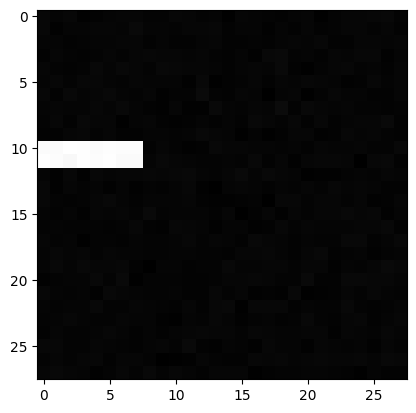

In [693]:
stroke_sample = np.reshape(mnist_nn.weights[0][:, 15], (28, 28))
plt.imshow(stroke_sample, cmap=plt.cm.gray)
mnist_nn.weights[0][0, :]

Let's restart our training, but have some aggressive learning rate to find a better valley.

In [700]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.1, rel_noise = 1)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.4:
        break

Training iteration 1:
Average error: 1.0
Training iteration 2:
Average error: 1.0
Training iteration 3:
Average error: 1.0
Training iteration 4:
Average error: 1.0
Training iteration 5:
Average error: 1.0
Training iteration 6:
Average error: 1.0
Training iteration 7:
Average error: 1.0
Training iteration 8:
Average error: 1.0
Training iteration 9:
Average error: 1.0
Training iteration 10:
Average error: 1.0
Training iteration 11:
Average error: 1.0
Training iteration 12:
Average error: 1.0
Training iteration 13:
Average error: 1.0
Training iteration 14:
Average error: 1.0
Training iteration 15:
Average error: 1.0
Training iteration 16:
Average error: 1.0
Training iteration 17:
Average error: 1.0
Training iteration 18:
Average error: 1.0
Training iteration 19:
Average error: 1.0
Training iteration 20:
Average error: 1.0
Training iteration 21:
Average error: 1.0
Training iteration 22:
Average error: 1.0
Training iteration 23:
Average error: 1.0
Training iteration 24:
Average error: 1.0
T

Oh no! We've hit a point where the error produces 1.0 each time. And considering our function is ReLU, the derivative of the function at negative points is zero, causing a lot of activations to produce deep negative values. If we look carefully at what's going on, we can try to diagnose the problem.

In [709]:
mnist_nn.weights

[array([[ 1.1087747 ,  1.03905602,  0.82992833, ..., -0.35040479,
          0.08253052, -0.30993595],
        [ 0.90197988,  0.88697186,  0.88071155, ..., -0.22347623,
          0.06860871, -0.3946    ],
        [ 1.25970222,  0.0454571 ,  0.24129716, ...,  0.04869249,
         -0.07632678,  0.20357664],
        ...,
        [ 0.02971567,  0.14360226, -0.11685215, ..., -0.43066214,
          0.13147628,  0.01015206],
        [ 0.04819312, -0.02570559,  0.02391902, ...,  0.12141521,
          1.07373293,  0.01155393],
        [-0.0961793 ,  0.14068556, -0.05462502, ..., -0.07923231,
          0.9384157 , -0.06868944]]),
 array([[ 0.10564722,  0.0583489 ,  0.31891026, ...,  0.10264285,
         -0.13766751,  0.01045019],
        [ 0.12150051, -0.05700933,  0.26145787, ...,  0.23811822,
          0.26286984,  0.00546335],
        [-0.13166881, -0.2843134 , -0.10011221, ..., -0.14235037,
         -0.08917861, -0.35552762],
        ...,
        [-0.12462751, -0.28386823, -0.06256191, ...,  

In [710]:
mnist_nn.biases

[array([ 3.87068611e-01, -3.53090546e-02,  4.42769052e-02,  3.18053498e-01,
        -1.96306287e-01, -2.06851298e-01,  1.37115060e-01, -4.72479774e-03,
        -5.69775492e-02,  5.19238476e-02,  1.56870658e-01, -7.99650024e-02,
         1.52282851e-01, -5.91833092e-02,  2.96942727e-02, -1.33015839e-01,
         1.14025829e-02, -3.30978434e-02, -8.40424885e-05, -1.77309615e-02,
        -9.73532674e-02, -2.38827355e-01, -1.52974402e-01,  4.58743305e-03,
        -3.09596462e-01,  2.99104215e-01,  3.28887501e-01,  1.18437111e-01,
        -1.89444752e-01,  1.32126941e-01, -1.15899612e-01, -2.18383166e-02,
         3.24071838e-01,  2.24936554e-01, -1.84699036e-02,  4.28927810e-02,
         3.14886686e-01,  2.35495498e-01,  1.03413013e-02, -1.89673101e-01,
         2.03527859e-01,  4.03646230e-02,  9.85418001e-02,  8.07505009e-02,
        -1.47446076e-01, -3.52337944e-02,  4.42646999e-01, -8.46077352e-02,
        -7.17623068e-02,  4.45494709e-01,  2.90236616e-01, -2.26409844e-01,
         1.3

It's not easy to see, but especially at the final matrix, there are a lot of values towards the negative side. It may be time for a reset, or to change our activation function. How about this: Let's try using sigmoid as our activation function now. We'll make some changes to our settings.

In [712]:
mnist_nn.activation = sigmoid
mnist_nn.d_activation = d_sigmoid
mnist_nn.inv_activation = inv_sigmoid

Let's try again.

In [713]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.1, rel_noise = 1)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.4:
        break

Training iteration 1:
Average error: 0.9966315265027782
Training iteration 2:
Average error: 0.9966267912572144
Training iteration 3:
Average error: 0.9966889051951288
Training iteration 4:
Average error: 0.9966696752535329
Training iteration 5:
Average error: 0.9967030118803882
Training iteration 6:
Average error: 0.9967836844608188
Training iteration 7:
Average error: 0.9966263434496636
Training iteration 8:
Average error: 0.9965208366780537
Training iteration 9:
Average error: 0.9965826380466827
Training iteration 10:
Average error: 0.9966285053501861
Training iteration 11:
Average error: 0.9965853616762905
Training iteration 12:
Average error: 0.9964534476649078
Training iteration 13:
Average error: 0.9964323881389708
Training iteration 14:
Average error: 0.9963968148197402
Training iteration 15:
Average error: 0.9963318231712919
Training iteration 16:
Average error: 0.9962169222907516
Training iteration 17:
Average error: 0.9962335760791529
Training iteration 18:
Average error: 0.

In [ ]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=50, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 1, rel_noise = 1)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.4:
        break

Using the sigmoid helps a little bit, but it seems it will take a long time for us to get the neurons back.

In [716]:
for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=10, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 1, rel_noise = 1)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.4:
        break

Training iteration 1:
Average error: 0.9973735725419621
Training iteration 2:
Average error: 0.9977111286581797
Training iteration 3:
Average error: 0.997294805686918
Training iteration 4:
Average error: 0.9975858556845619
Training iteration 5:
Average error: 0.9973798767651434
Training iteration 6:
Average error: 0.9961848842571922
Training iteration 7:
Average error: 0.9939581394617505
Training iteration 8:
Average error: 0.9887454841127198
Training iteration 9:
Average error: 0.9942793848926241
Training iteration 10:
Average error: 0.9937860454257859
Training iteration 11:
Average error: 0.9920729998192563
Training iteration 12:
Average error: 0.991533149551962
Training iteration 13:
Average error: 0.9912365188464637
Training iteration 14:
Average error: 0.9859886347828728
Training iteration 15:
Average error: 0.9879503988468846
Training iteration 16:
Average error: 0.9889652256051642
Training iteration 17:
Average error: 0.9919646747619134
Training iteration 18:
Average error: 0.99

It may help to reset the weights to more moderate values if you get stuck.

In [722]:
[weight.shape for weight in mnist_nn.weights]

[(784, 550), (550, 100), (100, 40), (40, 10)]

In [731]:
stroke_set_array

array([[ 0.49370958, -0.99888035, -1.32971652, ..., -2.26642349,
        -5.09886342,  0.18719851],
       [ 4.31227606,  3.47565911, -2.19371645, ..., -2.6671835 ,
         1.08775996, -1.73142009],
       [ 5.04531883,  0.0730112 ,  2.30348974, ...,  0.97402743,
         0.14540658, -1.68436645],
       ...,
       [ 4.64577153,  0.85557191, -3.08190319, ..., -5.46798007,
        -1.98856982, -3.81951066],
       [-0.07307027, -0.64629752, -1.49544948, ...,  1.64655245,
         0.73221514,  2.91760217],
       [-4.37297573, -0.49957377, -5.01650358, ...,  2.47216691,
         3.05301215, -1.83785191]])

In [742]:
mnist_nn.set_weight(0, stroke_set_array)
mnist_nn.set_weight(1, np.random.normal(scale=0.1, size=mnist_nn.weights[1].shape))
mnist_nn.set_weight(2, np.random.normal(scale=0.1, size=mnist_nn.weights[2].shape))
mnist_nn.set_weight(3, np.random.normal(scale=0.1, size=mnist_nn.weights[3].shape))

mnist_nn.set_bias(0, np.random.normal(scale=0.1, size=mnist_nn.biases[0].shape))
mnist_nn.set_bias(1, np.random.normal(scale=0.1, size=mnist_nn.biases[1].shape))
mnist_nn.set_bias(2, np.random.normal(scale=0.1, size=mnist_nn.biases[2].shape))
mnist_nn.set_bias(3, np.random.normal(scale=0.1, size=mnist_nn.biases[3].shape))

mnist_nn.valid_state()

True

In [746]:
for i in range(100):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :]
    mnist_nn.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.1, rel_noise = 0)
    print(f"Training iteration {i+1}:")
    error = mnist_nn.error(testing_sample_x, testing_sample_y)
    print(f"Average error: {error}")
    if error < 0.4:
        break

Training iteration 1:
Average error: 2.5013205140184542
Training iteration 2:
Average error: 2.5073203654916933
Training iteration 3:
Average error: 2.4942018763724594
Training iteration 4:
Average error: 2.5003484451012734
Training iteration 5:
Average error: 2.50203719851608
Training iteration 6:
Average error: 2.4987930458849648
Training iteration 7:
Average error: 2.4939785481731276
Training iteration 8:
Average error: 2.5031332786635674
Training iteration 9:
Average error: 2.495746426633601
Training iteration 10:
Average error: 2.500877298308056
Training iteration 11:
Average error: 2.501608638011946
Training iteration 12:
Average error: 2.497739483250096
Training iteration 13:
Average error: 2.501134424967252
Training iteration 14:
Average error: 2.4977344002701614
Training iteration 15:
Average error: 2.5012501020403346
Training iteration 16:
Average error: 2.496330082590714
Training iteration 17:
Average error: 2.5028333699484957
Training iteration 18:
Average error: 2.49593686

C:\Users\rayng\AppData\Local\Temp\ipykernel_36856\4276526290.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-x))


Training iteration 54:
Average error: 2.501289525124876
Training iteration 55:
Average error: 2.499431745864971
Training iteration 56:
Average error: 2.499861926943986
Training iteration 57:
Average error: 2.4967316850036605
Training iteration 58:
Average error: 2.507117235893267
Training iteration 59:
Average error: 2.4966878906235475
Training iteration 60:
Average error: 2.501644836716193
Training iteration 61:
Average error: 2.5031771527088194
Training iteration 62:
Average error: 2.4967980398364453
Training iteration 63:
Average error: 2.492948823652313
Training iteration 64:
Average error: 2.5049261261481166
Training iteration 65:
Average error: 2.498901353569438
Training iteration 66:
Average error: 2.501774977043668
Training iteration 67:
Average error: 2.494885079870153
Training iteration 68:
Average error: 2.5005073071874917
Training iteration 69:
Average error: 2.493315238132384
Training iteration 70:
Average error: 2.505074296915764
Training iteration 71:
Average error: 2.49

In [744]:
mnist_nn.forward(x_train_array[0])

([array([0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0

In [747]:
correct_answers = 0
for index in test_indices:
    output = mnist_nn.forward(x_test_array[index, :])[0][-1]
    prediction = np.argmax(output)
    if prediction == y_test[index]:
        correct_answers += 1

print(correct_answers)

10


C:\Users\rayng\AppData\Local\Temp\ipykernel_36856\4276526290.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-x))


---

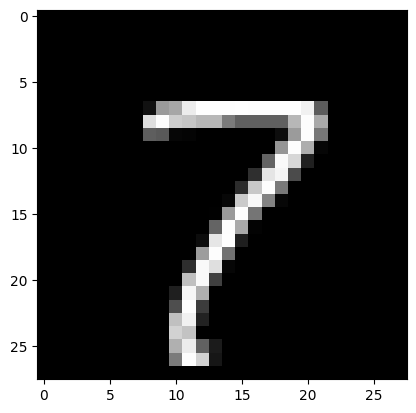

In [19]:
stroke_sample = np.reshape(x_train_array[43710], (28, 28))
plt.imshow(stroke_sample, cmap=plt.cm.gray)

In [806]:
mnist_nn2.set_weight(0, stroke_set_array.copy() / 20)

In [807]:
mnist_nn2.weights

[array([[0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
        [0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
        [0.05, 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        ...,
        [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , ..., 0.  , 0.05, 0.  ],
        [0.  , 0.  , 0.  , ..., 0.  , 0.05, 0.  ]]),
 array([[ 0.06342485, -0.04811233, -0.00531066, ...,  0.12713373,
         -0.01365732,  0.03929305],
        [ 0.00283486,  0.02580971,  0.11777197, ..., -0.0016521 ,
          0.02623866, -0.07244882],
        [-0.1666812 , -0.10670228, -0.05052389, ...,  0.06212173,
         -0.08302569,  0.06681427],
        ...,
        [-0.05618637, -0.07743614, -0.07860368, ...,  0.10576068,
          0.0286234 ,  0.21443945],
        [-0.05097395,  0.00518406, -0.04687313, ...,  0.13441076,
         -0.07286768,  0.05977086],
        [-0.05859803,  0.04030207, -0.027623  , ...,  0.06881594,
          0.01266336, -0.02475791]]),
 array([[-0.04597554, -0.06309153, -0.11405585,  0.0

In [808]:
mnist_nn2.forward(x_train_array[43710])

([array([0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0

In [819]:
test_indices = np.random.choice(range(10000), size=100, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

Let's see how the error trends with a plot.

Training iteration 20...
Training iteration 40...
Training iteration 60...
Training iteration 80...
Training iteration 100...
Training iteration 120...
Training iteration 140...
Training iteration 160...
Training iteration 180...
Training iteration 200...
Training iteration 220...
Training iteration 240...
Training iteration 260...
Training iteration 280...
Training iteration 300...
Training iteration 320...
Training iteration 340...
Training iteration 360...
Training iteration 380...
Training iteration 400...
Training iteration 420...
Training iteration 440...
Training iteration 460...
Training iteration 480...
Training iteration 500...
Training iteration 520...
Training iteration 540...
Training iteration 560...
Training iteration 580...
Training iteration 600...
Training iteration 620...
Training iteration 640...
Training iteration 660...
Training iteration 680...
Training iteration 700...
Training iteration 720...
Training iteration 740...
Training iteration 760...
Training iterati

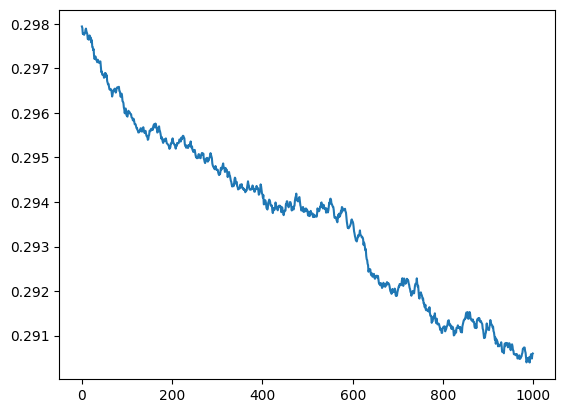

In [826]:
error_history = []

for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=20, replace=False)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn2.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.0)
    #print(f"Training iteration {i+1}:")
    if i % 20 == 19:
        print(f"Training iteration {i+1}...")
    error = mnist_nn2.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    #print(f"Average error: {error}")
    error_history.append(error)
    if error < 0.25:
        break

plt.plot(error_history)

A beautiful result we want to see. The error is trending downwards.

But how many of each digit is the neural network getting right?

In [832]:
test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

In [833]:
correct_answers = 0
questions_by_digit = {n: 0 for n in range(0,10)}
correct_answers_by_digit = {n: 0 for n in range(0,10)}
for index in test_indices:
    questions_by_digit[y_test[index]] += 1
    output = mnist_nn2.forward(x_test_array[index, :])[0][-1]
    prediction = np.argmax(output)
    if prediction == y_test[index]:
        correct_answers += 1
        correct_answers_by_digit[y_test[index]] += 1
rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}

print(correct_answers)
print(questions_by_digit)
print(correct_answers_by_digit)
print(rate_by_digit)

588
{0: 95, 1: 121, 2: 112, 3: 106, 4: 83, 5: 90, 6: 99, 7: 111, 8: 90, 9: 93}
{0: 94, 1: 121, 2: 62, 3: 81, 4: 38, 5: 0, 6: 60, 7: 96, 8: 24, 9: 12}
{0: 0.9894736842105263, 1: 1.0, 2: 0.5535714285714286, 3: 0.7641509433962265, 4: 0.4578313253012048, 5: 0.0, 6: 0.6060606060606061, 7: 0.8648648648648649, 8: 0.26666666666666666, 9: 0.12903225806451613}


<BarContainer object of 10 artists>

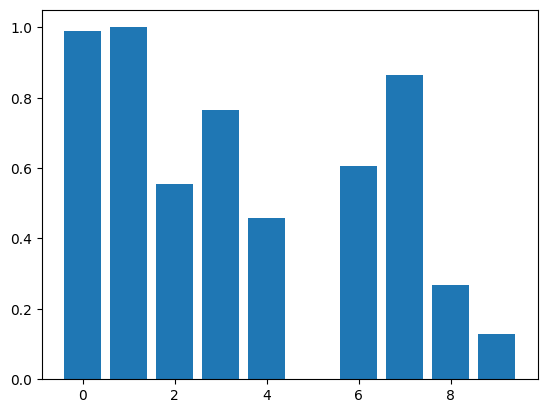

In [904]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

This neural network is showing varying results on each digit. For example, it recognizes 0s, 1s, and 7s very well, but it does poorly on 5s, 8s, and 9s as it has a hard time recognizing these particular digits. They do have a complex shape too at that.

So let's try a new training regimen: What if we focus on digits that the model is not performing well at?

In [14]:
training_digit_indices = {n: [] for n in range(10)}

for i in range(60000):
    digit = y_train[i]
    training_digit_indices[digit].append(i)

In [15]:
cero = training_digit_indices[0]
uno = training_digit_indices[1]
dos = training_digit_indices[2]
tres = training_digit_indices[3]
cuatro = training_digit_indices[4]
cinco = training_digit_indices[5]
seis = training_digit_indices[6]
siete = training_digit_indices[7]
ocho = training_digit_indices[8]
nueve = training_digit_indices[9]

In [16]:
cero_sample = np.random.choice(cero, 10, replace=False)
uno_sample = np.random.choice(uno, 10, replace=False)
dos_sample = np.random.choice(dos, 10, replace=False)
tres_sample = np.random.choice(tres, 10, replace=False)
cuatro_sample = np.random.choice(cuatro, 10, replace=False)
cinco_sample = np.random.choice(cinco, 10, replace=False)
seis_sample = np.random.choice(seis, 10, replace=False)
siete_sample = np.random.choice(siete, 10, replace=False)
ocho_sample = np.random.choice(ocho, 10, replace=False)
nueve_sample = np.random.choice(nueve, 10, replace=False)

In [940]:
error_history = []

probabilities = np.zeros(60000)
probabilities[np.concatenate((cero, uno, tres, siete))] = 2
probabilities[np.concatenate((dos, ocho, nueve))] = 3
probabilities[np.concatenate((cuatro, cinco, seis))] = 4
probabilities /= np.sum(probabilities)

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

correct_answers = 0
questions_by_digit = {n: 0 for n in range(0,10)}
correct_answers_by_digit = {n: 0 for n in range(0,10)}

for i in range(100):
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn2.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.0)
    #print(f"Training iteration {i+1}:")
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn2.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    #print(f"Average error: {error}")
    error_history.append(error)
    if error < 0.25:
        break

for index in test_indices:
    questions_by_digit[y_test[index]] += 1
    output = mnist_nn2.forward(x_test_array[index, :])[0][-1]
    prediction = np.argmax(output)
    if prediction == y_test[index]:
        correct_answers += 1
        correct_answers_by_digit[y_test[index]] += 1
rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}

Training iteration 10...
Training iteration 20...
Training iteration 30...
Training iteration 40...
Training iteration 50...
Training iteration 60...
Training iteration 70...
Training iteration 80...
Training iteration 90...
Training iteration 100...


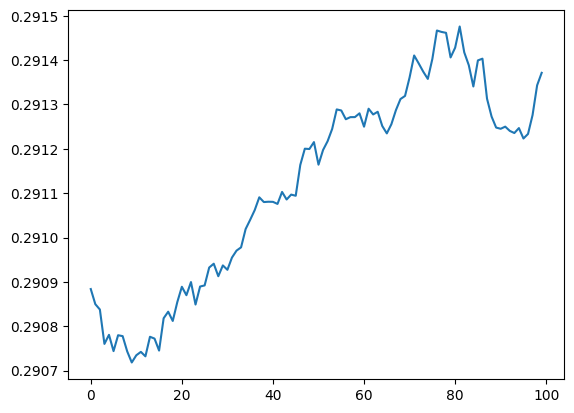

In [941]:
plt.plot(error_history)

<BarContainer object of 10 artists>

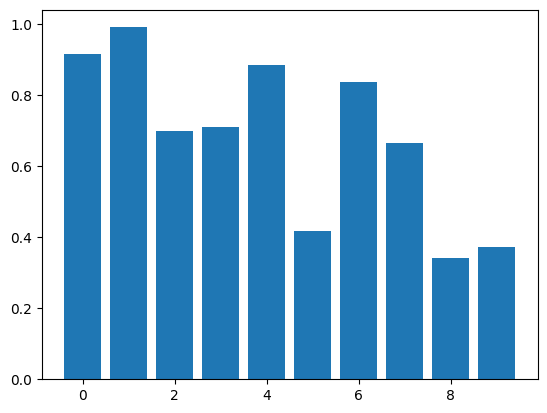

In [942]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [943]:
correct_answers

692

Turns out that increasing the probabilities for worse performing digits makes it do better at those ones in particular. But we need to be careful not to exclude the other digits as this will lead to the phenomenon of *catastrophic forgetting* - it forgets other digits and thus it will not be able to recognize those forgotten digits because it was too focused on the ones you make it focus on.

By the way, we should save our weights and biases so we can access them later.

In [17]:
import pickle
import datetime

In [957]:
filename = f"mnist_nn_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.weights, open(filename, 'wb'))

filename = f"mnist_nn_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.biases, open(filename, 'wb'))

In [964]:
mnist_nn3 = NeuralNetwork([784, 550, 50, 10], sigma=0.0, activation=sigmoid, d_activation=d_sigmoid)

biases = pickle.load(open("mnist_nn_biases_2026-03-19_19-20-57.pkl", 'rb'))
mnist_nn3.biases = biases

weights = pickle.load(open("mnist_nn_weights_2026-03-19_19-20-57.pkl", 'rb'))
mnist_nn3.weights = weights

<BarContainer object of 10 artists>

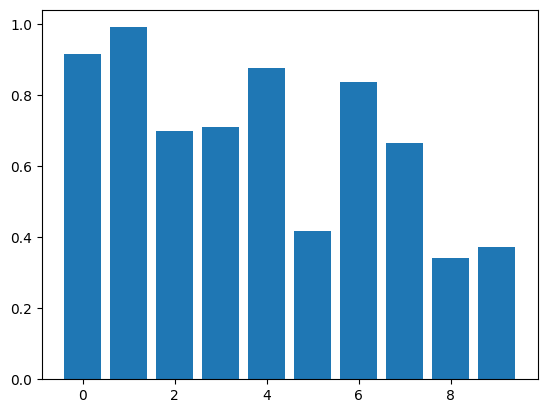

In [965]:
for index in test_indices:
    questions_by_digit[y_test[index]] += 1
    output = mnist_nn3.forward(x_test_array[index, :])[0][-1]
    prediction = np.argmax(output)
    if prediction == y_test[index]:
        correct_answers += 1
        correct_answers_by_digit[y_test[index]] += 1
rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}

plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [968]:
np.argsort(list(rate_by_digit.values()))

array([8, 9, 5, 7, 2, 3, 6, 4, 0, 1], dtype=int64)

Let's make this training dynamic now by automating this process of prioritizing the digits.

In [982]:
def test_nn(nn, test_indices):
    correct_answers = 0
    questions_by_digit = {n: 0 for n in range(0,10)}
    correct_answers_by_digit = {n: 0 for n in range(0,10)}

    for index in test_indices:
        questions_by_digit[y_test[index]] += 1
        output = nn.forward(x_test_array[index, :])[0][-1]
        prediction = np.argmax(output)
        if prediction == y_test[index]:
            correct_answers += 1
            correct_answers_by_digit[y_test[index]] += 1
    rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}
    return correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit

In [983]:
error_history = []

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

digit_sets = [cero, uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve]

for i in range(200):
    if i % 20 == 0:
        print("Testing model and calibrating training regimen...")
        validation_indices = np.random.choice(range(10000), size=1000, replace=False)

        correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, validation_indices)

        digits_order = np.argsort(list(rate_by_digit.values()))
        high_priority = [digit_sets[n] for n in digits_order[0:2]]
        medium_priority = [digit_sets[n] for n in digits_order[2:5]]
        low_priority = [digit_sets[n] for n in digits_order[5:10]]

        probabilities = np.zeros(60000)
        probabilities[np.concatenate(high_priority)] = 4
        probabilities[np.concatenate(medium_priority)] = 3
        probabilities[np.concatenate(low_priority)] = 2
        probabilities /= np.sum(probabilities)
        
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn2.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.0)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn2.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    error_history.append(error)
    if error < 0.25:
        break

correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, test_indices)

Testing model and calibrating training regimen...
Training iteration 10...
Training iteration 20...
Testing model and calibrating training regimen...
Training iteration 30...
Training iteration 40...
Testing model and calibrating training regimen...
Training iteration 50...
Training iteration 60...
Testing model and calibrating training regimen...
Training iteration 70...
Training iteration 80...
Testing model and calibrating training regimen...
Training iteration 90...
Training iteration 100...
Testing model and calibrating training regimen...
Training iteration 110...
Training iteration 120...
Testing model and calibrating training regimen...
Training iteration 130...
Training iteration 140...
Testing model and calibrating training regimen...
Training iteration 150...
Training iteration 160...
Testing model and calibrating training regimen...
Training iteration 170...
Training iteration 180...
Testing model and calibrating training regimen...
Training iteration 190...
Training iterat

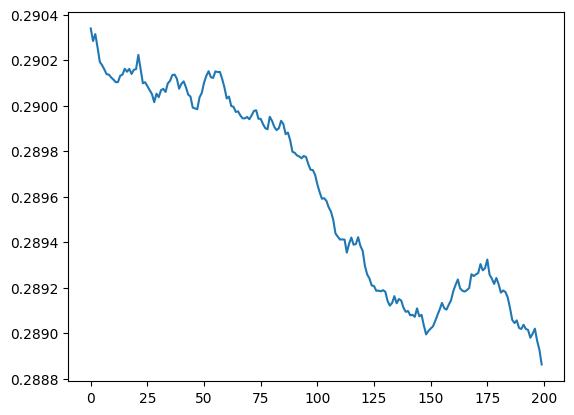

In [984]:
plt.plot(error_history)

<BarContainer object of 10 artists>

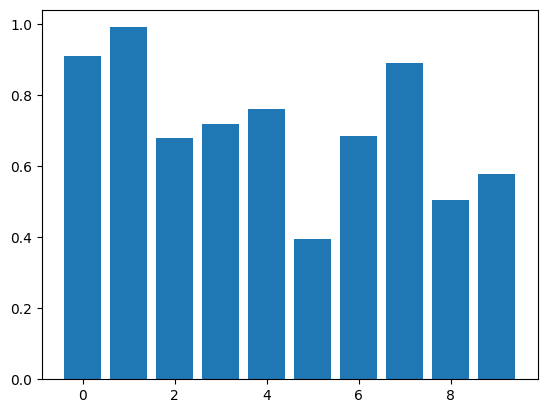

In [985]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [986]:
correct_answers

717

How did the model perform? It seems to have worked well and shows a balance in the digit recognition rate as well as a decreasing trend. Let's run the same thing one more time, and see how things change. But first, let's save the parameters.

In [1006]:
filename = f"mnist_nn_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.weights, open(filename, 'wb'))

filename = f"mnist_nn_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.biases, open(filename, 'wb'))

Testing model and calibrating training regimen...
Training iteration 10...
Training iteration 20...
Testing model and calibrating training regimen...
Training iteration 30...
Training iteration 40...
Testing model and calibrating training regimen...
Training iteration 50...
Training iteration 60...
Testing model and calibrating training regimen...
Training iteration 70...
Training iteration 80...
Testing model and calibrating training regimen...
Training iteration 90...
Training iteration 100...
Testing model and calibrating training regimen...
Training iteration 110...
Training iteration 120...
Testing model and calibrating training regimen...
Training iteration 130...
Training iteration 140...
Testing model and calibrating training regimen...
Training iteration 150...
Training iteration 160...
Testing model and calibrating training regimen...
Training iteration 170...
Training iteration 180...
Testing model and calibrating training regimen...
Training iteration 190...
Training iterat

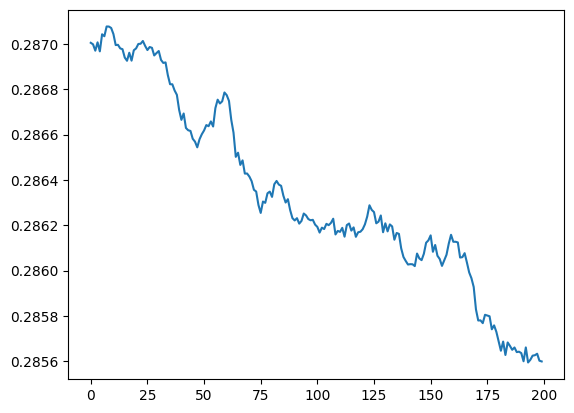

In [ ]:
error_history = []

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

digit_sets = [cero, uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve]

for i in range(200):
    if i % 20 == 0:
        print("Testing model and calibrating training regimen...")
        validation_indices = np.random.choice(range(10000), size=1000, replace=False)

        correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, validation_indices)

        digits_order = np.argsort(list(rate_by_digit.values()))
        high_priority = [digit_sets[n] for n in digits_order[0:2]]
        medium_priority = [digit_sets[n] for n in digits_order[2:5]]
        low_priority = [digit_sets[n] for n in digits_order[5:10]]

        probabilities = np.zeros(60000)
        probabilities[np.concatenate(high_priority)] = 4
        probabilities[np.concatenate(medium_priority)] = 3
        probabilities[np.concatenate(low_priority)] = 2
        probabilities /= np.sum(probabilities)
        
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn2.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.0)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn2.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    error_history.append(error)
    if error < 0.25:
        break

correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, test_indices)

plt.plot(error_history)

<BarContainer object of 10 artists>

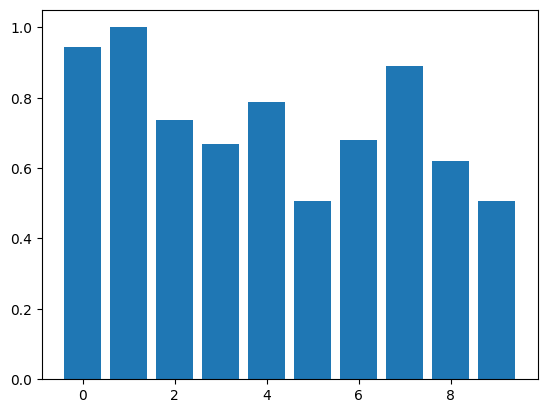

In [1003]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [1005]:
rate_by_digit

{0: 0.9444444444444444,
 1: 1.0,
 2: 0.7372881355932204,
 3: 0.6698113207547169,
 4: 0.7884615384615384,
 5: 0.5061728395061729,
 6: 0.68,
 7: 0.8901098901098901,
 8: 0.6195652173913043,
 9: 0.5051546391752577}

In [1004]:
correct_answers

742

This run gave us quite an improved result, with a recognition rate of over 50% for each digit. And our correct answers is reaching 742/1000. As usual, the error is trending downwards.

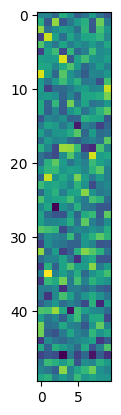

In [1000]:
plt.imshow(mnist_nn2.weights[2])

## Start running cells here

The above is archived theory and experiments conducted in this notebook. To start, run these functions.

In [1]:
import random
import numpy as np

In [2]:
def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (np.sign(x) + 1) / 2
    
def inv_relu(x):
    return x

In [3]:
def leaky_relu(alpha):
    def func(x):
        return np.maximum(alpha * x, x)
    return func

def d_leaky_relu(alpha):
    def func(x):
        return np.where(x > 0, 1, alpha)
    return func

def inv_leaky_relu(alpha):
    def func(x):
        return np.where(x > 0, x, x / alpha)
    return func

In [4]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))
    
def inv_sigmoid(x):
    return np.log(x / (1 - x))

In [5]:
def softplus(x):
    return np.log(1 + np.exp(x))

def d_softplus(x):
    return sigmoid(x)

def inv_softplus(x):
    return np.log(np.exp(x) - 1)

In [6]:
def elu(alpha):
    def func(x):
        return np.where(x > 0, x, alpha * (np.exp(x) - 1))
    return func

def d_elu(alpha):
    def func(x):
        return np.where(x > 0, 1, alpha * np.exp(x))
    return func

def inv_elu(alpha):
    def func(x):
        return np.where(x > 0, x, np.log(x / alpha + 1))
    return func

In [7]:
def erf_approx(x):
    # Please see the page https://en.wikipedia.org/wiki/Error_function#Approximation_with_elementary_functions for more information about this approximation

    # constants
    a1 =  0.254829592
    a2 = -0.284496736
    a3 =  1.421413741
    a4 = -1.453152027
    a5 =  1.061405429
    p  =  0.3275911

    # Save the sign of x
    sign = np.sign(x)
    x = np.abs(x)

    # A&S formula 7.1.26
    t = 1.0/(1.0 + p*x)
    y = 1.0 - (((((a5*t + a4)*t) + a3)*t + a2)*t + a1)*t*np.exp(-x*x)

    return sign*y

In [8]:
# For information about obtaining this formula, please see the page https://docs.pytorch.org/docs/stable/generated/torch.nn.GELU.html and the paper "Gaussian Error Linear Units (GELUs)" by Hendrycks and Gimpel (https://arxiv.org/abs/1606.08415)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def d_gelu(x):
    return 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))) + (3 * 0.044715 * x**2) / np.sqrt(2 * np.pi) * (1 - np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))**2)

def inv_gelu(x):
    return np.where(x < 0, x / 0.5, x / (0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))))

In [79]:
class NNStateError(ValueError):
    pass

class DimensionMismatch(ValueError):
    pass

In [78]:
class NeuralNetwork:
    def __init__(self, neuron_lengths, sigma=0.01, activation=relu, d_activation=d_relu, inv_activation=inv_relu, vectorize=True):
        self.weights = []
        self.biases = []
        if vectorize:
            self.activation = np.vectorize(activation, otypes=[float])
            self.d_activation = np.vectorize(d_activation, otypes=[float])
            self.inv_activation = np.vectorize(inv_activation, otypes=[float])
        else:
            self.activation = activation
            self.d_activation = d_activation
            self.inv_activation = inv_activation

        for layer in range(len(neuron_lengths) - 1):
            self.weights.append(np.random.normal(scale=sigma, size=(neuron_lengths[layer], neuron_lengths[layer+1])))
            self.biases.append(np.random.normal(scale=sigma, size=neuron_lengths[layer+1]))

    def valid_state(self):
        if len(self.weights) != len(self.biases):
            print(f"Warning: Weights and bias list lengths mismatch. You have {len(self.weights)} weight matrices and {len(self.biases)} bias vectors")
            return False
        for layer in range(len(self.weights)):
            if len(self.weights[layer].shape) != 2:
                print(f"Warning: Weight matrix at layer {layer+1} must be 2D array")
                return False
            if len(self.biases[layer].shape) != 1:
                print(f"Warning: Bias vector at layer {layer+1} must be 1D array")
                return False
            if self.weights[layer].shape[1] != self.biases[layer].shape[0]:
                print(f"Warning: Weight matrix and bias vector sizes mismatch at layer {layer+1}: {self.weights[layer].shape[1]} != {self.biases[layer].shape[0]}")
                return False
            if layer < len(self.weights) - 1:
                if self.weights[layer].shape[1] != self.weights[layer+1].shape[0]:
                    print(f"Warning: Weight matrix dimensions mismatch at layer {layer+1}: {self.weights[layer].shape[1]} != {self.weights[layer+1].shape[0]}")
                    return False
        return True
    
    def get_dimensions(self):
        if self.valid_state():
            dimensions = []
            for layer in range(len(self.weights)):
                dimensions.append(self.weights[layer].shape[0])
            dimensions.append(self.weights[-1].shape[1])
            return dimensions
        else:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")

    def set_weight(self, layer, weights):
        self.weights[layer] = weights

    def set_bias(self, layer, bias):
        self.biases[layer] = bias

    def jitter(self, sigma=0.01):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        
        for weight in self.weights:
            perturbation = np.random.normal(scale=sigma, size=weight.shape)
            weight += perturbation

        for bias in self.biases:
            perturbation = np.random.normal(scale=sigma, size=bias.shape)
            bias += perturbation

    def forward(self, input, layers=slice(None)):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(input) != np.ndarray:
            raise TypeError("Input must be an array of dimension 1 or 2")
        if len(input.shape) == 1:
            if input.shape[0] != self.weights[layers][0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {input.shape[0]} != {self.weights[layers][0].shape[0]}")
        elif len(input.shape) == 2:
            if input.shape[1] != self.weights[layers][0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {input.shape[1]} != {self.weights[layers][0].shape[0]}")
        else:
            raise TypeError("Input must be an array of dimension 1 or 2")
        if type(layers) != slice:
            raise TypeError("Layers must be a slice object")

        h_arrays = []
        z_arrays = []
        
        current_data = input

        h_arrays.append(current_data.copy())

        for layer in range(len(self.weights))[layers]:
            current_data = current_data @ self.weights[layer] + self.biases[layer]
            z_arrays.append(current_data.copy())
            current_data = self.activation(current_data)
            h_arrays.append(current_data.copy())

        return h_arrays, z_arrays
    
    def fit_final_layer(self, training_inputs, training_outputs, invert_activation = True):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be 2D arrays. Height is number of data points")
        if len(training_inputs.shape) != 2 or len(training_outputs.shape) != 2:
            raise TypeError("Input and output must be 2D arrays. Height is number of data points")
        if training_inputs.shape[0] != training_outputs.shape[0]:
            raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
        if training_inputs.shape[1] != self.weights[0].shape[0]:
            raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
        if training_outputs.shape[1] != self.weights[-1].shape[1]:
            raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        
        h_arrays, z_arrays = self.forward(training_inputs)
        origin_neuron = h_arrays[-2]
        origin_neuron = np.hstack((origin_neuron, np.ones((origin_neuron.shape[0], 1))))
        if invert_activation == True:
            target_neuron = self.inv_activation(training_outputs)
        else:
            target_neuron = training_outputs

        matrix = np.linalg.lstsq(origin_neuron, target_neuron)[0]
        weight = matrix[:-1, :]
        bias = matrix[-1, :]

        self.set_weight(-1, weight)
        self.set_bias(-1, bias)

    def error(self, training_inputs, training_outputs, dist_mode='l2', agg_mode='avg'):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) != len(training_outputs.shape):
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) == 1:
            if training_inputs.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {training_inputs.shape[0]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[0] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output vector length mismatch: {training_outputs.shape[0]} != {self.weights[-1].shape[1]}")
        elif len(training_inputs.shape) == 2:
            if training_inputs.shape[0] != training_outputs.shape[0]:
                raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
            if training_inputs.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[1] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        else:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        
        h_arrays, z_arrays = self.forward(training_inputs)
        
        difference = h_arrays[-1] - training_outputs

        if dist_mode == 'sum':
            errors = np.sum(np.abs(difference), axis=1)
        elif dist_mode == 'l2':
            errors = np.sqrt(np.sum(difference**2, axis=1))

        if agg_mode == 'sum':
            total_error = np.sum(errors)
        elif agg_mode == 'avg':
            total_error = np.sum(errors) / training_inputs.shape[0]
        elif agg_mode == 'l2':
            total_error = np.sqrt(np.sum(errors**2))
        elif agg_mode == 'max':
            total_error = np.max(errors)

        return total_error

    def backpropagation(self, training_inputs, training_outputs, learning_rate=0.01, rel_noise=0, max_parameter_change = 0.1, average=True, apply=True):
        valid_state = self.valid_state()
        if not valid_state:
            raise NNStateError("Current neural network settings invalid. Please resolve printed error with set_weight or set_bias")
        if type(training_inputs) != np.ndarray or type(training_outputs) != np.ndarray:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) != len(training_outputs.shape):
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        if len(training_inputs.shape) == 1:
            if training_inputs.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {training_inputs.shape[0]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[0] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output vector length mismatch: {training_outputs.shape[0]} != {self.weights[-1].shape[1]}")
        elif len(training_inputs.shape) == 2:
            if training_inputs.shape[0] != training_outputs.shape[0]:
                raise DimensionMismatch(f"Height of training input data must match height of output data: {training_inputs.shape[0]} != {training_outputs.shape[0]}")
            if training_inputs.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {training_inputs.shape[1]} != {self.weights[0].shape[0]}")
            if training_outputs.shape[1] != self.weights[-1].shape[1]:
                raise DimensionMismatch(f"Output array dimensions mismatch: {training_outputs.shape[1]} != {self.weights[-1].shape[1]}")
        else:
            raise TypeError("Input and output must be arrays of same dimension 1 or 2")
        
        if len(training_inputs.shape) == 2:
            data_points = training_inputs.shape[0]
            total_weight_gradient = [np.zeros(array.shape) for array in self.weights]
            total_bias_gradient = [np.zeros(array.shape) for array in self.biases]
            for i in range(data_points):
                weight_gradient, bias_gradient = self.backpropagation(training_inputs[i, :], training_outputs[i, :], learning_rate=learning_rate, rel_noise=rel_noise, apply=False)
                for layer in range(len(weight_gradient)):
                    total_weight_gradient[layer] += weight_gradient[layer]
                for layer in range(len(bias_gradient)):
                    total_bias_gradient[layer] += bias_gradient[layer]
            if average:
                for layer in range(len(weight_gradient)):
                    total_weight_gradient[layer] /= data_points
                for layer in range(len(bias_gradient)):
                    total_bias_gradient[layer] /= data_points
        else:
            h_arrays, z_arrays = self.forward(training_inputs)

            error_gradient = 2 * (h_arrays[-1] - training_outputs)
            error_signals = [error_gradient]
            for layer in range(len(self.weights)-1, 0, -1):
                f_jacobian = self.d_activation(z_arrays[layer])
                g_jacobian = self.weights[layer] * f_jacobian
                error_signals.insert(0, (g_jacobian @ error_signals[0]).copy())
            total_weight_gradient = []
            total_bias_gradient = []

            for layer in range(len(error_signals)):
                total_bias_gradient.append(self.d_activation(z_arrays[layer]) * error_signals[layer])
                total_weight_gradient.append(np.outer(h_arrays[layer], total_bias_gradient[layer]))

        for layer in range(len(total_weight_gradient)):
            total_weight_gradient[layer] += np.random.normal(scale=rel_noise, size=total_weight_gradient[layer].shape)
            total_weight_gradient[layer] = np.clip(total_weight_gradient[layer], -max_parameter_change, max_parameter_change)
        for layer in range(len(total_bias_gradient)):
            total_bias_gradient[layer] += np.random.normal(scale=rel_noise, size=total_bias_gradient[layer].shape)
            total_bias_gradient[layer] = np.clip(total_bias_gradient[layer], -max_parameter_change, max_parameter_change)

        if apply:
            for layer in range(len(total_weight_gradient)):
                self.weights[layer] -= total_weight_gradient[layer] * learning_rate
            for layer in range(len(total_bias_gradient)):
                self.biases[layer] -= total_bias_gradient[layer] * learning_rate
        
        return total_weight_gradient, total_bias_gradient

In [11]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

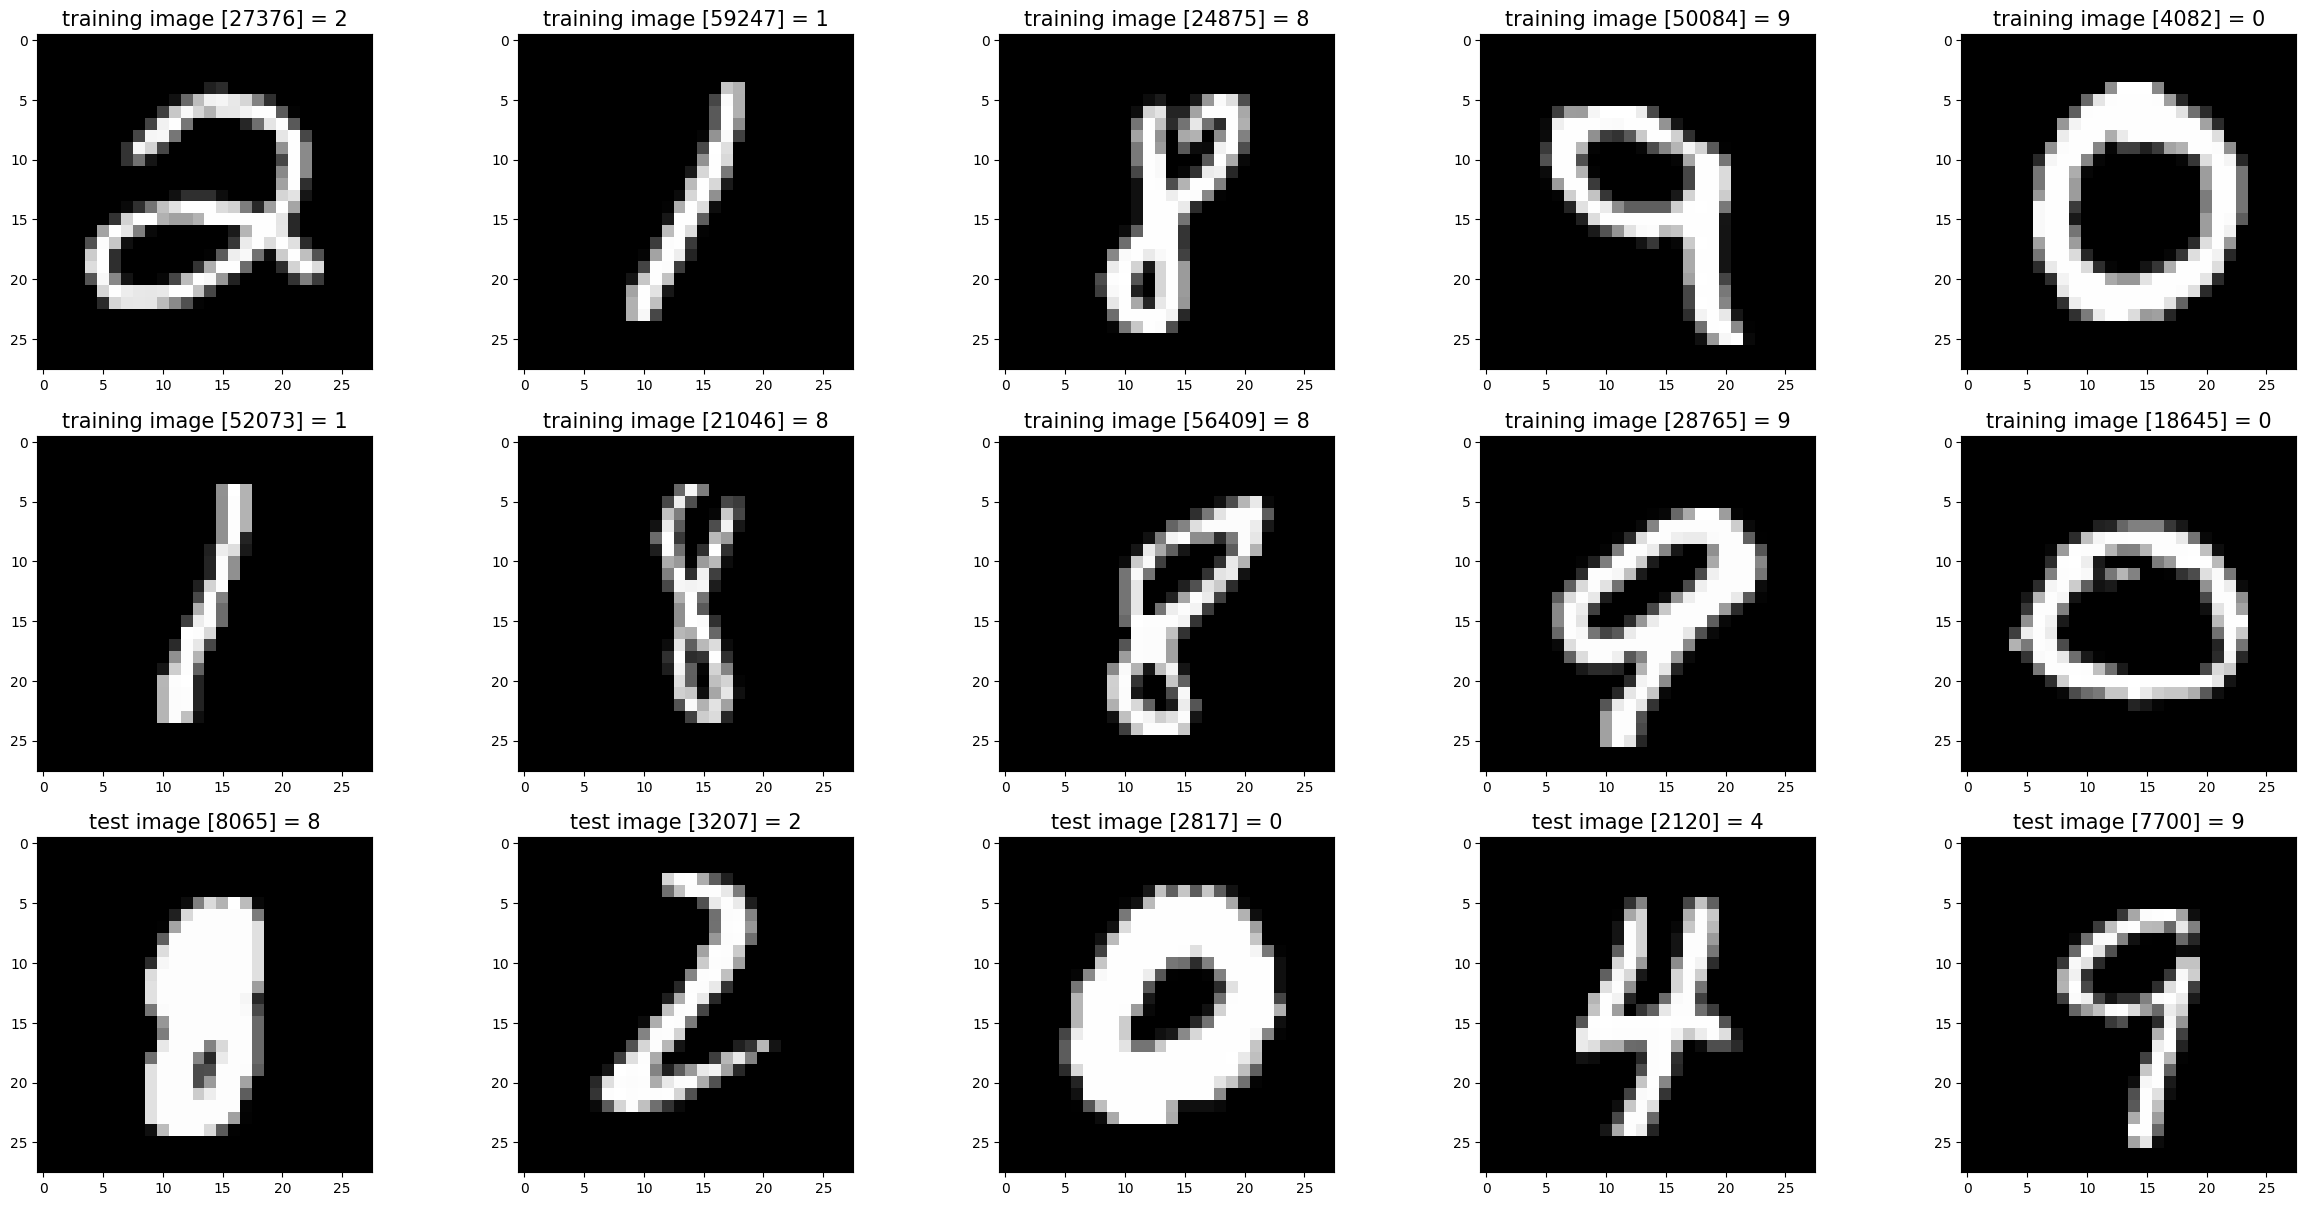

In [12]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'mnist'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [13]:
x_train_array = np.stack([np.concatenate(arrays) for arrays in x_train]) / 255
x_test_array = np.stack([np.concatenate(arrays) for arrays in x_test]) / 255

In [14]:
y_train_array = np.zeros((60000, 10))

for i in range(60000):
    digit = y_train[i]
    y_train_array[i, digit] = 1

y_test_array = np.zeros((10000, 10))

for i in range(10000):
    digit = y_test[i]
    y_test_array[i, digit] = 1

In [15]:
def stroke(thickness, length, direction, start_x, start_y):
    # thickness: size of square of each dot
    # length: number of dots placed
    # direction: 0 for right, 1 for diagonal down right, 2 for down, 3 for diagonal down left
    # start_x, start_y: top-left coordinate of starting stroke

    if direction == 0:
        image_left = start_x
        image_right = start_x + (thickness - 1) + (length - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1)
    elif direction == 1:
        image_left = start_x
        image_right = start_x + (thickness - 1) + (length - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)
    elif direction == 2:
        image_left = start_x
        image_right = start_x + (thickness - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)
    elif direction == 3:
        image_left = start_x - (length - 1)
        image_right = start_x + (thickness - 1)
        image_top = start_y
        image_bottom = start_y + (thickness - 1) + (length - 1)

    if not (0 <= image_left <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_right <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_top <= 27):
        raise ValueError("Image out of bounds")
    if not (0 <= image_bottom <= 27):
        raise ValueError("Image out of bounds")

    image = np.zeros((28,28))

    current_x = start_x
    current_y = start_y

    for i in range(length):
        image[current_y:current_y+thickness, current_x:current_x+thickness] = 1
        if direction == 0:
            current_x += 1
        elif direction == 1:
            current_x += 1
            current_y += 1
        elif direction == 2:
            current_y += 1
        elif direction == 3:
            current_x -= 1
            current_y += 1

    return image.reshape(784)

In [16]:
training_digit_indices = {n: [] for n in range(10)}

for i in range(60000):
    digit = y_train[i]
    training_digit_indices[digit].append(i)

In [17]:
cero = training_digit_indices[0]
uno = training_digit_indices[1]
dos = training_digit_indices[2]
tres = training_digit_indices[3]
cuatro = training_digit_indices[4]
cinco = training_digit_indices[5]
seis = training_digit_indices[6]
siete = training_digit_indices[7]
ocho = training_digit_indices[8]
nueve = training_digit_indices[9]

In [36]:
cero_sample = np.random.choice(cero, 10, replace=False)
uno_sample = np.random.choice(uno, 10, replace=False)
dos_sample = np.random.choice(dos, 10, replace=False)
tres_sample = np.random.choice(tres, 10, replace=False)
cuatro_sample = np.random.choice(cuatro, 10, replace=False)
cinco_sample = np.random.choice(cinco, 10, replace=False)
seis_sample = np.random.choice(seis, 10, replace=False)
siete_sample = np.random.choice(siete, 10, replace=False)
ocho_sample = np.random.choice(ocho, 10, replace=False)
nueve_sample = np.random.choice(nueve, 10, replace=False)

In [37]:
import pickle

mnist_nn2 = NeuralNetwork([784, 550, 50, 10], sigma=0.0, activation=sigmoid, d_activation=d_sigmoid)

biases = pickle.load(open("mnist_nn_biases_2026-04-11_20-46-25.pkl", 'rb'))
mnist_nn2.biases = biases

weights = pickle.load(open("mnist_nn_weights_2026-04-11_20-46-25.pkl", 'rb'))
mnist_nn2.weights = weights

In [38]:
mnist_nn2.valid_state()

True

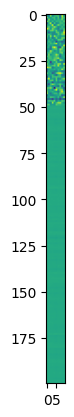

In [39]:
plt.imshow(mnist_nn2.weights[2])

In [75]:
def predict_digit(nn, image):
    output = nn.forward(image)[0][-1]
    return np.argmax(output)

In [76]:
def test_nn(nn, test_indices):
    correct_answers = 0
    questions_by_digit = {n: 0 for n in range(0,10)}
    correct_answers_by_digit = {n: 0 for n in range(0,10)}

    for index in test_indices:
        questions_by_digit[y_test[index]] += 1
        prediction = predict_digit(nn, x_test_array[index, :])
        if prediction == y_test[index]:
            correct_answers += 1
            correct_answers_by_digit[y_test[index]] += 1
    rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}
    return correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit

Testing model and calibrating training regimen...
Training iteration 10...
Training iteration 20...
Testing model and calibrating training regimen...
Training iteration 30...
Training iteration 40...
Testing model and calibrating training regimen...
Training iteration 50...
Training iteration 60...
Testing model and calibrating training regimen...
Training iteration 70...
Training iteration 80...
Testing model and calibrating training regimen...
Training iteration 90...
Training iteration 100...


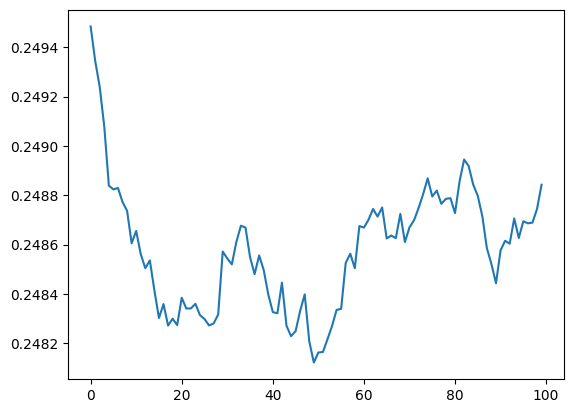

In [31]:
error_history = []

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

digit_sets = [cero, uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve]

for i in range(100):
    if i % 20 == 0:
        print("Testing model and calibrating training regimen...")
        validation_indices = np.random.choice(range(10000), size=1000, replace=False)

        correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, validation_indices)

        digits_order = np.argsort(list(rate_by_digit.values()))
        first_priority = [digit_sets[n] for n in digits_order[0:1]]
        high_priority = [digit_sets[n] for n in digits_order[1:2]]
        medium_priority = [digit_sets[n] for n in digits_order[2:5]]
        low_priority = [digit_sets[n] for n in digits_order[5:10]]

        probabilities = np.zeros(60000)
        probabilities[np.concatenate(first_priority)] = 5
        probabilities[np.concatenate(high_priority)] = 4
        probabilities[np.concatenate(medium_priority)] = 3
        probabilities[np.concatenate(low_priority)] = 2
        probabilities /= np.sum(probabilities)
        
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn2.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.005, rel_noise = 0.0)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn2.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    error_history.append(error)
    if error < 0.2:
        break

correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn2, test_indices)

plt.plot(error_history)

<BarContainer object of 10 artists>

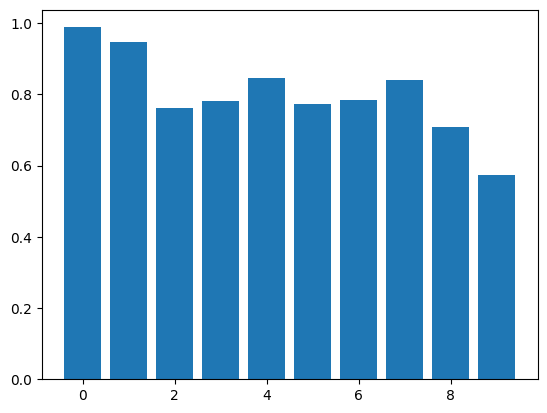

In [32]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [33]:
correct_answers

801

In [18]:
import datetime

In [35]:
filename = f"mnist_nn_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.weights, open(filename, 'wb'))

filename = f"mnist_nn_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn2.biases, open(filename, 'wb'))

# Expanding the neural network

Now, after we have trained the network enough times, it will inevitably reach a point where it is no longer able to learn significantly because there are not enough parameters to allow it to learn very precisely. The neural network we have used at each point has used neuron layers with lengths $(784, 550, 50, 10)$. But what if we want to expand this further, say we expand the layer with 50 neurons into 200, or add an additional layer? We look at two operations: expanding one layer to make it have more neurons while keeping the core operation intact, and adding an additional layer while keeping the operation approximately the same, while changing only the weight and bias matrices. Respectively, these problems aim to make our network wider, and make our network deeper.

The first problem we look at is: Suppose we have the following neuron processing sequence as a part:
$$
\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} \xrightarrow{g^{(\ell)}} \textbf{h}^{(\ell)}_{(n_{\ell})} \xrightarrow{g^{(\ell+1)}} \textbf{h}^{(\ell+1)}_{(n_{\ell+1})}
$$
We want to expand the vector $\textbf{h}^{(\ell)}_{n_{\ell}}$ with a new, longer length, $n_{\ell}^{\text{new}}$ while keeping this sequence unchanged. We will need some new functions to make this chain work like the following:
$$
\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} \xrightarrow{g^{(\ell)}_{\text{new}}} {\textbf{h}^{(\ell)}_{\text{new}}}_{(n_{\ell}^{\text{new}})} \xrightarrow{g^{(\ell+1)}_{\text{new}}} {\textbf{h}^{(\ell+1)}_{\text{new}}}_{(n_{\ell+1})}
$$
Recall how we originally defined these functions:
$$
\textbf{h}^{(\ell)} = g^{(\ell)}(\textbf{h}^{(\ell-1)}) = f(z^{(\ell)}(\textbf{h}^{(\ell-1)})), z^{(\ell)}(\textbf{h}^{(\ell-1)}) = \textbf{h}^{(\ell-1)}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)}
$$
To get these new functions to work, we can do this by expanding $W^{(\ell)}$ and $\textbf{b}^{(\ell)}$ vertically so there are $n_{\ell}^{\text{new}}$ columns. We can define:
$$
{W^{(\ell)}_{\text{new}}}_{(n_{\ell-1} \times n_\ell^{\text{new}})} = \begin{bmatrix} W^{(\ell)} & W^{(\ell)}_{\text{ext}} \end{bmatrix}, {\textbf{b}^{(\ell)}_{\text{new}}}_{(n_\ell^{\text{new}})} = \begin{bmatrix} \textbf{b}^{(\ell)} & \textbf{b}^{(\ell)}_{\text{ext}} \end{bmatrix}
$$
Defining the new functions based on this allows us to do the following:
$$
z^{(\ell)}_{\text{new}}(\textbf{h}^{(\ell-1)})_{(n_\ell^{\text{new}})} = \textbf{h}^{(\ell-1)}_{(n_{\ell-1})} {W^{(\ell)}_{\text{new}}}_{(n_{\ell-1} \times n_\ell^{\text{new}})} + {\textbf{b}^{(\ell)}_{\text{new}}}_{(n_\ell^{\text{new}})} = \begin{bmatrix} \textbf{h}^{(\ell-1)} W^{(\ell)} + \textbf{b}^{(\ell)} & \textbf{h}^{(\ell-1)} W^{(\ell)}_{\text{ext}} + \textbf{b}^{(\ell)}_{\text{ext}} \end{bmatrix}
$$
$$
{\textbf{h}^{(\ell)}_{\text{new}}}_{(n_\ell^{\text{new}})} = g^{(\ell)}_{\text{new}}(\textbf{h}^{(\ell-1)}) = f(z^{(\ell)}_{\text{new}}(\textbf{h}^{(\ell-1)})) = \begin{bmatrix} \textbf{h}^{(\ell)} & \textbf{h}^{(\ell)}_{\text{ext}} \end{bmatrix}
$$
Then, the next function also needs to be reconfigured so the dimensions agree. Recall again:
$$
\textbf{h}^{(\ell+1)} = g^{(\ell+1)}(\textbf{h}^{(\ell)}) = f(z^{(\ell+1)}(\textbf{h}^{(\ell)})), z^{(\ell+1)}(\textbf{h}^{(\ell)}) = \textbf{h}^{(\ell)}_{(n_{\ell})} W^{(\ell+1)}_{(n_{\ell} \times n_{\ell+1})} + \textbf{b}^{(\ell+1)}_{(n_{\ell+1})}
$$
Since $\textbf{h}^{(\ell)}_{\text{new}}$ has dimension $n_\ell^{\text{new}}$, we need to change the matrix $W^{(\ell+1)}$ so the height is $n_\ell^{\text{new}}$. We can expand this vertically by defining the new matrix:
$$
{W^{(\ell+1)}_{\text{new}}}_{(n_\ell^{\text{new}} \times n_{\ell+1})} = \begin{bmatrix} W^{(\ell+1)} \\ W^{(\ell+1)}_{\text{ext}} \end{bmatrix}
$$
Then we can use this to define our new functions:
$$
z^{(\ell+1)}_{\text{new}}(\textbf{h}^{(\ell)}_{\text{new}}) = {\textbf{h}^{(\ell)}_{\text{new}}}_{(n_{\ell}^{\text{new}})} {W^{(\ell+1)}_{\text{new}}}_{(n_{\ell}^{\text{new}} \times n_{\ell+1})} + \textbf{b}^{(\ell+1)}_{(n_{\ell+1})} = \textbf{h}^{(\ell)} W^{(\ell+1)} + \textbf{h}^{(\ell)}_{\text{ext}} W^{(\ell+1)}_{\text{ext}} + \textbf{b}^{(\ell+1)} = z^{(\ell+1)}(\textbf{h}^{(\ell)}) + \textbf{h}^{(\ell)}_{\text{ext}} W^{(\ell+1)}_{\text{ext}}
$$
$$
\textbf{h}^{(\ell+1)}_{\text{new}} = g^{(\ell+1)}_{\text{new}}(\textbf{h}^{(\ell)}_{\text{new}}) = f(z^{(\ell+1)}_{\text{new}}(\textbf{h}^{(\ell)}_{\text{new}}))
$$
One question that follows is how we can configure our expansion so that the output at the end of the chain remains unchanged. To do this we can just do it so that $\textbf{h}^{(\ell)}_{\text{ext}} W^{(\ell+1)}_{\text{ext}} = \textbf{0}$. The natural choice for this extension would be to set $W^{(\ell+1)}_{\text{ext}} = 0$, but the problem is the neurons may never be activated and used for training. So what we can do is to instead initialize white noise into this by setting $W^{(\ell+1)}_{\text{ext}} = \varepsilon_{((n_{\ell}^{\text{new}} - n_{\ell}) \times n_{\ell+1})}$.

But what is our choice for the other matrices and biases we are expanding? These choices influence exactly what $\textbf{h}^{(\ell)}_{\text{ext}}$ would become, which we have defined as:
$$
{\textbf{h}^{(\ell)}_{\text{ext}}}_{(n_{\ell}^{\text{new}} - n_{\ell})} = f(\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} {W^{(\ell)}_{\text{ext}}}_{(n_{\ell-1} \times (n_{\ell}^{\text{new}} - n_{\ell}))} + {\textbf{b}^{(\ell)}_{\text{ext}}}_{(n_{\ell}^{\text{new}} - n_{\ell})})
$$
We can set $W^{(\ell)}_{\text{ext}}$ and $\textbf{b}^{(\ell)}_{\text{ext}}$ to be random white noise, again. But what influences how much the neurons afterward get influenced is the matrix $W^{(\ell+1)}_{\text{ext}}$. To reduce this perturbation effect, we should set this matrix to have a small standard deviation for each entry, and should be zero-centered, so that if we add more neurons in a layer it does not affect the output too often so as to make performance significantly worse.

Overall, the procedure for increasing the width of a layer of the neural network involves the concatenation of three different matrices, which we decide to be random noise at a suitable scale.

The second problem we will explore is: How can we insert a new layer into our neural network? If our original chain goes like:
$$
\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} \xrightarrow{g^{(\ell)}} \textbf{h}^{(\ell)}_{(n_{\ell})}
$$
How do we insert a new layer in between these two? Lets say the neuron has a length of $n_{\ell'}$, and we want to make a chain of functions that goes like:
$$
\textbf{h}^{(\ell-1)}_{(n_{\ell-1})} \xrightarrow{g^{(\ell)}_{\text{left}}} \textbf{h}^{(\ell')}_{(n_{\ell'})} \xrightarrow{g^{(\ell)}_{\text{right}}} \textbf{h}^{(\ell)}_{(n_{\ell})}
$$
Recall again our function:
$$
g^{(\ell)}(\textbf{h}^{(\ell-1)}) = f(z^{(\ell)}(\textbf{h}^{(\ell-1)})), z^{(\ell)}(\textbf{h}^{(\ell-1)}) = \textbf{h}^{(\ell-1)}_{(n_{\ell-1})} W^{(\ell)}_{(n_{\ell-1} \times n_\ell)} + \textbf{b}^{(\ell)}_{(n_\ell)}
$$
Getting these specific functions becomes a challenge. And we also need some assumptions, which is that we can reasonably assume that $n_{\ell'} \geq n_{\ell}$, to allow a wide range of information to be transmitted. Let's try defining the left function first as the following:
$$
g^{(\ell)}_{\text{left}}(\textbf{h}^{(\ell-1)}) = f(z^{(\ell)}_{\text{left}}(\textbf{h}^{(\ell-1)})), z^{(\ell)}_{\text{left}}(\textbf{h}^{(\ell-1)}) = \textbf{h}^{(\ell-1)}_{(n_{\ell-1})} {W^{(\ell)}_{\text{left}}}_{(n_{\ell-1} \times n_{\ell'})} + {\textbf{b}^{(\ell)}_{\text{left}}}_{(n_{\ell'})}
$$
Where we define the new matrices by extending the originals horizontally:
$$
{W^{(\ell)}_{\text{left}}}_{(n_{\ell-1} \times n_{\ell'})} = \begin{bmatrix} W^{(\ell)} & W^{(\ell)}_{\text{ext}} \end{bmatrix}, {\textbf{b}^{(\ell)}_{\text{left}}}_{(n_{\ell'})} = \begin{bmatrix} \textbf{b}^{(\ell)} & \textbf{b}^{(\ell)}_{\text{ext}} \end{bmatrix}
$$
In this case we have the following output for the middle layer:
$$
\textbf{z}^{(\ell)}_{(n_{\ell'})} = \begin{bmatrix} \textbf{h}^{(\ell-1)} W^{(\ell)} + \textbf{b}^{(\ell)} & \textbf{h}^{(\ell-1)} W^{(\ell)}_{\text{ext}} + \textbf{b}^{(\ell)}_{\text{ext}} \end{bmatrix}, \textbf{h}^{(\ell')}_{(n_{\ell'})} = g^{(\ell)}_{\text{left}}(\textbf{h}^{(\ell-1)}) = f(\textbf{z}^{(\ell')})
$$
Notice that the first part of this resulting row vector is the same as what we had as the original output. But for the right function, we need some special construction to map the vector $\textbf{h}^{(\ell')}$ using the function $g^{(\ell)}_{\text{right}}$. Specifically, we want:
$$
g^{(\ell)}_{\text{right}}(\textbf{h}^{(\ell')}) = \textbf{h}^{(\ell)} \Rightarrow z^{(\ell)}_{\text{right}}(\textbf{h}^{(\ell')}) = \textbf{h}^{(\ell')} {W^{(\ell)}_{\text{right}}}_{(n_{\ell'} \times n_{\ell})} + {\textbf{b}^{(\ell)}_{\text{right}}}_{(n_{\ell})} = f^{-1}(\textbf{h}^{(\ell)})
$$
The problem is, $f^{-1}$ is not a linear function, and $f$ may not be invertible, so this cannot really be achieved. However, a good approximation we can use is to use a mapping that approximates $f^{-1}$ linearly. We propose using a diagonal matrix for the part of the matrix $W^{(\ell)}_{\text{right}}$ that maps the first part of the vector $\textbf{h}^{(\ell')}$, since it maps that part elementwise, with all diagonal entries the same, and for the bias $\textbf{b}^{(\ell)}_{\text{right}}$, we have all of the components as one number. Depending on the activation function, we can find a linear mapping that maps most values such that:
$$
f(wx + b) \approx x \Leftrightarrow wx + b \approx f^{-1}(x)
$$
for $x$ in the range of $f$. For example, if $f = \sigma$, the sigmoid function, the range is $(0, 1)$, and since $\sigma'(0) = 1/4$ is the point with the maximum derivative, we center on the point $(0, 1/2)$ of the sigmoid function and invoke the inverse function theorem, then we can take $w = 4$ and $b = -2$ for this specific example.

Then we take the diagonal entries of the top part of $W^{(\ell)}_{\text{right}}$ to be $w$ and each entry of $\textbf{b}^{(\ell)}_{\text{right}}$ to be $b$. All other entries of $W^{(\ell)}_{\text{right}}$ are zero if we want a pure transformation, but to allow the neural network to train itself via backpropagation, we can perturb these weights and biases with some noise, like white noise.

We have developed a procedure for initializing weight parameters for when a neural network gets widened or deepened, adhering to the original weights as much as possible so the result doesn't change significantly upon initialization. relative to before the change has been implemented. The model should perform as accurately as before with this change accompanied by the given procedure, and hopefully with the new neurons or a new layer, it can learn even deeper and produce even better results.

So now let's create a new neural network to see how well it would perform in terms of learning if we use the outlined procedure to increase the width of a layer.

In [17]:
import pickle

In [18]:
mnist_nn3 = NeuralNetwork([784, 550, 200, 10], activation=sigmoid, d_activation=d_sigmoid, inv_activation=inv_sigmoid)

biases = pickle.load(open("mnist_nn_biases_2026-03-23_14-20-43.pkl", 'rb'))
mnist_nn3.biases = biases

weights = pickle.load(open("mnist_nn_weights_2026-03-23_14-20-43.pkl", 'rb'))
mnist_nn3.weights = weights

In [53]:
mnist_nn3.set_weight(1, np.concatenate((mnist_nn3.weights[1], np.random.normal(scale=0.01, size=(550, 150))), axis=1))
mnist_nn3.set_bias(1, np.concatenate((mnist_nn3.biases[1], np.random.normal(scale=0.01, size=(150, )))))
mnist_nn3.set_weight(2, np.concatenate((mnist_nn3.weights[2], np.random.normal(scale=0.001, size=(150, 10))), axis=0))

mnist_nn3.valid_state()

True

Testing model and calibrating training regimen...
Training iteration 10...
Training iteration 20...
Testing model and calibrating training regimen...
Training iteration 30...
Training iteration 40...
Testing model and calibrating training regimen...
Training iteration 50...
Training iteration 60...
Testing model and calibrating training regimen...
Training iteration 70...
Training iteration 80...
Testing model and calibrating training regimen...
Training iteration 90...
Training iteration 100...
Testing model and calibrating training regimen...
Training iteration 110...
Training iteration 120...
Testing model and calibrating training regimen...
Training iteration 130...
Training iteration 140...
Testing model and calibrating training regimen...
Training iteration 150...
Training iteration 160...
Testing model and calibrating training regimen...
Training iteration 170...
Training iteration 180...
Testing model and calibrating training regimen...
Training iteration 190...
Training iterat

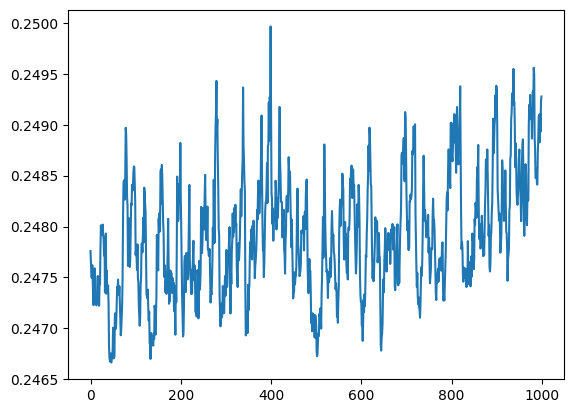

In [38]:
error_history = []

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

digit_sets = [cero, uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve]

for i in range(1000):
    if i % 20 == 0:
        print("Testing model and calibrating training regimen...")
        validation_indices = np.random.choice(range(10000), size=1000, replace=False)

        correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn3, validation_indices)

        digits_order = np.argsort(list(rate_by_digit.values()))
        first_priority = [digit_sets[n] for n in digits_order[0:1]]
        high_priority = [digit_sets[n] for n in digits_order[1:2]]
        medium_priority = [digit_sets[n] for n in digits_order[2:5]]
        low_priority = [digit_sets[n] for n in digits_order[5:10]]

        probabilities = np.zeros(60000)
        probabilities[np.concatenate(first_priority)] = 5
        probabilities[np.concatenate(high_priority)] = 4
        probabilities[np.concatenate(medium_priority)] = 3
        probabilities[np.concatenate(low_priority)] = 2
        probabilities /= np.sum(probabilities)
        
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn3.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0.0)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn3.error(testing_sample_x, testing_sample_y * 0.6 + 0.3)
    error_history.append(error)
    if error < 0.24:
        break

correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn3, test_indices)

plt.plot(error_history)

<BarContainer object of 10 artists>

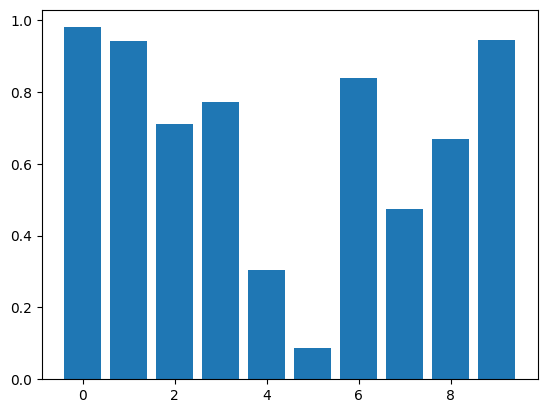

In [39]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [40]:
correct_answers

686

In [41]:
filename = f"mnist_nn_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn3.weights, open(filename, 'wb'))

filename = f"mnist_nn_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn3.biases, open(filename, 'wb'))

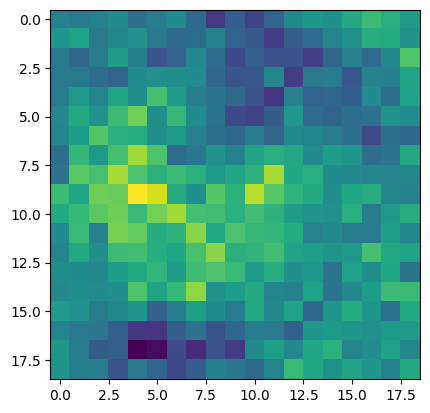

In [53]:
plt.imshow(mnist_nn3.weights[0][:, 3].reshape((28, 28))[6:25,6:25])

It seems our error is decreasing once again - gradually - when we add more neurons into one of our layers. It gives us more space for the neural network to explore more feature combinations for the second hidden layer. Though the number of correct answers doesn't seem to be reflected so well (yet) because it is learning new features. But what if we add one more layer just before the output layer?

## Auto-encoders

What if we want to compress the data we have into an image to a number of features? The aim is to have a function that can map an image of a digit onto some encoded set of features in a small set, the bottleneck, and is also able to decode back into an image that is close to the original input. The neural network architecture we have developed here is useful for this task, and then using this, we can facilitate the identification of digits.

The idea behind the auto-encoder is that it takes in an input, $\textbf{x}_{(n_i)}$, runs it through a neural network to produce an encoded output in the middle, $\textbf{y}_{(n_o)}$, via a function like $f(\textbf{x}{W_e}_{(n_i \times n_o)} + {\textbf{b}_e}_{(n_o)})$ using an encoding function. In the decoding step, the encoded input should produce as close to the original input as possible, that is $\textbf{x} \approx f(\textbf{y}{W_d}_{(n_o \times n_i)} + {\textbf{b}_d}_{(n_i)})$. To get reliable results, we train this to a reasonable accuracy to extract a smaller number of features than data components, like we would train with our previous neural networks.

In our code, we can define a new auto-encoder class that builds on the neural network class we previously built.

In [80]:
class AutoEncoder(NeuralNetwork):
    def __init__(self, input_length, encoding_length, sigma=0.01, activation=relu, d_activation=d_relu, inv_activation=inv_relu, vectorize=True):
        super().__init__([input_length, encoding_length, input_length], sigma=sigma, activation=activation, d_activation=d_activation, inv_activation=inv_activation, vectorize=vectorize)

    def train_samples(self, training_inputs, learning_rate=0.01, rel_noise=0, max_parameter_change=0.1, average=True, apply=True):
        self.backpropagation(training_inputs=training_inputs, training_outputs=training_inputs, learning_rate=learning_rate, rel_noise=rel_noise, max_parameter_change=max_parameter_change, average=average, apply=apply)

    def encode(self, inputs):
        if type(inputs) != np.ndarray:
            raise TypeError("Input must be array of dimension 1 or 2")
        if len(inputs.shape) == 1:
            if inputs.shape[0] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {inputs.shape[0]} != {self.weights[0].shape[0]}")
        elif len(inputs.shape) == 2:
            if inputs.shape[1] != self.weights[0].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {inputs.shape[1]} != {self.weights[0].shape[0]}")
        else:
            raise TypeError("Input must be array of dimension 1 or 2")
        encoded_data = inputs @ self.weights[0] + self.biases[0]
        encoded_data = self.activation(encoded_data)
        return encoded_data

    def decode(self, encoded_inputs):
        if type(encoded_inputs) != np.ndarray:
            raise TypeError("Input must be array of dimension 1 or 2")
        if len(encoded_inputs.shape) == 1:
            if encoded_inputs.shape[0] != self.weights[1].shape[0]:
                raise DimensionMismatch(f"Input vector length mismatch: {encoded_inputs.shape[0]} != {self.weights[1].shape[0]}")
        elif len(encoded_inputs.shape) == 2:
            if encoded_inputs.shape[1] != self.weights[1].shape[0]:
                raise DimensionMismatch(f"Input array dimensions mismatch: {encoded_inputs.shape[1]} != {self.weights[1].shape[0]}")
        else:
            raise TypeError("Input must be array of dimension 1 or 2")
        decoded_data = encoded_inputs @ self.weights[1] + self.biases[1]
        decoded_data = self.activation(decoded_data)
        return decoded_data
    
    def error(self, inputs, dist_mode='l2', agg_mode='avg'):
        return super().error(inputs, inputs, dist_mode=dist_mode, agg_mode=agg_mode)

In [81]:
mnist_autoencoder = AutoEncoder(784, 50, activation=sigmoid, d_activation=d_sigmoid, inv_activation=inv_sigmoid)

Training iteration 10...
Training iteration 20...


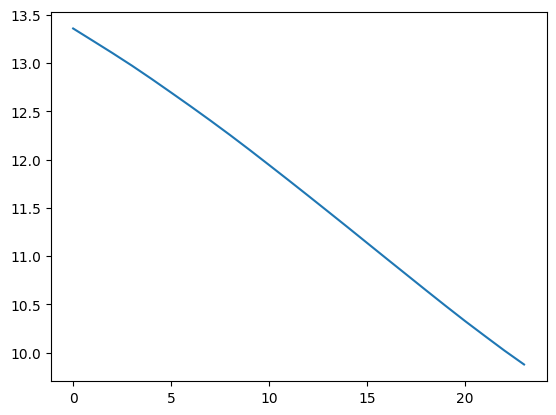

In [27]:
error_history = []

for i in range(100):
    sample_indices = np.random.choice(range(60000), size=100, replace=False)
    training_sample = x_train_array[sample_indices, :]
    mnist_autoencoder.train_samples(training_sample, learning_rate=0.01)
    error = mnist_autoencoder.error(x_train_array[0:500, :])
    error_history.append(error)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    if error < 10:
        break

plt.plot(error_history)

This is what an error graph looks like after one round of training the autoencoder network for 100 iterations. Eventually it will settle into a certain error. Now, let's see what a digit looks like when decoded with our autoencoder.

In [28]:
sample_n = np.random.choice(60000)

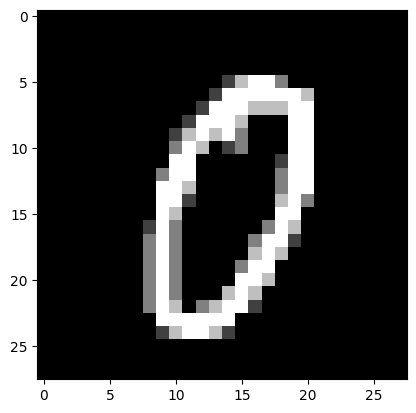

In [29]:
plt.imshow(x_train_array[sample_n].reshape((28, 28)), cmap=plt.cm.gray)

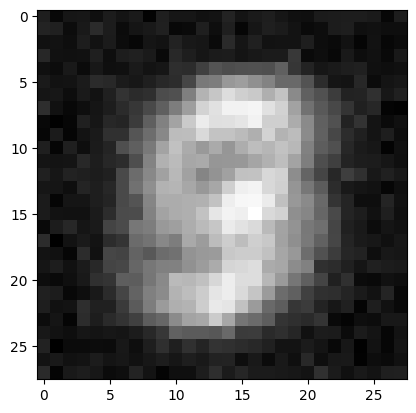

In [30]:
plt.imshow(mnist_autoencoder.forward(x_train_array[sample_n])[0][-1].reshape((28, 28)), cmap=plt.cm.gray)

Doesn't look so good when decoded. But that's a starting point, and we can work towards making it more reliable by trying to reduce the error.

Training iteration 10...
Training iteration 20...
Training iteration 30...
Training iteration 40...
Training iteration 50...
Training iteration 60...
Training iteration 70...
Training iteration 80...
Training iteration 90...
Training iteration 100...


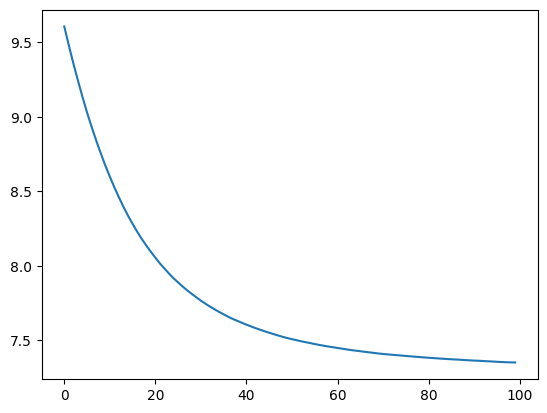

In [32]:
error_history = []

for i in range(100):
    sample_indices = np.random.choice(range(60000), size=100, replace=False)
    training_sample = x_train_array[sample_indices, :]
    mnist_autoencoder.train_samples(training_sample, learning_rate=0.01)
    error = mnist_autoencoder.error(x_train_array[0:500, :])
    error_history.append(error)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    if error < 5:
        break

plt.plot(error_history)

The error has decreased further, with a smaller change. But does this make things more accurate?

In [33]:
sample_n = np.random.choice(60000)

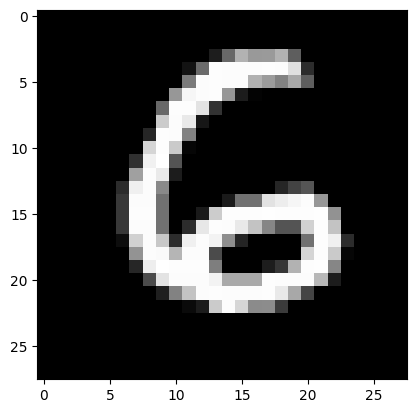

In [34]:
plt.imshow(x_train_array[sample_n].reshape((28, 28)), cmap=plt.cm.gray)

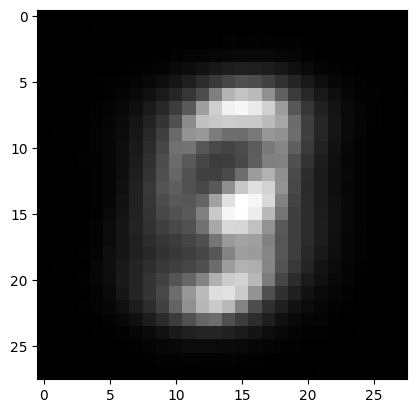

In [35]:
plt.imshow(mnist_autoencoder.forward(x_train_array[sample_n])[0][-1].reshape((28, 28)), cmap=plt.cm.gray)

Training iteration 10...
Training iteration 20...
Training iteration 30...
Training iteration 40...
Training iteration 50...
Training iteration 60...
Training iteration 70...
Training iteration 80...
Training iteration 90...
Training iteration 100...
Training iteration 110...
Training iteration 120...
Training iteration 130...
Training iteration 140...
Training iteration 150...
Training iteration 160...
Training iteration 170...
Training iteration 180...
Training iteration 190...
Training iteration 200...
Training iteration 210...
Training iteration 220...
Training iteration 230...
Training iteration 240...
Training iteration 250...
Training iteration 260...
Training iteration 270...
Training iteration 280...
Training iteration 290...
Training iteration 300...
Training iteration 310...
Training iteration 320...
Training iteration 330...
Training iteration 340...
Training iteration 350...
Training iteration 360...
Training iteration 370...
Training iteration 380...
Training iteration 39

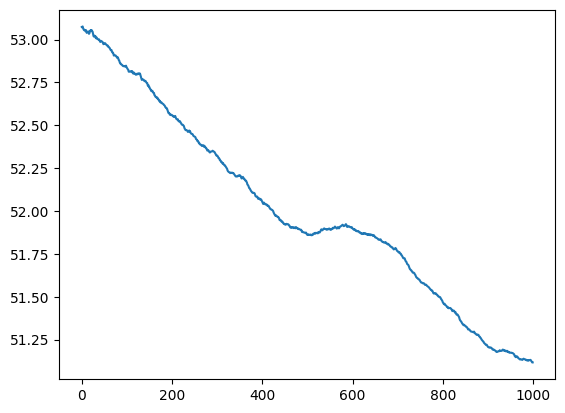

In [ ]:
error_history = []

for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=100, replace=False)
    training_sample = x_train_array[sample_indices, :]
    mnist_autoencoder.train_samples(training_sample, learning_rate=0.01)
    error = mnist_autoencoder.error(x_train_array[0:500, :])
    error_history.append(error)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    if error < 10:
        break

plt.plot(error_history)

In [38]:
import pickle

import datetime

In [52]:
filename = f"mnist_autoencoder_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_autoencoder.weights, open(filename, 'wb'))

filename = f"mnist_autoencoder_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_autoencoder.biases, open(filename, 'wb'))

In [120]:
mnist_autoencoder = AutoEncoder(784, 50, sigma=0.0, activation=sigmoid, d_activation=d_sigmoid, vectorize=False)

biases = pickle.load(open("mnist_autoencoder_biases_2026-04-16_02-11-13.pkl", 'rb'))
mnist_autoencoder.biases = biases

weights = pickle.load(open("mnist_autoencoder_weights_2026-04-16_02-11-13.pkl", 'rb'))
mnist_autoencoder.weights = weights

Training iteration 10...
Training iteration 20...
Training iteration 30...
Training iteration 40...
Training iteration 50...
Training iteration 60...
Training iteration 70...
Training iteration 80...
Training iteration 90...
Training iteration 100...
Training iteration 110...
Training iteration 120...
Training iteration 130...
Training iteration 140...
Training iteration 150...
Training iteration 160...
Training iteration 170...
Training iteration 180...
Training iteration 190...
Training iteration 200...
Training iteration 210...
Training iteration 220...
Training iteration 230...
Training iteration 240...
Training iteration 250...
Training iteration 260...
Training iteration 270...
Training iteration 280...
Training iteration 290...
Training iteration 300...
Training iteration 310...
Training iteration 320...
Training iteration 330...
Training iteration 340...
Training iteration 350...
Training iteration 360...
Training iteration 370...
Training iteration 380...
Training iteration 39

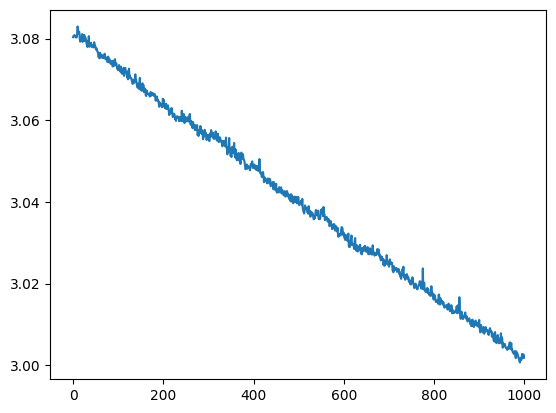

In [203]:
error_history = []

for i in range(1000):
    sample_indices = np.random.choice(range(60000), size=100, replace=False)
    training_sample = x_train_array[sample_indices, :]
    mnist_autoencoder.train_samples(training_sample, learning_rate=0.1)
    error = mnist_autoencoder.error(x_train_array[0:500, :], dist_mode='l2')
    error_history.append(error)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    if error < 2:
        break

plt.plot(error_history)

In [206]:
filename = f"mnist_autoencoder_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_autoencoder.weights, open(filename, 'wb'))

filename = f"mnist_autoencoder_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_autoencoder.biases, open(filename, 'wb'))

In [207]:
sample_n = np.random.choice(60000)

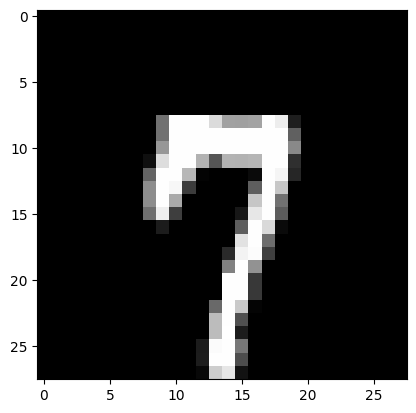

In [208]:
plt.imshow(x_train_array[sample_n].reshape((28, 28)), cmap=plt.cm.gray)

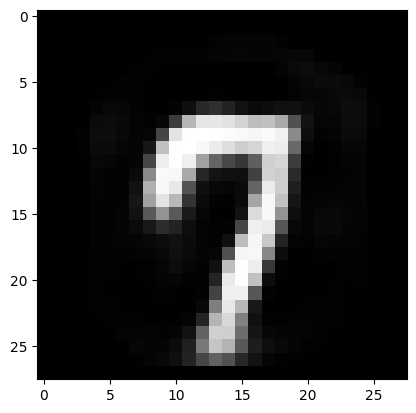

In [209]:
plt.imshow(mnist_autoencoder.forward(x_train_array[sample_n])[0][-1].reshape((28, 28)), cmap=plt.cm.gray)

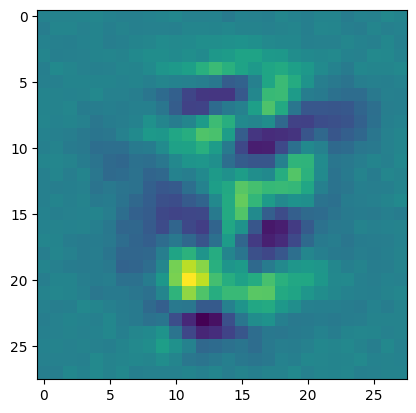

In [124]:
plt.imshow(mnist_autoencoder.weights[0][:, 24].reshape((28,28)))

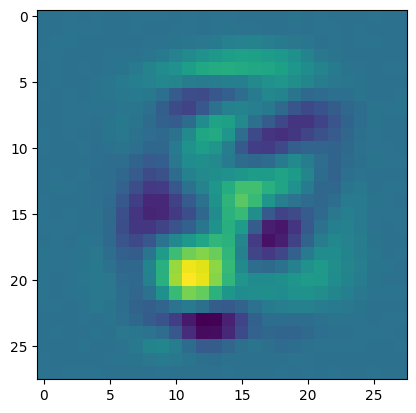

In [44]:
plt.imshow(mnist_autoencoder.weights[1][24].reshape((28,28)))

By running the training well, we can take the error down to about **12**. That means encoder-decoder gives results that are on average **12 pixels off** from the original image, which is good relative to our previous error value of about 50. And if you run the above code, you can see different images by changing the number after `:,` to view different images on which the weight of the encoder is based. This gives us an idea about the features the neural network has learned to detect. If the encoder can produce results that are similar enough, that means it has compressed the data of MNIST images into fewer dimensions and can use it to classify digits more easily by first using the encoder then converting the encoded data into a result that gives an idea of the digit.

One thing we can do next is see how different digits become different in encoded form using the autoencoder we built and trained. Are there differences in any of the feature coordinates between digits, say 1 and 6? We shall plot a graph of a sample of digits to see whether certain encoded features show up or don't show up in different images.

In [211]:
uno_sample = np.random.choice(uno, size=100)
seis_sample = np.random.choice(seis, size=100)

In [212]:
uno_sample_encoded = mnist_autoencoder.encode(x_train_array[uno_sample])
seis_sample_encoded = mnist_autoencoder.encode(x_train_array[seis_sample])

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\252907012.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


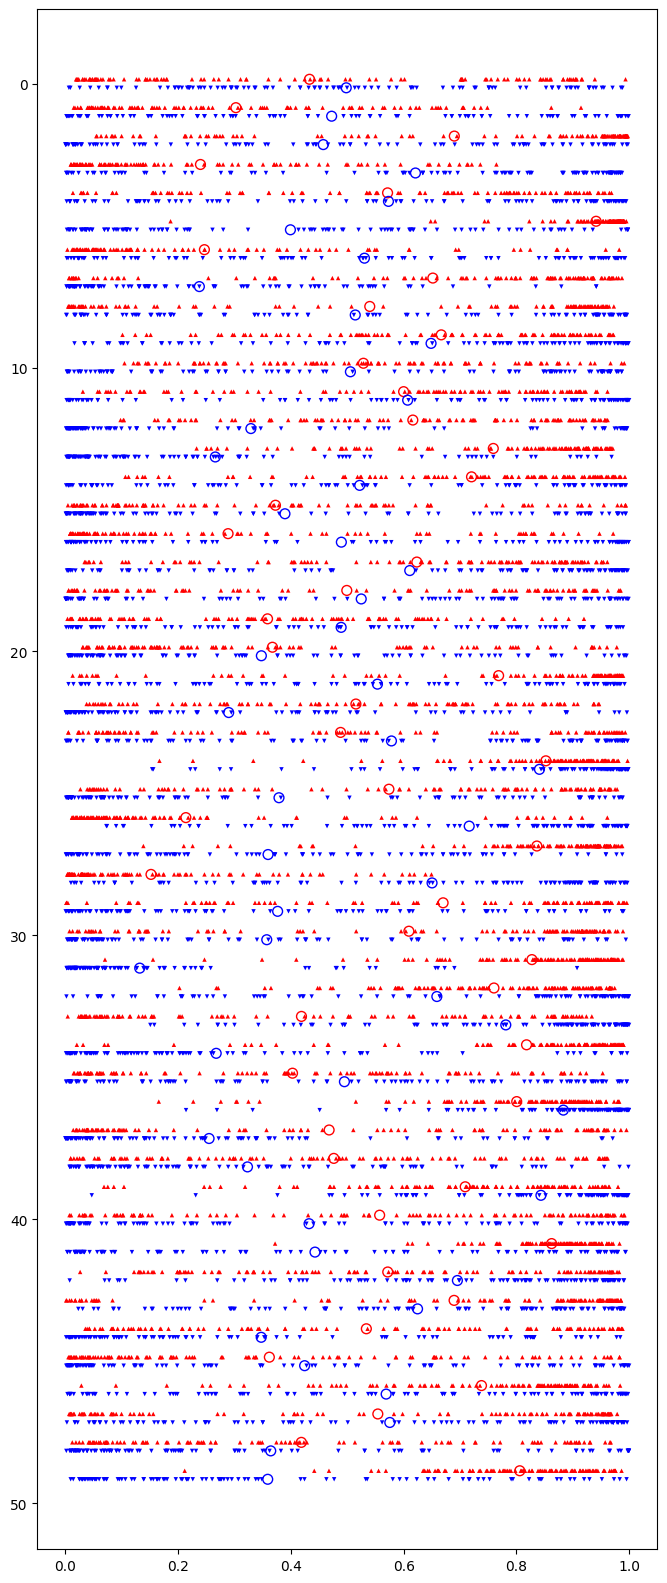

In [213]:
x_uno = np.reshape(uno_sample_encoded, (5000,), order='F')
x_seis = np.reshape(seis_sample_encoded, (5000,), order='F')

y_feature = np.reshape(np.broadcast_to(np.arange(50), (100, 50)), (5000,), order='F')

fig, ax = plt.subplots(figsize=(8, 20))

ax.yaxis.set_inverted(True)

ax.scatter(x_uno, y_feature-0.15, s=10, marker='^', facecolors='r', edgecolors='none')
ax.scatter(x_seis, y_feature+0.15, s=10, marker='v', facecolors='b', edgecolors='none')

uno_averages = np.sum(uno_sample_encoded, axis=0) / 100
seis_averages = np.sum(seis_sample_encoded, axis=0) / 100
ax.scatter(uno_averages, np.arange(50)-0.15, s=50, marker='o', facecolors='none', edgecolors='r')
ax.scatter(seis_averages, np.arange(50)+0.15, s=50, marker='o', facecolors='none', edgecolors='b')

fig.show()

We've made a plot of how in each feature the values of the encoded data vary. 1s are in red and 6s are in blue, with the averages for each feature marked with a circle. We can see that there are plenty of features where red (1) is significantly higher than blue (6), which you can see in indices like 5, 13, 27, and 49. On the opposite, there are features where blue is significantly higher than red, which you can see in indices like 16, 26, 28, and 33.

Another thing we can do to make this more clear is to use density plots. To do this we can approximate it using a sliding window kernel with the function `estimate_density` written below.

In [214]:
def estimate_density(data, min=0, max=1, running_interval_size=0.1, step=0.01):
    points = np.linspace(min, max, int((max - min) / step))
    density_values = np.zeros_like(points)
    for data_point in data:
        for i in range(len(points)):
            if points[i] - running_interval_size/2 <= data_point <= points[i] + running_interval_size/2:
                density_values[i] += 1
    density_values /= len(data) * running_interval_size
    return points, density_values

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\1381283571.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


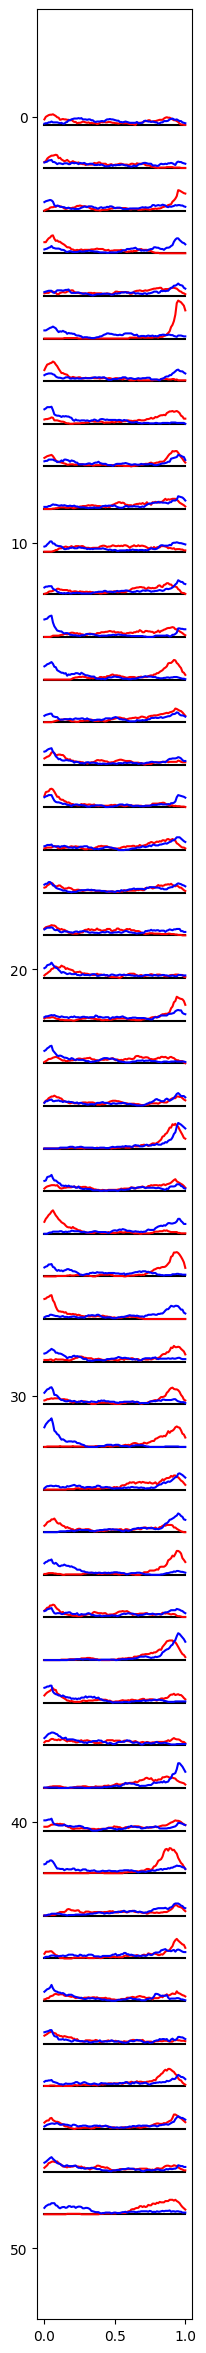

In [215]:
fig, ax = plt.subplots(figsize=(2, 30))

ax.yaxis.set_inverted(True)

for feature in range(50):
    uno_dist = estimate_density(uno_sample_encoded[:,feature])
    ax.plot(uno_dist[0], np.zeros_like(uno_dist[0]) + feature + 0.2, color='k')
    ax.plot(uno_dist[0], feature - uno_dist[1] * 0.1 + 0.2, color='r')
    seis_dist = estimate_density(seis_sample_encoded[:,feature])
    ax.plot(seis_dist[0], feature - seis_dist[1] * 0.1 + 0.2, color='b')

fig.show()

Here is the graph of all the densities of each feature colored by the different digit. As you can see, some features speak for themselves in the differences.

Now, shall we try another comparison? Let's do the same for 2 and 9.

In [216]:
dos_sample = np.random.choice(dos, size=100)
nueve_sample = np.random.choice(nueve, size=100)

In [217]:
dos_sample_encoded = mnist_autoencoder.encode(x_train_array[dos_sample])
nueve_sample_encoded = mnist_autoencoder.encode(x_train_array[nueve_sample])

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\4222497459.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


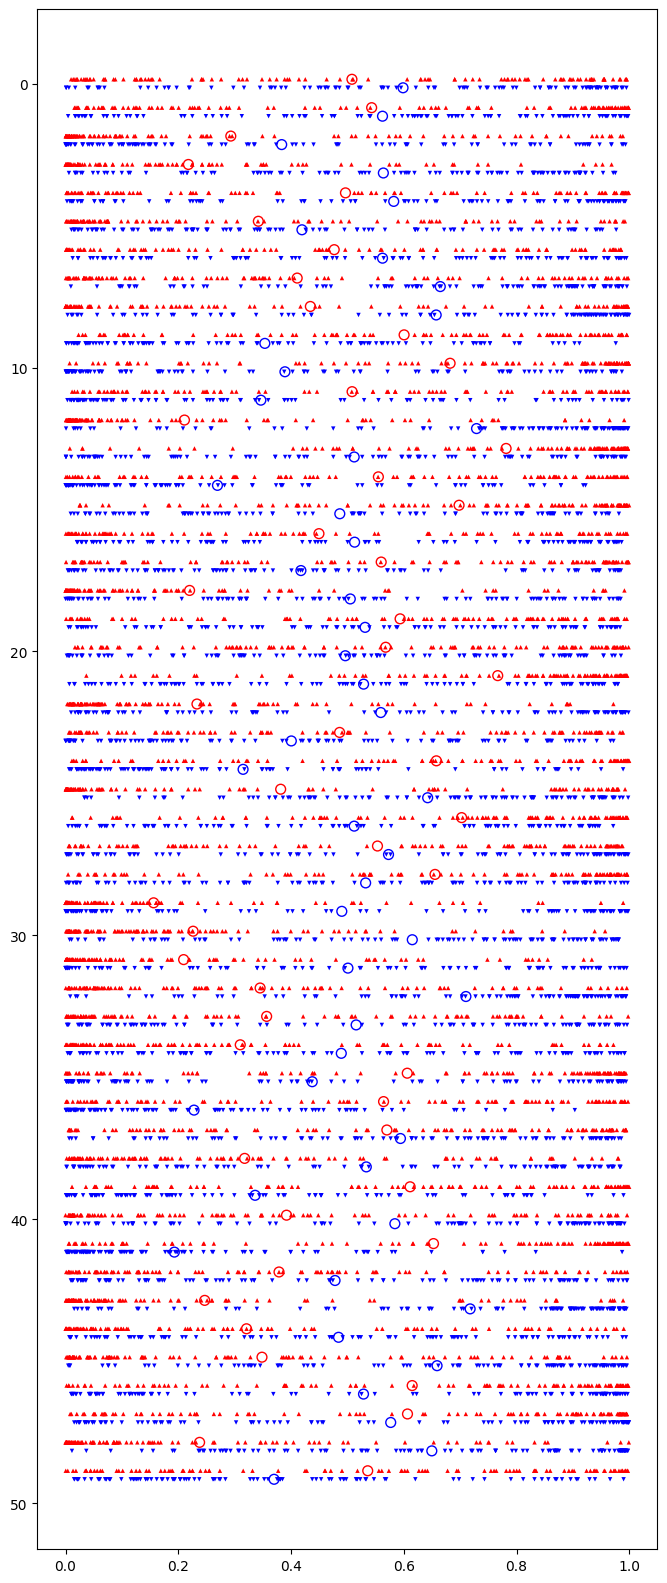

In [218]:
x_dos = np.reshape(dos_sample_encoded, (5000,), order='F')
x_nueve = np.reshape(nueve_sample_encoded, (5000,), order='F')

y_feature = np.reshape(np.broadcast_to(np.arange(50), (100, 50)), (5000,), order='F')

fig, ax = plt.subplots(figsize=(8, 20))

ax.yaxis.set_inverted(True)

ax.scatter(x_dos, y_feature-0.15, s=10, marker='^', facecolors='r', edgecolors='none')
ax.scatter(x_nueve, y_feature+0.15, s=10, marker='v', facecolors='b', edgecolors='none')

dos_averages = np.sum(dos_sample_encoded, axis=0) / 100
nueve_averages = np.sum(nueve_sample_encoded, axis=0) / 100
ax.scatter(dos_averages, np.arange(50)-0.15, s=50, marker='o', facecolors='none', edgecolors='r')
ax.scatter(nueve_averages, np.arange(50)+0.15, s=50, marker='o', facecolors='none', edgecolors='b')

fig.show()

This time, 2s are in red and 9s are in blue. The features where red is significantly higher than blue include 10, 17, 39, and 41. On the other hand, the features where blue is significantly higher than red include 7, 12, 25, and 32. A different set of features compared to last time.

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\3661534492.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


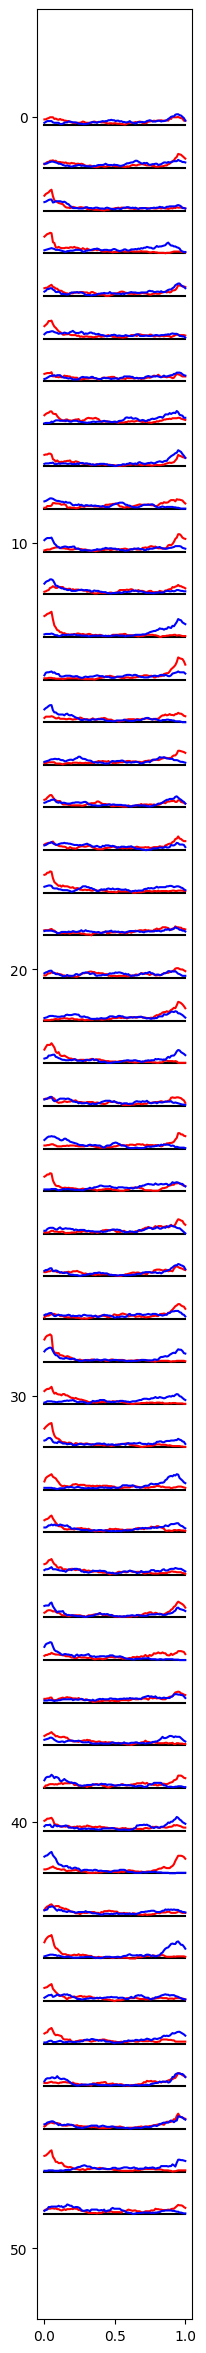

In [219]:
fig, ax = plt.subplots(figsize=(2, 30))

ax.yaxis.set_inverted(True)

for feature in range(50):
    dos_dist = estimate_density(dos_sample_encoded[:,feature])
    ax.plot(dos_dist[0], np.zeros_like(dos_dist[0]) + feature + 0.2, color='k')
    ax.plot(dos_dist[0], feature - dos_dist[1] * 0.1 + 0.2, color='r')
    nueve_dist = estimate_density(nueve_sample_encoded[:,feature])
    ax.plot(nueve_dist[0], feature - nueve_dist[1] * 0.1 + 0.2, color='b')

fig.show()

Let's do one more challenging one. 3 vs 8.

In [220]:
tres_sample = np.random.choice(tres, size=100)
ocho_sample = np.random.choice(ocho, size=100)

In [221]:
tres_sample_encoded = mnist_autoencoder.encode(x_train_array[tres_sample])
ocho_sample_encoded = mnist_autoencoder.encode(x_train_array[ocho_sample])

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\2545934571.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


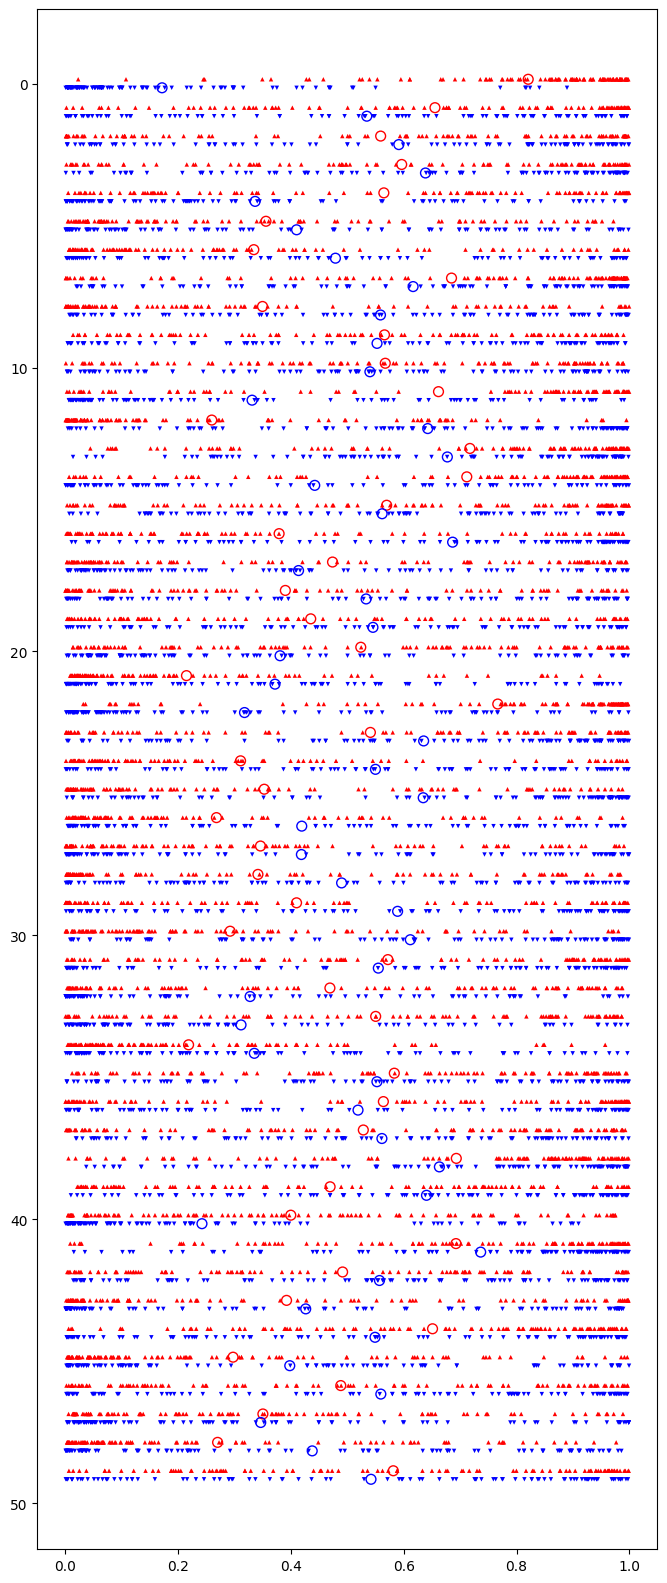

In [222]:
x_tres = np.reshape(tres_sample_encoded, (5000,), order='F')
x_ocho = np.reshape(ocho_sample_encoded, (5000,), order='F')

y_feature = np.reshape(np.broadcast_to(np.arange(50), (100, 50)), (5000,), order='F')

fig, ax = plt.subplots(figsize=(8, 20))

ax.yaxis.set_inverted(True)

ax.scatter(x_tres, y_feature-0.15, s=10, marker='^', facecolors='r', edgecolors='none')
ax.scatter(x_ocho, y_feature+0.15, s=10, marker='v', facecolors='b', edgecolors='none')

tres_averages = np.sum(tres_sample_encoded, axis=0) / 100
ocho_averages = np.sum(ocho_sample_encoded, axis=0) / 100
ax.scatter(tres_averages, np.arange(50)-0.15, s=50, marker='o', facecolors='none', edgecolors='r')
ax.scatter(ocho_averages, np.arange(50)+0.15, s=50, marker='o', facecolors='none', edgecolors='b')

fig.show()

This time, 3s are in red and 8s are in blue. The features where red is significantly higher than blue include 0, 4, 11, and 22. On the other hand, the features where blue is significantly higher than red include 12, 24, and 30. Again, a different set of features compared to last time.

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\459296225.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


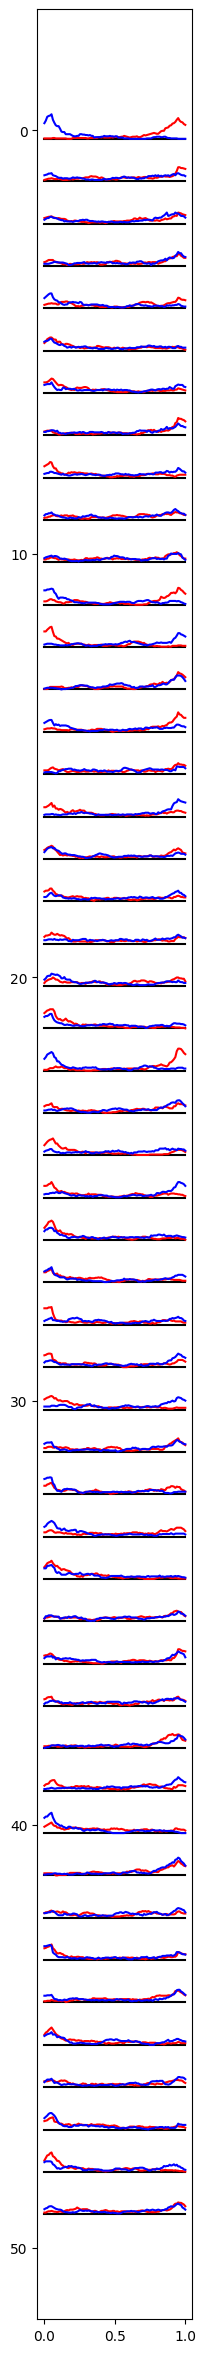

In [223]:
fig, ax = plt.subplots(figsize=(2, 30))

ax.yaxis.set_inverted(True)

for feature in range(50):
    tres_dist = estimate_density(tres_sample_encoded[:,feature])
    ax.plot(tres_dist[0], np.zeros_like(tres_dist[0]) + feature + 0.2, color='k')
    ax.plot(tres_dist[0], feature - tres_dist[1] * 0.1 + 0.2, color='r')
    ocho_dist = estimate_density(ocho_sample_encoded[:,feature])
    ax.plot(ocho_dist[0], feature - ocho_dist[1] * 0.1 + 0.2, color='b')

fig.show()

Overall, these plots should work well as a diagnosis to test how well our model is able to distinguish different pairs of digits via the encoder that we have trained to reduce images of 784 pixels to a fewer number of features.

Now, let's do further analysis on random samples of each digit from the MNIST database. The next kind of analysis we shall do is one that visualizes how each digit category gets encoded on average onto the 50 features.

In [224]:
cero = training_digit_indices[0]
uno = training_digit_indices[1]
dos = training_digit_indices[2]
tres = training_digit_indices[3]
cuatro = training_digit_indices[4]
cinco = training_digit_indices[5]
seis = training_digit_indices[6]
siete = training_digit_indices[7]
ocho = training_digit_indices[8]
nueve = training_digit_indices[9]

In [225]:
cero_sample = np.random.choice(cero, 100, replace=False)
uno_sample = np.random.choice(uno, 100, replace=False)
dos_sample = np.random.choice(dos, 100, replace=False)
tres_sample = np.random.choice(tres, 100, replace=False)
cuatro_sample = np.random.choice(cuatro, 100, replace=False)
cinco_sample = np.random.choice(cinco, 100, replace=False)
seis_sample = np.random.choice(seis, 100, replace=False)
siete_sample = np.random.choice(siete, 100, replace=False)
ocho_sample = np.random.choice(ocho, 100, replace=False)
nueve_sample = np.random.choice(nueve, 100, replace=False)

In [226]:
cero_sample_encoded = mnist_autoencoder.encode(x_train_array[cero_sample])
uno_sample_encoded = mnist_autoencoder.encode(x_train_array[uno_sample])
dos_sample_encoded = mnist_autoencoder.encode(x_train_array[dos_sample])
tres_sample_encoded = mnist_autoencoder.encode(x_train_array[tres_sample])
cuatro_sample_encoded = mnist_autoencoder.encode(x_train_array[cuatro_sample])
cinco_sample_encoded = mnist_autoencoder.encode(x_train_array[cinco_sample])
seis_sample_encoded = mnist_autoencoder.encode(x_train_array[seis_sample])
siete_sample_encoded = mnist_autoencoder.encode(x_train_array[siete_sample])
ocho_sample_encoded = mnist_autoencoder.encode(x_train_array[ocho_sample])
nueve_sample_encoded = mnist_autoencoder.encode(x_train_array[nueve_sample])

In [227]:
cero_averages = np.sum(cero_sample_encoded, axis=0) / 100
uno_averages = np.sum(uno_sample_encoded, axis=0) / 100
dos_averages = np.sum(dos_sample_encoded, axis=0) / 100
tres_averages = np.sum(tres_sample_encoded, axis=0) / 100
cuatro_averages = np.sum(cuatro_sample_encoded, axis=0) / 100
cinco_averages = np.sum(cinco_sample_encoded, axis=0) / 100
seis_averages = np.sum(seis_sample_encoded, axis=0) / 100
siete_averages = np.sum(siete_sample_encoded, axis=0) / 100
ocho_averages = np.sum(ocho_sample_encoded, axis=0) / 100
nueve_averages = np.sum(nueve_sample_encoded, axis=0) / 100

In [228]:
averages = np.stack([cero_averages, uno_averages, dos_averages, tres_averages, cuatro_averages, cinco_averages, seis_averages, siete_averages, ocho_averages, nueve_averages])

C:\Users\rayng\AppData\Local\Temp\ipykernel_44908\1342886981.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


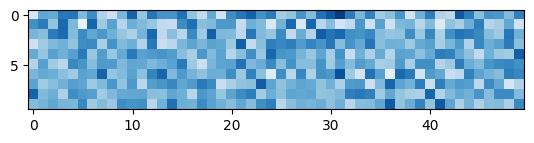

In [229]:
fig, ax = plt.subplots()

ax.imshow(averages, cmap='Blues_r', vmin=0, vmax=1)

fig.show()

The above map shows how the averages of each feature and digit vary. Darker points are those that are more negative in the corresponding feature, while lighter points are those that are more positive in that feature.

Next, which pairs of digits is each feature of our autoencoder able to tell apart? To look at this we shall do a heatmap for the differences between digits a distinguished by a single feature.

In [230]:
average_differences = averages[:, np.newaxis, :] - averages[np.newaxis, :, :]

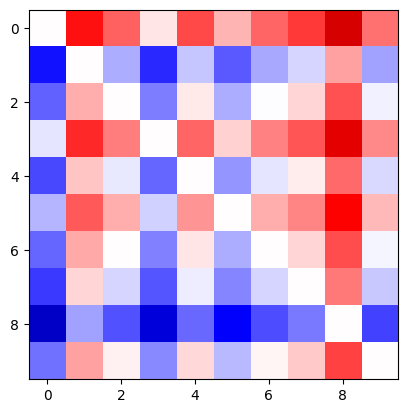

In [231]:
plt.imshow(average_differences[:, :, 0], cmap='seismic', vmin=-1, vmax=1)

The darker the point at either color, the better the feature is at distinguishing the pair of digits. In this plot, for example, we see how feature 0 of our encoder can separate 0s and 8s the best, followed by 5s and 8s, but weak at distinguishing between ones like 2s, 4s, and 7s. Here, red means the encoded feature for the digit along the y-axis of the plot is higher than that along the x-axis, while blue means the encoded feature for the digit along the y-axis is lower than that along the x-axis. In other words, here this means the feature generally produces high values for the feature for the digits 0 and 3 and low values for the digit 8. This is a blunt measure of how good a feature of the autoencoder is at separating features, but should give us an idea of it.

To explore how the other features do the same, change the index and see how the differences come about in each one.

One more thing we can do is measure the Euclidean distance of each pair of the average feature vectors.

In [232]:
euclidean_distances = np.sqrt(np.sum(average_differences**2, axis=2))

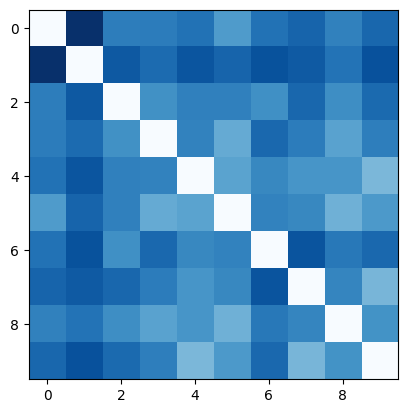

In [233]:
plt.imshow(euclidean_distances, cmap='Blues')

Using this plot, we see how our autoencoder has found features that distinguish between 0-1 (distance 2.35) and 6-7 (distance 2.21) quite strongly, while a feature like 4-9 (distance 1.04) becomes harder to distinguish.

Next, with the help of our encoder, how well can we make a neural network to identify digits accurately? This time we shall start from the encoded inputs by encoding the MNIST data using our autoencoder, then training a neural network from the encoded inputs to the outputs. Let's set up one new network and train it towards an accurate one.

In [147]:
mnist_nn4 = NeuralNetwork([50, 16, 16, 10], activation=sigmoid, d_activation=d_sigmoid, inv_activation=inv_sigmoid, vectorize=False)

In [234]:
x_train_array_encoded = mnist_autoencoder.encode(x_train_array)
x_test_array_encoded = mnist_autoencoder.encode(x_test_array)

In [235]:
def predict_digit(nn, image):
    output = nn.forward(image)[0][-1]
    return np.argmax(output)

def test_nn(nn, test_indices):
    correct_answers = 0
    questions_by_digit = {n: 0 for n in range(0,10)}
    correct_answers_by_digit = {n: 0 for n in range(0,10)}

    for index in test_indices:
        questions_by_digit[y_test[index]] += 1
        prediction = predict_digit(nn, x_test_array_encoded[index, :])
        if prediction == y_test[index]:
            correct_answers += 1
            correct_answers_by_digit[y_test[index]] += 1
    rate_by_digit = {n: correct_answers_by_digit[n] / questions_by_digit[n] for n in range(10)}
    return correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit

Testing model and calibrating training regimen...
Training iteration 10...
Training iteration 20...
Testing model and calibrating training regimen...
Training iteration 30...
Training iteration 40...
Testing model and calibrating training regimen...
Training iteration 50...
Training iteration 60...
Testing model and calibrating training regimen...
Training iteration 70...
Training iteration 80...
Testing model and calibrating training regimen...
Training iteration 90...
Training iteration 100...
Testing model and calibrating training regimen...
Training iteration 110...
Training iteration 120...
Testing model and calibrating training regimen...
Training iteration 130...
Training iteration 140...
Testing model and calibrating training regimen...
Training iteration 150...
Training iteration 160...
Testing model and calibrating training regimen...
Training iteration 170...
Training iteration 180...
Testing model and calibrating training regimen...
Training iteration 190...
Training iterat

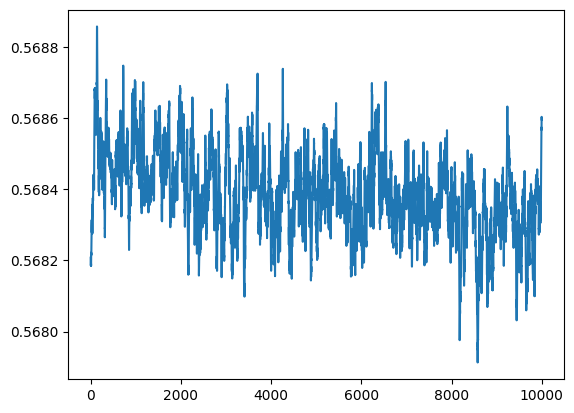

In [236]:
error_history = []

test_indices = np.random.choice(range(10000), size=1000, replace=False)

testing_sample_x = x_test_array_encoded[test_indices, :]
testing_sample_y = y_test_array[test_indices, :]

digit_sets = [cero, uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve]

for i in range(10000):
    if i % 20 == 0:
        print("Testing model and calibrating training regimen...")
        validation_indices = np.random.choice(range(10000), size=1000, replace=False)

        correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn4, validation_indices)

        digits_order = np.argsort(list(rate_by_digit.values()))
        first_priority = [digit_sets[n] for n in digits_order[0:1]]
        high_priority = [digit_sets[n] for n in digits_order[1:2]]
        medium_priority = [digit_sets[n] for n in digits_order[2:5]]
        low_priority = [digit_sets[n] for n in digits_order[5:10]]

        probabilities = np.zeros(60000)
        probabilities[np.concatenate(first_priority)] = 5
        probabilities[np.concatenate(high_priority)] = 4
        probabilities[np.concatenate(medium_priority)] = 3
        probabilities[np.concatenate(low_priority)] = 2
        probabilities /= np.sum(probabilities)
        
    sample_indices = np.random.choice(range(60000), size=20, replace=False, p=probabilities)
    training_sample_x = x_train_array_encoded[sample_indices, :]
    training_sample_y = y_train_array[sample_indices, :] * 0.6 + 0.3
    mnist_nn4.backpropagation(training_sample_x, training_sample_y, learning_rate = 0.01, rel_noise = 0)
    if i % 10 == 9:
        print(f"Training iteration {i+1}...")
    error = mnist_nn4.error(testing_sample_x, testing_sample_y * 0.6 + 0.3, dist_mode='sum')
    error_history.append(error)
    if error < 0.2:
        break

correct_answers, questions_by_digit, correct_answers_by_digit, rate_by_digit = test_nn(mnist_nn4, test_indices)

plt.plot(error_history)

In [158]:
mnist_nn4.weights

[array([[ 1.80395710e-01,  4.38360192e-01, -4.22766130e-02,
          3.65083420e-01, -2.29980365e-01, -1.04820908e-01,
         -1.42470467e-01,  3.29794180e-01, -8.34231587e-01,
         -2.39244929e-01,  7.64213314e-01,  9.58488081e-01,
         -3.40721132e-01,  1.02448745e-01, -4.21903466e-01,
          6.99666068e-01],
        [ 4.24118059e-01,  6.85460343e-01,  4.33970478e-01,
          5.02774878e-02, -1.57233479e-01, -3.34040188e-01,
          2.35524360e-01, -3.66674257e-01,  5.08730014e-01,
         -8.93865684e-02, -2.33862233e-02,  2.57991930e-03,
         -2.40932456e-01,  6.43022629e-01, -3.31136540e-01,
         -3.85194230e-01],
        [ 1.41277406e-01, -3.22285998e-01, -2.86385152e-01,
          5.11948100e-01,  2.59326971e-01, -4.41699255e-01,
         -6.65889148e-01,  1.72073002e-01, -7.68614597e-02,
          4.02854426e-01,  3.85254049e-01, -1.55246508e-02,
         -2.93504034e-01, -4.01527478e-01,  5.18286635e-01,
         -6.36999609e-03],
        [ 8.3900456

<BarContainer object of 10 artists>

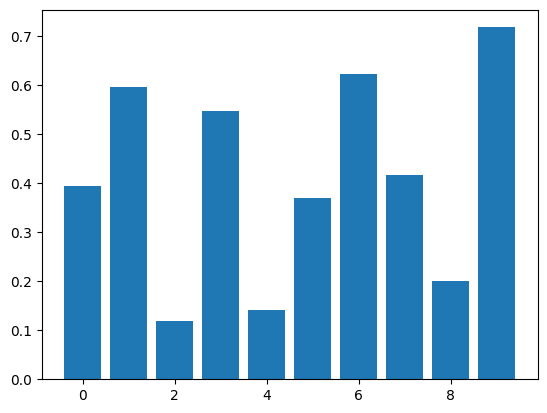

In [237]:
plt.bar(rate_by_digit.keys(), rate_by_digit.values())

In [238]:
correct_answers

400

In [ ]:
import datetime

In [239]:
filename = f"mnist_autoencoder_identifier_weights_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn4.weights, open(filename, 'wb'))

filename = f"mnist_autoencoder_identifier_biases_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
pickle.dump(mnist_nn4.biases, open(filename, 'wb'))

## Convolutional neural networks (CNNs)

Now that we have finished our theory behind the feedforward neural network (FNN), there is one other type of neural network that can be explored. When processing images or videos, or even audio, it's not enough to take in all the pixels and frames and analyze them as if they are separate, because they are not. They have positional relations, that is they are related in a way that adjacent or nearby pixels or consecutive frames are expected to be similar with each other. This is where *convolutional neural networks (CNNs)* come in, a different type of neural network to analyze these kinds of data that is more continuous in space.

What is convolution? We take a multidimensional array $X$ to convolve with a *kernel* $K$, a smaller array in each dimension. Suppose $X$ has dimensions like $n_1 \times n_2 \times \cdots \times n_r$ where $r$ is the *rank* of the tensor, which is not the same as a matrix rank meaning the columnspace dimension, but rather how many axes the array has, and take $K$ to have dimensions $(k_1+1) \times (k_2+1) \times \cdots \times (k_r+1)$, where $0 \leq m_i < n_i$ for each $i$. The result in each axis gets its length reduced by $k_i$. We allow $k_i = 0$ so that we don't convolve in that particular axis. Then we define convolution by setting the following:
$$
X_{(n_1 \times n_2 \times \cdots \times n_r)} * K_{((k_1+1) \times (k_2+1) \times \cdots \times (k_r+1))} = Y_{((n_1-k_1) \times (n_2-k_2) \times \cdots \times (n_r-k_r))}
$$
For an array, we define $X_{\textbf{i}}$, where $\textbf{i} = (i_1, \cdots, i_r)$ is a multi-index of length $r$, to be the element in $X$ at position $\textbf{i}$. In NumPy-speak, we are doing exactly the syntax `X[i_1, i_2, ..., i_r]`. According to the convolution definition, for each index $\textbf{i}$ available in $Y$, we define:
$$
Y_{\textbf{i}} = \sum_{\textbf{j}\in I_K} X_{\textbf{i}+\textbf{j}} K_{\textbf{j}}
$$
Strictly speaking, using the mathematical definition of convolution means we should use a subtraction instead of addition on the index since convolution is conventionally defined as:
$$
f*g(x) = \int f(x-y) g(y) dy
$$
But for machine learning purposes, it is justified to use the definition written above.

How do we implement this on arrays? The most efficient way is to take the $(n_1-k_1) \times (n_2-k_2) \times \cdots \times (n_r-k_r)$ slice of $X$ whose smallest index in each axis is $\textbf{j}$, then multiply this slice by $K_{\textbf{j}}$ and add to the result, doing this over all indices $\textbf{j}$ available for $K$. In NumPy speak the slice is defined by `X[i_1:n_1-k_1+i_1, i_2:n_2-k_2+i_2, ..., i_r:n_r-k_r+i_r]` Let's implement the function on generalized arrays of the same rank and valid dimensions. To do this it is useful to make use of packages like `itertools` and the built in `slice` object function to help us, especially for the general dimension case.

In [247]:
import itertools

In [ ]:
def convolution(array, kernel):
    if len(array.shape) != len(kernel.shape):
        raise DimensionMismatch("Array and kernel shape must have same rank (array dimension)")
    
    result_dimension = np.array(array.shape) - np.array(kernel.shape) + np.ones_like(array.shape)
    result = np.zeros(result_dimension)

    indices = np.ndindex(kernel.shape)

    for index in indices:
        array_slice = tuple([slice(index[i], result_dimension[i] + index[i]) for i in range(len(array.shape))])
        result += array[array_slice] * kernel[index]

    return result

In [307]:
array = np.random.random((10, 10, 10))
kernel = np.random.random((4, 4, 4))

print(array, kernel)

[[[0.2055675  0.91670401 0.0913332  0.50569182 0.84133327 0.27295487
   0.73175579 0.65256948 0.84747751 0.69240183]
  [0.91155494 0.56642524 0.21808259 0.24483453 0.43059243 0.96307289
   0.05596878 0.44653311 0.31367383 0.90271009]
  [0.89976274 0.60274503 0.01299704 0.47549552 0.03513791 0.64903646
   0.16493382 0.96861862 0.47066868 0.94722019]
  [0.33529965 0.50526351 0.04326793 0.96189666 0.2737986  0.57125852
   0.30780811 0.08835279 0.78156187 0.22003562]
  [0.93494765 0.44144289 0.39905274 0.91442508 0.93502554 0.8270796
   0.14349931 0.74525119 0.21735964 0.16844016]
  [0.54950664 0.33503282 0.60641955 0.85183254 0.78742366 0.01591246
   0.35201693 0.65438579 0.32216986 0.81011223]
  [0.15827061 0.25125916 0.0156258  0.349784   0.92975453 0.18228399
   0.90959258 0.44851442 0.94747163 0.51789606]
  [0.66066659 0.06196855 0.72194171 0.3538403  0.54276708 0.82969336
   0.41389373 0.27855573 0.67063341 0.09067455]
  [0.31948556 0.23660198 0.00134368 0.43087266 0.03348201 0.08159

In [308]:
convolution(array, kernel)

array([[[14.92251182, 16.96869139, 16.15729169, 13.7991295 ,
         14.31422131, 13.930624  , 14.88076413],
        [16.41382379, 15.88802999, 16.65377725, 16.78311677,
         14.40621201, 13.97108357, 13.71512697],
        [16.72247226, 16.32400636, 17.01797129, 16.65759567,
         16.9287368 , 14.9978483 , 12.92342277],
        [13.48156878, 17.02738815, 15.90107662, 16.99689941,
         16.13652337, 14.75622568, 14.79755439],
        [15.35197992, 16.15234209, 16.7634467 , 16.42762102,
         15.80627351, 15.69372088, 14.96490433],
        [15.18064107, 15.03008505, 15.18650725, 15.56572744,
         15.30978258, 16.49051631, 14.54422404],
        [12.51389819, 14.77797395, 14.71167704, 14.40227066,
         16.35170023, 15.62365106, 15.54388755]],

       [[16.25157378, 16.63436643, 15.84293862, 14.54251714,
         14.02639694, 12.5669664 , 12.97963164],
        [16.03100358, 17.55237812, 15.81249063, 16.78715529,
         16.62689538, 13.69233998, 13.98311634],
        

Now, the next thing to discuss is how the architecture of a CNN is described. In a CNN we usually have a series of steps including *convolution*, applying an activation function (like ReLU or sigmoid), and *pooling*, for the first layer. After convolution is carrie out we flatten the output at the end of a convolution process, then feed it through a fully connected layer which acts with the architecture of a feedforward neural network from tha point.

The next function we need to implement to make this usable is the pooling function. What is pooling? We simply divide the grid into smaller ones, say $2 \times 2$ or $2 \times 2 \times 2$, then collapse each small grid of the resulting tensor into a number via a pooling function $p$ like sum, average, or max, to compress sparse information. Though sometimes it is possible to have the smaller grids overlap or separate, in which case we distinguish between the size of the *filter*, which is how big each small grid is, and the *stride*, which is how big each step taken is. In a matrix representation, what we are doing is dividing the tensor with the following process and applying a function like $p$ from the small matrix to a simple real number. In the case of 2D matrices, it looks like the following, though the same idea can be extended to any dimension:
$$
X =
\begin{bmatrix}
{X_{11}}_{(f_1 \times f_2)} & {X_{12}}_{(f_1 \times f_2)} & \cdots \\
{X_{21}}_{(f_1 \times f_2)} & {X_{22}}_{(f_1 \times f_2)} & \cdots \\
\vdots & \vdots & \ddots \\
\end{bmatrix}_{(n_1 \times n_2)}
\rightarrow
\begin{bmatrix}
p(X_{11}) & p(X_{12}) & \cdots \\
p(X_{21}) & p(X_{22}) & \cdots \\
\vdots & \vdots & \ddots \\
\end{bmatrix}_{(\lceil n_1/s_1 \rceil \times \lceil n_2/s_2 \rceil)}
$$
where $f_1 \times f_2$ is the filter size and $s_1 \times s_2$ is the stride size.

In [ ]:
def pool(array, filter_size=(2,) * len(array.shape), stride_size=(2,) * len(array.shape), pooling_function=np.max):
    if not isinstance(array, np.ndarray):
        raise TypeError("Input must be a numpy array")
    if len(array.shape) != len(filter_size) or len(array.shape) != len(stride_size):
        raise DimensionMismatch("Input array, filter size, and stride size must have same rank (array dimension)")
    stride_points = itertools.product(*[range(0, array.shape[i], stride_size[i]) for i in range(len(array.shape))])
    for stride_point in stride_points:
        filter_slice = tuple([slice(stride_point[i], min(stride_point[i] + filter_size[i], array.shape[i])) for i in range(len(array.shape))])
        yield pooling_function(array[filter_slice])